### 保存結果の前処理。
不必要なpklファイルがあれば削除。

In [1]:
# import sys
# import os
# project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
# if project_root not in sys.path:
#     sys.path.append(project_root)
# print(f"プロジェクトルート: {project_root}")
# from src.util.vis_result import *
# from failure_optim import manage_pkl_files_after_optimization

# STUDY_NAME = "cs_failure_optimization_parallel"
# save_dir="20250808_0942"
# STORAGE_URL = f"sqlite:///{save_dir}/optuna_failure_study_parallel.db"
# study = optuna.load_study(study_name=STUDY_NAME, storage=STORAGE_URL)
# manage_pkl_files_after_optimization(study=study, save_dir=save_dir)

### Optunaの最適化結果をまとめる。
通常時，故障時のパフォーマンスを可視化して評価する。

##### 0前準備

In [27]:
# ノートブックの先頭に追加
import pandas as pd
import numpy as np

# pandas表示オプションの設定
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# numpy表示オプションの設定
np.set_printoptions(formatter={'float_kind':'{:.3f}'.format})
import sys
import os
import matplotlib.dates as mdates
import glob

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
print(f"プロジェクトルート: {project_root}")
from src.util.vis_result import *
from src.util.optimization import *
from failure_optim import manage_pkl_files_after_optimization

# 通常最適化の結果ファイル
normal_save_dir = r"Z:\output\normal\20250927_1514_HEALTH"
normal_failure_save_dir = r"Z:\output\normal\20250927_1514_FAILURE"
result_file_normal = glob.glob(f'{normal_save_dir}/*.pkl')[0]
result_file_normal_failure_list = glob.glob(f'{normal_failure_save_dir}/*.pkl')
result_file_normal_failure = max(result_file_normal_failure_list, key=lambda f: evaluation_total_costs(f)[0])
# ロバスト最適化の結果ファイル
robust_save_dir = r"Z:\output\robust\20250927_1747_HEALTH"
robust_failure_save_dir = r"Z:\output\robust\20250927_1503_FAILURE"
result_file_robust = glob.glob(f'{robust_save_dir}/*.pkl')[0]
result_file_robust_failure_list = glob.glob(f'{robust_failure_save_dir}/*.pkl')
result_file_robust_failure = max(result_file_robust_failure_list, key=lambda f: evaluation_total_costs(f)[0])

# 5拠点ケースの結果ファイル
result_5loc_dir = r"Z:\output\20250927_2216_5locations"
result_failure_5loc_dir = r"Z:\output\20250929_1325_5locations_FAILURE"
result_file_5loc = glob.glob(f'{result_5loc_dir}/*.pkl')[0]
result_file_5loc_failure_list = glob.glob(f'{result_failure_5loc_dir}/*.pkl')
result_file_5loc_failure = max(result_file_5loc_failure_list, key=lambda f: evaluation_total_costs(f)[0])

# 確率的最適化の結果ファイル
result_stochastic_dir = r"Z:\output\20250928_1629_PROBABILISTIC"
result_file_stochastic = glob.glob(f'{result_stochastic_dir}/*.pkl')[-1]
result_file_stochastic_failure_list = glob.glob(f'{result_stochastic_dir}/*.pkl')
result_file_stochastic_failure = max(result_file_stochastic_failure_list, key=lambda f: evaluation_total_costs(f)[0])

# 確率的最適化（充電器5％故障）の結果ファイル
result_file_stochastic_5_dir = r"Z:\output\20251031_0032_PROBABILISTIC_5%"
result_file_stochastic_5 = glob.glob(f'{result_file_stochastic_5_dir}/*.pkl')[-1]
result_file_stochastic_5_failure_list = glob.glob(f'{result_file_stochastic_5_dir}/*.pkl')
result_file_stochastic_5_failure = max(result_file_stochastic_5_failure_list, key=lambda f: evaluation_total_costs(f)[0])

result_file_stochastic_2_dir = r"Z:\output\20251101_1815_PROBABILISTIC_2%"
result_file_stochastic_2 = glob.glob(f'{result_file_stochastic_2_dir}/*.pkl')[-1]
result_file_stochastic_2_failure_list = glob.glob(f'{result_file_stochastic_2_dir}/*.pkl')
result_file_stochastic_2_failure = max(result_file_stochastic_2_failure_list, key=lambda f: evaluation_total_costs(f)[0])


# Optunaのスタディ読み込み
normal_study_name = "cs_optimization"
normal_db = "optuna_study.db"
failure_study_name = "cs_optimization_failure"
failure_db = "optuna_study_failure.db"

study_normal = optuna.load_study(study_name=normal_study_name, storage=f"sqlite:///{normal_save_dir}/{normal_db}")
study_normal_failure = optuna.load_study(study_name=failure_study_name, storage=f"sqlite:///{normal_failure_save_dir}/{failure_db}")
study_robust = optuna.load_study(study_name=normal_study_name, storage=f"sqlite:///{robust_save_dir}/{normal_db}")
study_robust_failure = optuna.load_study(study_name=failure_study_name, storage=f"sqlite:///{robust_failure_save_dir}/{failure_db}")
study_5loc = optuna.load_study(study_name=normal_study_name, storage=f"sqlite:///{result_5loc_dir}/{normal_db}")
study_5loc_failure = optuna.load_study(study_name=failure_study_name, storage=f"sqlite:///{result_failure_5loc_dir}/{failure_db}")
study_stochastic_2 = optuna.load_study(study_name=failure_study_name, storage=f"sqlite:///{result_stochastic_dir}/{failure_db}")
study_stochastic_5 = optuna.load_study(study_name=failure_study_name, storage=f"sqlite:///{result_file_stochastic_5_dir}/{failure_db}")
print("=== 最適化結果の管理 ===")
print(f"normal: {study_normal.best_trial.value:3f}")
print(f"normal_failure: {study_normal_failure.best_trial.value:3f}")
print(f"robust: {study_robust.best_trial.value:3f}")
print(f"robust_failure: {study_robust_failure.best_trial.value:3f}")
print(f"5loc: {study_5loc.best_trial.value:3f}")
print(f"5loc_failure: {study_5loc_failure.best_trial.value:3f}")
print(f"stochastic_normal: {study_stochastic.best_trial.user_attrs.get('normal_cost', 'N/A'):3f}")
print(f"stochastic_failure: {evaluation_total_costs(result_file_stochastic_failure)[0]:3f}")
print(f"stochastic_expected: {study_stochastic.best_trial.user_attrs.get('expected_cost_details', 'N/A'):3f}")
print(f"stochastic_5_normal: {study_stochastic_5.best_trial.user_attrs.get('normal_cost', 'N/A'):3f}")
print(f"stochastic_5_failure: {evaluation_total_costs(result_file_stochastic_5_failure)[0]:3f}")
print(f"stochastic_5_expected: {study_stochastic_5.best_trial.user_attrs.get('expected_cost_details', 'N/A'):3f}")

def create_unified_charging_vehicle_analysis(result_files, case_names):
    """
    全ケースで充電を行った共通車両のみで統一分析を実行
    """
    
    print("=== 共通充電車両の特定 ===")
    
    # 各ケースの充電車両EVIDを取得
    charging_evids_by_case = {}
    non_charging_evids_by_case = {}
    all_vehicle_data = {}
    
    for result_file, case_name in zip(result_files, case_names):
        with open(result_file, 'rb') as f:
            data = pickle.load(f)
            vehicle_trip = data['vehicle_trip']
            cs_config = data['cs_config']
            # CS設定をDataFrameに変換
            cs_df = pd.DataFrame({
                'csids': cs_config['csids'],
                'ports': cs_config['ports'],
                'cap_kw': cs_config['cap_kw']
            })
            # トリップデータの前処理
            vehicle_trip = vehicle_trip[vehicle_trip['StartTime'] < 86400]
            vehicle_trip['TripTime'] = vehicle_trip['EndTime'] - vehicle_trip['StartTime']
            vehicle_trip['WaitingTime'] = vehicle_trip['startChargingTime'] - vehicle_trip['WaitingEntryTime']
            
        # 設置されたCSのみ（ports > 0）を抽出
        installed_cs = cs_df[cs_df['ports'] > 0].copy()
        # 充電時間を計算: (0.8 - InitialSOC) * 60kWh / cap_kw（時間単位）
        # まずCS容量情報をマージ
        vehicle_trip_with_cs = pd.merge(
            vehicle_trip, 
            installed_cs[['csids', 'cap_kw']], 
            left_on='CSID', 
            right_on='csids', 
            how='left'
        )
        # print(vehicle_trip_with_cs)
        
                # 充電が必要な車両のマスク（より厳密な条件）
        charging_mask = (
            (vehicle_trip_with_cs['startChargingTime'] > 0) & 
            (vehicle_trip_with_cs['CSID'] > 0) &  # CSIDが有効
            (vehicle_trip_with_cs['cap_kw'].notna()) &  # CS容量データが存在
            (vehicle_trip_with_cs['InitialSOC'] < 0.8) &  # 充電が必要
            (vehicle_trip_with_cs['InitialSOC'] >= 0)  # SOCが有効範囲
        )
        
        print(f"充電マスクに該当するデータ数: {charging_mask.sum()}")
        
        # 充電時間を初期化
        vehicle_trip_with_cs['ChargingTime'] = 0.0  # デフォルト値を0に設定
        
        # 充電が必要な車両のみに充電時間を計算
        if charging_mask.sum() > 0:
            # SOC差分を計算（0.8まで充電）
            soc_diff = 0.8 - vehicle_trip_with_cs.loc[charging_mask, 'InitialSOC']
            
            # 負の値をクリップ（念のため）
            soc_diff = soc_diff.clip(lower=0)
            
            # 充電量（kWh）
            charging_kwh = soc_diff * 60  # バッテリー容量60kWh
            
            # 充電時間（時間）- 0で割り算を防ぐ
            cap_kw_values = vehicle_trip_with_cs.loc[charging_mask, 'cap_kw']
            valid_cap_mask = cap_kw_values > 0
            
            if valid_cap_mask.sum() > 0:
                charging_time_hours = charging_kwh.loc[valid_cap_mask] / cap_kw_values.loc[valid_cap_mask]
                # 秒単位に変換
                vehicle_trip_with_cs.loc[charging_mask & valid_cap_mask, 'ChargingTime'] = charging_time_hours * 3600
        
        # 元のvehicle_tripに充電時間カラムを追加
        vehicle_trip['ChargingTime'] = vehicle_trip_with_cs['ChargingTime'].fillna(0)
        
        # デバッグ用：結果の確認
        print(f"\n{case_name} 充電時間の統計:")
        print(f"最小値: {vehicle_trip['ChargingTime'].min()}")
        print(f"最大値: {vehicle_trip['ChargingTime'].max()}")
        print(f"平均値: {vehicle_trip['ChargingTime'].mean()}")
        print(f"NaN数: {vehicle_trip['ChargingTime'].isna().sum()}")
        print(f"0より大きい値の数: {(vehicle_trip['ChargingTime'] > 0).sum()}")
        
        # 異常値のチェック
        extreme_values = vehicle_trip['ChargingTime'] > 7200  # 2時間以上
        if extreme_values.sum() > 0:
            print(f"異常に長い充電時間（2時間以上）: {extreme_values.sum()}件")
            # 異常値の詳細を確認
            extreme_data = vehicle_trip[extreme_values][['EVID', 'CSID', 'InitialSOC', 'ChargingTime']]
            print("異常値の詳細:")
            print(extreme_data.head())
        
        # 充電車両の抽出（統一された条件）
        charging_vehicles = vehicle_trip[
            (vehicle_trip['startChargingTime'] > 0) &
            (vehicle_trip['CSID'] > 0) &  # 有効なCSIDのみ
            (vehicle_trip['InitialSOC'] <= 0.2) &
            (vehicle_trip['WaitingEntryTime'] > 0)
        ].copy()
        
        charging_evids = set(charging_vehicles['EVID'].unique())
        charging_evids_by_case[case_name] = charging_evids
        all_vehicle_data[case_name] = vehicle_trip

        # 非充電車両の抽出（統一された条件）
        non_charging_vehicles = vehicle_trip[
            (vehicle_trip['startChargingTime'] == 0)
        ].copy()
        non_charging_evids = set(non_charging_vehicles['EVID'].unique())
        non_charging_evids_by_case[case_name] = non_charging_evids

        print(f"{case_name}: {len(charging_evids)} 台の充電車両")
    
    # 全ケース共通の充電車両EVIDを特定
    common_charging_evids = set.intersection(*charging_evids_by_case.values())
    common_non_charging_evids = set.intersection(*non_charging_evids_by_case.values())
    print(f"\n全ケース共通の充電車両: {len(common_charging_evids)} 台")
    print(f"全ケース共通の非充電車両: {len(common_non_charging_evids)} 台")

    # 各ケースでの差分を表示
    print("\n=== 各ケースの差分詳細 ===")
    for case_name, evids in charging_evids_by_case.items():
        unique_evids = evids - common_charging_evids
        print(f"{case_name}: +{len(unique_evids)} 台の独自充電車両")
        if len(unique_evids) <= 10:  # 少数の場合のみ表示
            print(f"  独自EVID: {sorted(list(unique_evids))}")
    
    # 共通充電車両のみでの統一分析データセットを作成
    unified_results = {}
    
    for result_file, case_name in zip(result_files, case_names):
        vehicle_trip = all_vehicle_data[case_name]
        
        # 共通充電車両のトリップのみ抽出
        common_charging_trips = vehicle_trip[
            (vehicle_trip['EVID'].isin(common_charging_evids)) &
            (vehicle_trip['startChargingTime'] > 0) &
            (vehicle_trip['CSID'] > 0)
        ].copy()
        
        # 非充電車両は全て含める（これらは各ケース共通のはず）
        non_charging_trips = vehicle_trip[
            (vehicle_trip['startChargingTime'] == 0) &
            (vehicle_trip['EVID'].isin(common_non_charging_evids))
        ].copy()
        
        # 統一データセットの作成
        unified_vehicle_data = pd.concat([common_charging_trips, non_charging_trips], 
                                       ignore_index=True)
        
        print(f"\n{case_name} 統一データセット:")
        print(f"  共通充電トリップ: {len(common_charging_trips)} 件")
        print(f"  非充電トリップ: {len(non_charging_trips)} 件")
        print(f"  総トリップ数: {len(unified_vehicle_data)} 件")
        
        unified_results[case_name] = {
            'vehicle_trip': unified_vehicle_data,
            'charging_trips': common_charging_trips,
            'non_charging_trips': non_charging_trips
        }
    
    return unified_results, common_charging_evids

# 統一分析データセットの作成
result_files = [result_file_normal, result_file_normal_failure, 
                result_file_robust, result_file_robust_failure, 
                result_file_5loc, result_file_5loc_failure,
                result_file_stochastic, result_file_stochastic_failure,
                result_file_stochastic_5, result_file_stochastic_5_failure,
                result_file_stochastic_2, result_file_stochastic_2_failure]
case_names = ['Normal', 'Normal_Failure', 'Robust', 'Robust_Failure',
              '5locations', '5locations_Failure', 'Stochastic', 'Stochastic_Failure',
              'Stochastic_5', 'Stochastic_5_Failure']

unified_data, common_evids = create_unified_charging_vehicle_analysis(result_files, case_names)
    
# 各ケースのデータに簡単にアクセスできる変数も作成
# 通常最適化ケース
charging_trips_normal = unified_data['Normal']['charging_trips']
non_charging_trips_normal = unified_data['Normal']['non_charging_trips']
charging_trips_normal_failure = unified_data['Normal_Failure']['charging_trips']
non_charging_trips_normal_failure = unified_data['Normal_Failure']['non_charging_trips']
# ロバスト最適化ケース
charging_trips_robust_health = unified_data['Robust']['charging_trips']
non_charging_trips_robust_health = unified_data['Robust']['non_charging_trips']
charging_trips_robust_failure = unified_data['Robust_Failure']['charging_trips']
non_charging_trips_robust_failure = unified_data['Robust_Failure']['non_charging_trips']
# 5拠点ケース
charging_trips_5loc = unified_data['5locations']['charging_trips']
non_charging_trips_5loc = unified_data['5locations']['non_charging_trips']
charging_trips_5loc_failure = unified_data['5locations_Failure']['charging_trips']
non_charging_trips_5loc_failure = unified_data['5locations_Failure']['non_charging_trips']
# 確率的最適化ケース
charging_trips_stochastic = unified_data['Stochastic']['charging_trips']
non_charging_trips_stochastic = unified_data['Stochastic']['non_charging_trips']
charging_trips_stochastic_failure = unified_data['Stochastic_Failure']['charging_trips']
non_charging_trips_stochastic_failure = unified_data['Stochastic_Failure']['non_charging_trips']
# 確率的最適化30%ケース
charging_trips_stochastic_5 = unified_data['Stochastic_5']['charging_trips']
non_charging_trips_stochastic_5 = unified_data['Stochastic_5']['non_charging_trips']
charging_trips_stochastic_5_failure = unified_data['Stochastic_5_Failure']['charging_trips']
non_charging_trips_stochastic_5_failure = unified_data['Stochastic_5_Failure']['non_charging_trips']

プロジェクトルート: c:\Users\echiz\00_研究コード\eMATES解析_GA\emates
=== 最適化結果の管理 ===
normal: -11119.590497
normal_failure: 8192.977411
robust: 71.047279
robust_failure: -4299.850225
5loc: -7448.950891
5loc_failure: -902.501215
stochastic_normal: -11119.590497
stochastic_failure: -160.290919
stochastic_expected: -9518.978662
stochastic_5_normal: -9071.008767
stochastic_5_failure: -8746.410364
stochastic_5_expected: -7570.762234
=== 共通充電車両の特定 ===
充電マスクに該当するデータ数: 120

Normal 充電時間の統計:
最小値: 0.0
最大値: 1296.0000000000005
平均値: 2.259414225941423
NaN数: 18
0より大きい値の数: 115
Normal: 120 台の充電車両
充電マスクに該当するデータ数: 120

Normal_Failure 充電時間の統計:
最小値: 0.0
最大値: 1296.0000000000005
平均値: 2.2397671457158457
NaN数: 18
0より大きい値の数: 114
Normal_Failure: 120 台の充電車両
充電マスクに該当するデータ数: 119

Robust 充電時間の統計:
最小値: 0.0
最大値: 1296.0000000000005
平均値: 2.2397671457158452
NaN数: 18
0より大きい値の数: 114
Robust: 119 台の充電車両
充電マスクに該当するデータ数: 119

Robust_Failure 充電時間の統計:
最小値: 0.0
最大値: 1296.0000000000005
平均値: 2.2397671457158452
NaN数: 18
0より大きい値の数: 114
Robust_Failur

#### ベースラインとロバスト最適化による比較

##### 1.1：最悪ケースにおける総旅行時間と待ち時間の比較と悪化率

In [3]:
#初期コスト
with open(result_file_normal, 'rb') as f:
    data_normal = pickle.load(f)
with open(result_file_robust, 'rb') as f:
    data_robust = pickle.load(f)
with open(result_file_5loc, 'rb') as f:
    data_5loc = pickle.load(f)
with open(result_file_stochastic, 'rb') as f:
    data_stochastic_5 = pickle.load(f)
initial_cost = calc_initial_costs(data_normal['cs_config'], None)
initial_cost_robust = calc_initial_costs(data_robust['cs_config'], None)
initial_cost_5loc = calc_initial_costs(data_5loc['cs_config'], None)
initial_cost_stochastic_5 = calc_initial_costs(data_stochastic_5['cs_config'], None)

charging_trip_list = [
    charging_trips_normal, charging_trips_normal_failure,
    charging_trips_robust_health, charging_trips_robust_failure,
    charging_trips_5loc, charging_trips_5loc_failure,
    charging_trips_stochastic, charging_trips_stochastic_failure,
    charging_trips_stochastic, charging_trips_stochastic_failure,
    
]
waiting_time_list = [df['WaitingTime'] for df in charging_trip_list]
# 各ケースの待ち時間の基本統計量を表示
for case_name, waiting_times in zip(case_names, waiting_time_list):
    if len(waiting_times) == 0:
        print(f"{case_name}: データがありません")
        continue
    print(f"{case_name} 待ち時間の基本統計量:")
    print(f"  件数: {len(waiting_times)}")
    print(f"  平均: {waiting_times.mean():.2f} 秒")
    print(f"  中央値: {waiting_times.median():.2f} 秒")
    print(f"  最小値: {waiting_times.min():.2f} 秒")
    print(f"  最大値: {waiting_times.max():.2f} 秒")
    print(f"  25パーセンタイル: {waiting_times.quantile(0.25):.2f} 秒")
    print(f"  75パーセンタイル: {waiting_times.quantile(0.75):.2f} 秒")
    print(f"  95パーセンタイル: {waiting_times.quantile(0.95):.2f} 秒")
    print()
# 平均待ち時間


waiting_normal = charging_trips_normal['WaitingTime'].mean()
waiting_normal_failure = charging_trips_normal_failure['WaitingTime'].mean()
waiting_robust_health = charging_trips_robust_health['WaitingTime'].mean()
waiting_robust_failure = charging_trips_robust_failure['WaitingTime'].mean()
waiting_5loc = charging_trips_5loc['WaitingTime'].mean()
waiting_5loc_failure = charging_trips_5loc_failure['WaitingTime'].mean()
waiting_stochastic_5 = charging_trips_stochastic_5['WaitingTime'].mean()
waiting_stochastic_5_failure = charging_trips_stochastic_5_failure['WaitingTime'].mean()
# 悪化率
deterioration_normal = (waiting_normal_failure - waiting_normal) / waiting_normal * 100
deterioration_robust = (waiting_robust_failure - waiting_robust_health) / waiting_robust_health * 100
deterioration_5loc = (waiting_5loc_failure - waiting_5loc) / waiting_5loc * 100
deterioration_stochastic_5 = (waiting_stochastic_5_failure - waiting_stochastic_5) / waiting_stochastic_5 * 100

# 95パーセンタイル待ち時間
p95_waiting_normal = charging_trips_normal['WaitingTime'].quantile(0.95)
p95_waiting_normal_failure = charging_trips_normal_failure['WaitingTime'].quantile(0.95)
p95_waiting_robust_health = charging_trips_robust_health['WaitingTime'].quantile(0.95)
p95_waiting_robust_failure = charging_trips_robust_failure['WaitingTime'].quantile(0.95)
p95_waiting_5loc = charging_trips_5loc['WaitingTime'].quantile(0.95)
p95_waiting_5loc_failure = charging_trips_5loc_failure['WaitingTime'].quantile(0.95)
p95_waiting_stochastic_5 = charging_trips_stochastic_5['WaitingTime'].quantile(0.95)
p95_waiting_stochastic_5_failure = charging_trips_stochastic_5_failure['WaitingTime'].quantile(0.95)

# 悪化率
deterioration_p95_normal = (p95_waiting_normal_failure - p95_waiting_normal) / p95_waiting_normal * 100
deterioration_p95_robust = (p95_waiting_robust_failure - p95_waiting_robust_health) / p95_waiting_robust_health * 100
deterioration_p95_5loc = (p95_waiting_5loc_failure - p95_waiting_5loc) / p95_waiting_5loc * 100
deterioration_p95_stochastic_5 = (p95_waiting_stochastic_5_failure - p95_waiting_stochastic_5) / p95_waiting_stochastic_5 * 100
# 総旅行時間
total_trip_time_normal = charging_trips_normal['TripTime'].sum() + non_charging_trips_normal['TripTime'].sum()
total_trip_time_normal_failure = charging_trips_normal_failure['TripTime'].sum() + non_charging_trips_normal_failure['TripTime'].sum()
total_trip_time_robust_health = charging_trips_robust_health['TripTime'].sum() + non_charging_trips_robust_health['TripTime'].sum()
total_trip_time_robust_failure = charging_trips_robust_failure['TripTime'].sum() + non_charging_trips_robust_failure['TripTime'].sum()
total_trip_time_5loc = charging_trips_5loc['TripTime'].sum() + non_charging_trips_5loc['TripTime'].sum()
total_trip_time_5loc_failure = charging_trips_5loc_failure['TripTime'].sum() + non_charging_trips_5loc_failure['TripTime'].sum()
total_trip_time_stochastic_5 = charging_trips_stochastic_5['TripTime'].sum() + non_charging_trips_stochastic_5['TripTime'].sum()
total_trip_time_stochastic_5_failure = charging_trips_stochastic_5_failure['TripTime'].sum() + non_charging_trips_stochastic_5_failure['TripTime'].sum()

# 悪化率
deterioration_trip_time_normal = (total_trip_time_normal_failure - total_trip_time_normal) / total_trip_time_normal * 100
deterioration_trip_time_robust = (total_trip_time_robust_failure - total_trip_time_robust_health) / total_trip_time_robust_health * 100
deterioration_trip_time_5loc = (total_trip_time_5loc_failure - total_trip_time_5loc) / total_trip_time_5loc * 100
deterioration_trip_time_stochastic_5 = (total_trip_time_stochastic_5_failure - total_trip_time_stochastic_5) / total_trip_time_stochastic_5 * 100

# dfにまとめて表示
summary_df = pd.DataFrame({
    'Case': ['Normal', 'Normal_Failure', 'Robust', 'Robust_Failure', '5locations', '5locations_Failure', 'Stochastic_5', 'Stochastic_5_Failure'],
    'initial_cost': [initial_cost, initial_cost, initial_cost_robust, initial_cost_robust, initial_cost_5loc, initial_cost_5loc, initial_cost_stochastic_5, initial_cost_stochastic_5],
    'WaitingTime_Minutes': [
        waiting_normal / 60, 
        waiting_normal_failure / 60, 
        waiting_robust_health / 60, 
        waiting_robust_failure / 60,
        waiting_5loc / 60,
        waiting_5loc_failure / 60,
        waiting_stochastic_5 / 60,
        waiting_stochastic_5_failure / 60
    ],
    'P95_WaitingTime_Minutes': [
        p95_waiting_normal / 60, 
        p95_waiting_normal_failure / 60, 
        p95_waiting_robust_health / 60, 
        p95_waiting_robust_failure / 60,
        p95_waiting_5loc / 60,
        p95_waiting_5loc_failure / 60,
        p95_waiting_stochastic_5 / 60,
        p95_waiting_stochastic_5_failure / 60
    ],
    'TotalTripTime_Hours': [
        total_trip_time_normal / 3600, 
        total_trip_time_normal_failure / 3600, 
        total_trip_time_robust_health / 3600, 
        total_trip_time_robust_failure / 3600,
        total_trip_time_5loc / 3600,
        total_trip_time_5loc_failure / 3600,
        total_trip_time_stochastic_5 / 3600,
        total_trip_time_stochastic_5_failure / 3600
    ],
    'Deterioration_WaitingTime_%': [
        0, 
        deterioration_normal, 
        0, 
        deterioration_robust,
        0,
        deterioration_5loc,
        0,
        deterioration_stochastic_5],
    'Deterioration_P95_WaitingTime_%': [
        0, 
        deterioration_p95_normal, 
        0, 
        deterioration_p95_robust,
        0,
        deterioration_p95_5loc,
        0,
        deterioration_p95_stochastic_5
    ],
    'Deterioration_TripTime_%': [
        0, 
        deterioration_trip_time_normal, 
        0, 
        deterioration_trip_time_robust,
        0,
        deterioration_trip_time_5loc,
        0,
        deterioration_trip_time_stochastic_5
    ]
})
print("\n=== 結果サマリー ===")
summary_df = round(summary_df, 2)
summary_df.to_csv("通常最適化とロバスト最適化の比較.csv", index=False)
summary_df

Normal 待ち時間の基本統計量:
  件数: 112
  平均: 436.31 秒
  中央値: 74.30 秒
  最小値: 0.00 秒
  最大値: 2174.40 秒
  25パーセンタイル: 0.00 秒
  75パーセンタイル: 871.45 秒
  95パーセンタイル: 1409.43 秒

Normal_Failure 待ち時間の基本統計量:
  件数: 112
  平均: 1812.87 秒
  中央値: 1406.60 秒
  最小値: 0.00 秒
  最大値: 5983.30 秒
  25パーセンタイル: 100.12 秒
  75パーセンタイル: 3121.35 秒
  95パーセンタイル: 4880.80 秒

Robust 待ち時間の基本統計量:
  件数: 112
  平均: 295.93 秒
  中央値: 0.00 秒
  最小値: 0.00 秒
  最大値: 2423.80 秒
  25パーセンタイル: 0.00 秒
  75パーセンタイル: 421.05 秒
  95パーセンタイル: 1201.95 秒

Robust_Failure 待ち時間の基本統計量:
  件数: 112
  平均: 462.27 秒
  中央値: 117.75 秒
  最小値: 0.00 秒
  最大値: 2615.90 秒
  25パーセンタイル: 0.00 秒
  75パーセンタイル: 985.03 秒
  95パーセンタイル: 1419.41 秒

5locations 待ち時間の基本統計量:
  件数: 112
  平均: 473.45 秒
  中央値: 0.00 秒
  最小値: 0.00 秒
  最大値: 2658.00 秒
  25パーセンタイル: 0.00 秒
  75パーセンタイル: 774.93 秒
  95パーセンタイル: 2261.22 秒

5locations_Failure 待ち時間の基本統計量:
  件数: 112
  平均: 846.59 秒
  中央値: 470.65 秒
  最小値: 0.00 秒
  最大値: 3475.60 秒
  25パーセンタイル: 0.00 秒
  75パーセンタイル: 1310.35 秒
  95パーセンタイル: 2628.71 秒

Stochastic 待ち時間の基本統計量:
  

,Case,initial_cost,WaitingTime_Minutes,P95_WaitingTime_Minutes,TotalTripTime_Hours,Deterioration_WaitingTime_%,Deterioration_P95_WaitingTime_%,Deterioration_TripTime_%
0,Normal,5720,7.270,23.490,6140.810,0.000,0.000,0.000
1,Normal_Failure,5720,30.210,81.350,6195.200,315.500,246.300,0.890
2,Robust,6650,4.930,20.030,6180.810,0.000,0.000,0.000
3,Robust_Failure,6650,7.700,23.660,6164.360,56.210,18.090,-0.270
4,5locations,6200,7.890,37.690,6153.700,0.000,0.000,0.000
5,5locations_Failure,6200,14.110,43.810,6171.290,78.810,16.250,0.290
6,Stochastic_5,5720,6.520,22.480,6135.970,0.000,0.000,0.000
7,Stochastic_5_Failure,5720,12.240,38.050,6171.880,87.880,69.260,0.590


In [4]:
# summary_dfの棒グラフをプロット
import matplotlib.pyplot as plt
import numpy as np

def plot_summary_df_comparison(summary_df):
    """
    summary_dfの各指標を棒グラフで比較表示
    """
    
    # データの準備
    cases = summary_df['Case']
    normal_cases = cases[cases.str.contains('Normal')]
    failure_cases = cases[cases.str.contains('Failure')]
    
    # 色の設定
    colors = {
        'Normal': '#4ECDC4',
        'Normal_Failure': '#FF6B6B', 
        'Robust': '#45B7D1',
        'Robust_Failure': '#FFA07A',
        '5locations': '#98D8C8',
        '5locations_Failure': '#F7DC6F'
    }
    
    # 2x3のサブプロット作成
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. 初期コスト
    ax1 = axes[0, 0]
    bars1 = ax1.bar(range(len(summary_df)), summary_df['initial_cost'], 
                   color=[colors[case] for case in summary_df['Case']], alpha=0.8)
    ax1.set_title('Initial Cost (Million Yen)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Cost (Million Yen)', fontsize=12)
    ax1.set_xticks(range(len(summary_df)))
    ax1.set_xticklabels(summary_df['Case'], rotation=45, ha='right')
    ax1.grid(axis='y', alpha=0.3)
    
    # 値をバーの上に表示
    for bar, val in zip(bars1, summary_df['initial_cost']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(summary_df['initial_cost'])*0.01, 
                f'{val:.1f}', ha='center', va='bottom', fontsize=10)
    
    # 2. 平均待ち時間
    ax2 = axes[0, 1]
    bars2 = ax2.bar(range(len(summary_df)), summary_df['WaitingTime_Minutes'], 
                   color=[colors[case] for case in summary_df['Case']], alpha=0.8)
    ax2.set_title('Average Waiting Time (Minutes)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Waiting Time (Minutes)', fontsize=12)
    ax2.set_xticks(range(len(summary_df)))
    ax2.set_xticklabels(summary_df['Case'], rotation=45, ha='right')
    ax2.grid(axis='y', alpha=0.3)
    
    # 値をバーの上に表示
    for bar, val in zip(bars2, summary_df['WaitingTime_Minutes']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(summary_df['WaitingTime_Minutes'])*0.01, 
                f'{val:.1f}', ha='center', va='bottom', fontsize=10)
    
    # 3. 総旅行時間
    ax3 = axes[0, 2]
    bars3 = ax3.bar(range(len(summary_df)), summary_df['TotalTripTime_Hours'], 
                   color=[colors[case] for case in summary_df['Case']], alpha=0.8)
    ax3.set_title('Total Trip Time (Hours)', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Trip Time (Hours)', fontsize=12)
    ax3.set_xticks(range(len(summary_df)))
    ax3.set_xticklabels(summary_df['Case'], rotation=45, ha='right')
    ax3.grid(axis='y', alpha=0.3)
    
    # 値をバーの上に表示
    for bar, val in zip(bars3, summary_df['TotalTripTime_Hours']):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(summary_df['TotalTripTime_Hours'])*0.005, 
                f'{val:.0f}', ha='center', va='bottom', fontsize=10)
    
    # 4. 待ち時間悪化率
    ax4 = axes[1, 0]
    deterioration_waiting = summary_df['Deterioration_WaitingTime_%']
    bars4 = ax4.bar(range(len(summary_df)), deterioration_waiting, 
                   color=[colors[case] for case in summary_df['Case']], alpha=0.8)
    ax4.set_title('Waiting Time Deterioration (%)', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Deterioration (%)', fontsize=12)
    ax4.set_xticks(range(len(summary_df)))
    ax4.set_xticklabels(summary_df['Case'], rotation=45, ha='right')
    ax4.grid(axis='y', alpha=0.3)
    ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    # 値をバーの上に表示
    for bar, val in zip(bars4, deterioration_waiting):
        if val != 0:  # 0の場合は表示しない
            ax4.text(bar.get_x() + bar.get_width()/2, 
                    bar.get_height() + (5 if val > 0 else -10), 
                    f'{val:.0f}%', ha='center', va='bottom' if val > 0 else 'top', 
                    fontsize=10, fontweight='bold')
    
    # 5. 旅行時間悪化率
    ax5 = axes[1, 1]
    deterioration_trip = summary_df['Deterioration_TripTime_%']
    bars5 = ax5.bar(range(len(summary_df)), deterioration_trip, 
                   color=[colors[case] for case in summary_df['Case']], alpha=0.8)
    ax5.set_title('Trip Time Deterioration (%)', fontsize=14, fontweight='bold')
    ax5.set_ylabel('Deterioration (%)', fontsize=12)
    ax5.set_xticks(range(len(summary_df)))
    ax5.set_xticklabels(summary_df['Case'], rotation=45, ha='right')
    ax5.grid(axis='y', alpha=0.3)
    ax5.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    # 値をバーの上に表示
    for bar, val in zip(bars5, deterioration_trip):
        if val != 0:  # 0の場合は表示しない
            ax5.text(bar.get_x() + bar.get_width()/2, 
                    bar.get_height() + (0.02 if val > 0 else -0.05), 
                    f'{val:.2f}%', ha='center', va='bottom' if val > 0 else 'top', 
                    fontsize=10, fontweight='bold')
    
    # 6. 比較表（最適化手法別）
    ax6 = axes[1, 2]
    
    # 故障時の性能維持率を計算して表示
    optimization_types = ['Normal', 'Robust', '5locations']
    waiting_retention = []
    trip_retention = []
    
    for opt_type in optimization_types:
        normal_idx = summary_df[summary_df['Case'] == opt_type].index
        failure_idx = summary_df[summary_df['Case'] == f'{opt_type}_Failure'].index
        
        if len(normal_idx) > 0 and len(failure_idx) > 0:
            normal_waiting = summary_df.loc[normal_idx[0], 'WaitingTime_Minutes']
            failure_waiting = summary_df.loc[failure_idx[0], 'WaitingTime_Minutes']
            normal_trip = summary_df.loc[normal_idx[0], 'TotalTripTime_Hours']
            failure_trip = summary_df.loc[failure_idx[0], 'TotalTripTime_Hours']
            
            # 性能維持率 = 故障時性能 / 正常時性能 * 100
            waiting_retention.append((normal_waiting / failure_waiting) * 100 if failure_waiting > 0 else 100)
            trip_retention.append((normal_trip / failure_trip) * 100 if failure_trip > 0 else 100)
        else:
            waiting_retention.append(0)
            trip_retention.append(0)
    
    x_pos = np.arange(len(optimization_types))
    width = 0.35
    
    bars6a = ax6.bar(x_pos - width/2, waiting_retention, width, 
                    label='Waiting Time Retention', color='lightcoral', alpha=0.8)
    bars6b = ax6.bar(x_pos + width/2, trip_retention, width, 
                    label='Trip Time Retention', color='lightblue', alpha=0.8)
    
    ax6.set_title('Performance Retention in Failure Scenarios', fontsize=14, fontweight='bold')
    ax6.set_ylabel('Retention Rate (%)', fontsize=12)
    ax6.set_xlabel('Optimization Method', fontsize=12)
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(optimization_types)
    ax6.set_ylim(0, 120)
    ax6.axhline(y=100, color='red', linestyle='--', alpha=0.7, label='100% (No degradation)')
    ax6.legend()
    ax6.grid(axis='y', alpha=0.3)
    
    # 値を表示
    for bar, val in zip(bars6a, waiting_retention):
        if val > 0:
            ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                    f'{val:.0f}%', ha='center', va='bottom', fontsize=9)
    for bar, val in zip(bars6b, trip_retention):
        if val > 0:
            ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    
    plt.suptitle('Performance Comparison: Conventional vs Robust vs 5-Location Optimization', 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# 追加：個別指標での詳細比較
def plot_detailed_comparison(summary_df):
    """
    各指標を個別に詳細比較する関数
    """
    
    # 正常時と故障時のペアを分けて比較
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # データの準備
    opt_methods = ['Normal', 'Robust', '5locations']
    colors_method = {'Normal': ['#4ECDC4', '#FF6B6B'], 
                    'Robust': ['#45B7D1', '#FFA07A'], 
                    '5locations': ['#98D8C8', '#F7DC6F']}
    
    # 1. 待ち時間比較
    x_pos = np.arange(len(opt_methods))
    width = 0.35
    
    normal_waiting = []
    failure_waiting = []
    
    for method in opt_methods:
        normal_val = summary_df[summary_df['Case'] == method]['WaitingTime_Minutes'].iloc[0]
        failure_val = summary_df[summary_df['Case'] == f'{method}_Failure']['WaitingTime_Minutes'].iloc[0]
        normal_waiting.append(normal_val)
        failure_waiting.append(failure_val)
    
    bars1a = ax1.bar(x_pos - width/2, normal_waiting, width, 
                    label='Normal Condition', color='lightblue', alpha=0.8)
    bars1b = ax1.bar(x_pos + width/2, failure_waiting, width, 
                    label='Failure Condition', color='salmon', alpha=0.8)
    
    ax1.set_title('Average Waiting Time Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Waiting Time (Minutes)', fontsize=12)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(opt_methods)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # 値を表示
    for i, (normal, failure) in enumerate(zip(normal_waiting, failure_waiting)):
        ax1.text(i - width/2, normal + max(normal_waiting)*0.02, f'{normal:.1f}', 
                ha='center', va='bottom', fontsize=10)
        ax1.text(i + width/2, failure + max(failure_waiting)*0.02, f'{failure:.1f}', 
                ha='center', va='bottom', fontsize=10)
    
    # 2. 旅行時間比較
    normal_trip = []
    failure_trip = []
    
    for method in opt_methods:
        normal_val = summary_df[summary_df['Case'] == method]['TotalTripTime_Hours'].iloc[0]
        failure_val = summary_df[summary_df['Case'] == f'{method}_Failure']['TotalTripTime_Hours'].iloc[0]
        normal_trip.append(normal_val)
        failure_trip.append(failure_val)
    
    bars2a = ax2.bar(x_pos - width/2, normal_trip, width, 
                    label='Normal Condition', color='lightgreen', alpha=0.8)
    bars2b = ax2.bar(x_pos + width/2, failure_trip, width, 
                    label='Failure Condition', color='orange', alpha=0.8)
    
    ax2.set_title('Total Trip Time Comparison', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Trip Time (Hours)', fontsize=12)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(opt_methods)
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    # 値を表示
    for i, (normal, failure) in enumerate(zip(normal_trip, failure_trip)):
        ax2.text(i - width/2, normal + max(normal_trip)*0.005, f'{normal:.0f}', 
                ha='center', va='bottom', fontsize=10)
        ax2.text(i + width/2, failure + max(failure_trip)*0.005, f'{failure:.0f}', 
                ha='center', va='bottom', fontsize=10)
    
    # 3. 悪化率比較（待ち時間）
    deterioration_waiting = []
    for method in opt_methods:
        deterioration = summary_df[summary_df['Case'] == f'{method}_Failure']['Deterioration_WaitingTime_%'].iloc[0]
        deterioration_waiting.append(deterioration)
    
    bars3 = ax3.bar(opt_methods, deterioration_waiting, 
                   color=['#FF6B6B', '#FFA07A', '#F7DC6F'], alpha=0.8)
    ax3.set_title('Waiting Time Deterioration by Failure', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Deterioration (%)', fontsize=12)
    ax3.grid(axis='y', alpha=0.3)
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    # 値を表示
    for bar, val in zip(bars3, deterioration_waiting):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                f'{val:.0f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # 4. 悪化率比較（旅行時間）
    deterioration_trip = []
    for method in opt_methods:
        deterioration = summary_df[summary_df['Case'] == f'{method}_Failure']['Deterioration_TripTime_%'].iloc[0]
        deterioration_trip.append(deterioration)
    
    bars4 = ax4.bar(opt_methods, deterioration_trip, 
                   color=['#FF6B6B', '#FFA07A', '#F7DC6F'], alpha=0.8)
    ax4.set_title('Trip Time Deterioration by Failure', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Deterioration (%)', fontsize=12)
    ax4.grid(axis='y', alpha=0.3)
    ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    # 値を表示
    for bar, val in zip(bars4, deterioration_trip):
        ax4.text(bar.get_x() + bar.get_width()/2, 
                bar.get_height() + (0.02 if val > 0 else -0.05), 
                f'{val:.2f}%', ha='center', va='bottom' if val > 0 else 'top', 
                fontsize=11, fontweight='bold')
    
    plt.suptitle('Detailed Performance Analysis: Normal vs Failure Scenarios', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 実行
# plot_summary_df_comparison(summary_df)
# plot_detailed_comparison(summary_df)

# 数値サマリーも表示
print("\n=== 主要指標サマリー ===")
print(f"{'ケース':20} {'初期コスト':>10} {'待ち時間':>10} {'旅行時間':>10} {'待ち悪化':>10} {'旅行悪化':>10}")
print("-" * 80)
for _, row in summary_df.iterrows():
    print(f"{row['Case']:20} {row['initial_cost']:>8.1f}M {row['WaitingTime_Minutes']:>8.1f}分 "
          f"{row['TotalTripTime_Hours']:>8.0f}時間 {row['Deterioration_WaitingTime_%']:>8.1f}% "
          f"{row['Deterioration_TripTime_%']:>8.2f}%")


=== 主要指標サマリー ===
ケース                       初期コスト       待ち時間       旅行時間       待ち悪化       旅行悪化
--------------------------------------------------------------------------------
Normal                 5720.0M      7.3分     6141時間      0.0%     0.00%
Normal_Failure         5720.0M     30.2分     6195時間    315.5%     0.89%
Robust                 6650.0M      4.9分     6181時間      0.0%     0.00%
Robust_Failure         6650.0M      7.7分     6164時間     56.2%    -0.27%
5locations             6200.0M      7.9分     6154時間      0.0%     0.00%
5locations_Failure     6200.0M     14.1分     6171時間     78.8%     0.29%
Stochastic_5           5720.0M      6.5分     6136時間      0.0%     0.00%
Stochastic_5_Failure   5720.0M     12.2分     6172時間     87.9%     0.59%


ベースラインの配置では故障によって，23分(+300%)の平均待ち時間増加，総旅行時間に関しては母数が大きいため変動率が小さいが，54時間（+0.88%）の増加。一方でロバスト配置では故障によって，2.3分(+42%)の平均待ち時間の増加，総旅行時間は非充電車両の旅行時間がかえって伸びたことで，18時間(-0.3%)の減少が見られる。

またロバスト配置と同一の箇所数で平常時の最適化を行ったところ，50kW充電器が一つ追加され，故障による影響が小さくなった。（平均待ち時間は＋7分(+88%),旅行時間は+20時間(+0.31%)）
低出力でも一口追加するだけで，故障による影響が小さくなることが確認できる。

##### 1.2　全ケースでの性能比較

1.1ではワースト故障シナリオにおける性能比較を行った。これだけでは他の故障シナリオにおいても同様にロバスト性がある角化が分からないため，全ケースで箱ひげ図によって比較する。

###### 1.2.1:各ケースでの統計指標csvファイルの作成

In [5]:
# 各ケースの統計指標を作成
import pandas as pd
import numpy as np

def create_case_statistics(unified_data, result_files, case_names):
    """各ケースの主要統計指標を計算"""
    
    statistics = []
    
    for i, (case_name, result_file) in enumerate(zip(case_names, result_files)):
        # 基本データの取得
        with open(result_file, 'rb') as f:
            data = pickle.load(f)
            cs_config = data['cs_config']
            timeseries_kw = data['time_series_kw']
        
        # 統一データからトリップ情報を取得
        if case_name in unified_data:
            charging_trips = unified_data[case_name]['charging_trips']
            non_charging_trips = unified_data[case_name]['non_charging_trips']
        else:
            # フォールバック（統一データにない場合）
            vehicle_trip = data['vehicle_trip']
            charging_trips = vehicle_trip[vehicle_trip['startChargingTime'] > 0]
            non_charging_trips = vehicle_trip[vehicle_trip['startChargingTime'] == 0]
        
        # 1. 初期コスト関連
        initial_cost = calc_initial_costs(cs_config, None)
        
        # 設置CS情報
        cs_df = pd.DataFrame({
            'csids': cs_config['csids'],
            'ports': cs_config['ports'],
            'cap_kw': cs_config['cap_kw']
        })
        installed_cs = cs_df[cs_df['ports'] > 0]
        
        # 2. 待ち時間関連
        if len(charging_trips) > 0:
            avg_waiting_time = charging_trips['WaitingTime'].mean() / 60  # 分
            max_waiting_time = charging_trips['WaitingTime'].max() / 60
            percentile_95_waiting = np.percentile(charging_trips['WaitingTime'], 95) / 60
            total_waiting_time = charging_trips['WaitingTime'].sum() / 3600  # 時間
        else:
            avg_waiting_time = max_waiting_time = percentile_95_waiting = total_waiting_time = 0
        
        # 3. 旅行時間関連
        if len(charging_trips) > 0:
            charging_trip_time = charging_trips['TripTime'].sum() / 3600  # 時間
            avg_charging_trip_time = charging_trips['TripTime'].mean() / 60  # 分
        else:
            charging_trip_time = avg_charging_trip_time = 0
            
        if len(non_charging_trips) > 0:
            non_charging_trip_time = non_charging_trips['TripTime'].sum() / 3600
            avg_non_charging_trip_time = non_charging_trips['TripTime'].mean() / 60
        else:
            non_charging_trip_time = avg_non_charging_trip_time = 0
        
        total_trip_time = charging_trip_time + non_charging_trip_time
        
        # 4. 充電量・利用率関連
        total_demand = timeseries_kw.sum().sum() / 60  # kWh
        total_capacity = sum(cap * ports for cap, ports in zip(cs_config['cap_kw'], cs_config['ports']))
        
        if total_capacity > 0:
            utilization_rate = (total_demand / (total_capacity * 24)) * 100  # 日次利用率
        else:
            utilization_rate = 0
        
        # 5. 車両数関連
        num_charging_vehicles = len(charging_trips['EVID'].unique()) if len(charging_trips) > 0 else 0
        num_non_charging_vehicles = len(non_charging_trips['EVID'].unique()) if len(non_charging_trips) > 0 else 0
        total_vehicles = num_charging_vehicles + num_non_charging_vehicles
        charging_ratio = (num_charging_vehicles / total_vehicles * 100) if total_vehicles > 0 else 0
        
        # 統計データを辞書に格納
        case_stats = {
            'ケース名': case_name,
            
            # インフラ関連
            '初期コスト(百万円)': initial_cost,  # 百万円
            '設置CS数': len(installed_cs),
            '総ポート数': sum(installed_cs['ports']),
            '総容量(kW)': total_capacity,
            
            # 待ち時間関連
            '平均待ち時間(分)': avg_waiting_time,
            '最大待ち時間(分)': max_waiting_time,
            '95%待ち時間(分)': percentile_95_waiting,
            '総待ち時間(時間)': total_waiting_time,
            
            # 旅行時間関連
            '総旅行時間(時間)': total_trip_time,
            '充電車両旅行時間(時間)': charging_trip_time,
            '非充電車両旅行時間(時間)': non_charging_trip_time,
            '充電車両平均旅行時間(分)': avg_charging_trip_time,
            '非充電車両平均旅行時間(分)': avg_non_charging_trip_time,
            
            # 需要・利用関連
            '総充電量(kWh)': total_demand,
            'CS利用率(%)': utilization_rate,
            
            # 車両関連
            '充電車両数': num_charging_vehicles,
            '非充電車両数': num_non_charging_vehicles,
            '総車両数': total_vehicles,
            '充電車両割合(%)': charging_ratio
        }
        
        statistics.append(case_stats)
    
    return pd.DataFrame(statistics)

def calculate_performance_changes(stats_df):
    """性能変化率を計算"""
    
    changes = []
    
    # 通常最適化での変化
    if 'Normal' in stats_df['ケース名'].values and 'Normal_Failure' in stats_df['ケース名'].values:
        normal = stats_df[stats_df['ケース名'] == 'Normal'].iloc[0]
        normal_failure = stats_df[stats_df['ケース名'] == 'Normal_Failure'].iloc[0]
        
        waiting_change = ((normal_failure['平均待ち時間(分)'] - normal['平均待ち時間(分)']) / 
                         normal['平均待ち時間(分)'] * 100) if normal['平均待ち時間(分)'] > 0 else 0
        
        trip_change = ((normal_failure['総旅行時間(時間)'] - normal['総旅行時間(時間)']) / 
                      normal['総旅行時間(時間)'] * 100) if normal['総旅行時間(時間)'] > 0 else 0
        
        changes.append({
            '比較': '通常最適化(故障影響)',
            '平均待ち時間変化率(%)': waiting_change,
            '総旅行時間変化率(%)': trip_change
        })
    
    # ロバスト最適化での変化
    if 'Robust_Health' in stats_df['ケース名'].values and 'Robust_Failure' in stats_df['ケース名'].values:
        robust_health = stats_df[stats_df['ケース名'] == 'Robust_Health'].iloc[0]
        robust_failure = stats_df[stats_df['ケース名'] == 'Robust_Failure'].iloc[0]
        
        waiting_change = ((robust_failure['平均待ち時間(分)'] - robust_health['平均待ち時間(分)']) / 
                         robust_health['平均待ち時間(分)'] * 100) if robust_health['平均待ち時間(分)'] > 0 else 0
        
        trip_change = ((robust_failure['総旅行時間(時間)'] - robust_health['総旅行時間(時間)']) / 
                      robust_health['総旅行時間(時間)'] * 100) if robust_health['総旅行時間(時間)'] > 0 else 0
        
        changes.append({
            '比較': 'ロバスト最適化(故障影響)',
            '平均待ち時間変化率(%)': waiting_change,
            '総旅行時間変化率(%)': trip_change
        })
    
    return pd.DataFrame(changes)

# 統計指標の作成
print("=== 各ケースの統計指標を作成中 ===")

# 使用するケース（統一データに合わせて調整）
result_files_stats = [result_file_normal, result_file_normal_failure, 
                      result_file_robust, result_file_robust_failure, 
                      result_file_5loc, result_file_5loc_failure,
                      result_file_stochastic_5, result_file_stochastic_5_failure]
case_names_stats = ['Normal', 'Normal_Failure', 'Robust', 'Robust_Failure',
                   '5locations', '5locations_Failure', 'Stochastic_5', 'Stochastic_5_Failure']

# 統計指標の計算
stats_df = create_case_statistics(unified_data, result_files_stats, case_names_stats)

# 結果の表示
print("\n=== 各ケース統計指標 ===")
print(stats_df.round(2))

# CSVとして保存
stats_df.round(3).to_csv("case_statistics.csv", index=False, encoding='utf-8-sig')

# 性能変化率の計算
changes_df = calculate_performance_changes(stats_df)
print("\n=== 性能変化率 ===")
if not changes_df.empty:
    print(changes_df.round(2))
    changes_df.round(2).to_csv("performance_changes.csv", index=False, encoding='utf-8-sig')

# 主要指標の比較表を作成
key_metrics = ['初期コスト(百万円)', '平均待ち時間(分)', '総旅行時間(時間)', 
               '充電車両数', 'CS利用率(%)', '設置CS数']

comparison_df = stats_df[['ケース名'] + key_metrics]
print("\n=== 主要指標比較 ===")
print(comparison_df.round(2))

print("\n統計指標をCSVファイルに保存しました:")
print("- case_statistics.csv: 全統計指標")
print("- performance_changes.csv: 性能変化率")

=== 各ケースの統計指標を作成中 ===

=== 各ケース統計指標 ===
                   ケース名  初期コスト(百万円)  設置CS数  総ポート数  総容量(kW)  平均待ち時間(分)  \
0                Normal        5720      4      4      400      7.270   
1        Normal_Failure        5720      4      4      400     30.210   
2                Robust        6650      5      5      500      4.930   
3        Robust_Failure        6650      5      5      500      7.700   
4            5locations        6200      5      5      450      7.890   
5    5locations_Failure        6200      5      5      450     14.110   
6          Stochastic_5        6650      5      5      500      6.520   
7  Stochastic_5_Failure        6650      5      5      500     12.240   

   最大待ち時間(分)  95%待ち時間(分)  総待ち時間(時間)  総旅行時間(時間)  充電車両旅行時間(時間)  非充電車両旅行時間(時間)  \
0     36.240      23.490     13.570   6140.810        68.430       6072.380   
1     99.720      81.350     56.400   6195.200       111.370       6083.830   
2     40.400      20.030      9.210   6180.810        64.160     

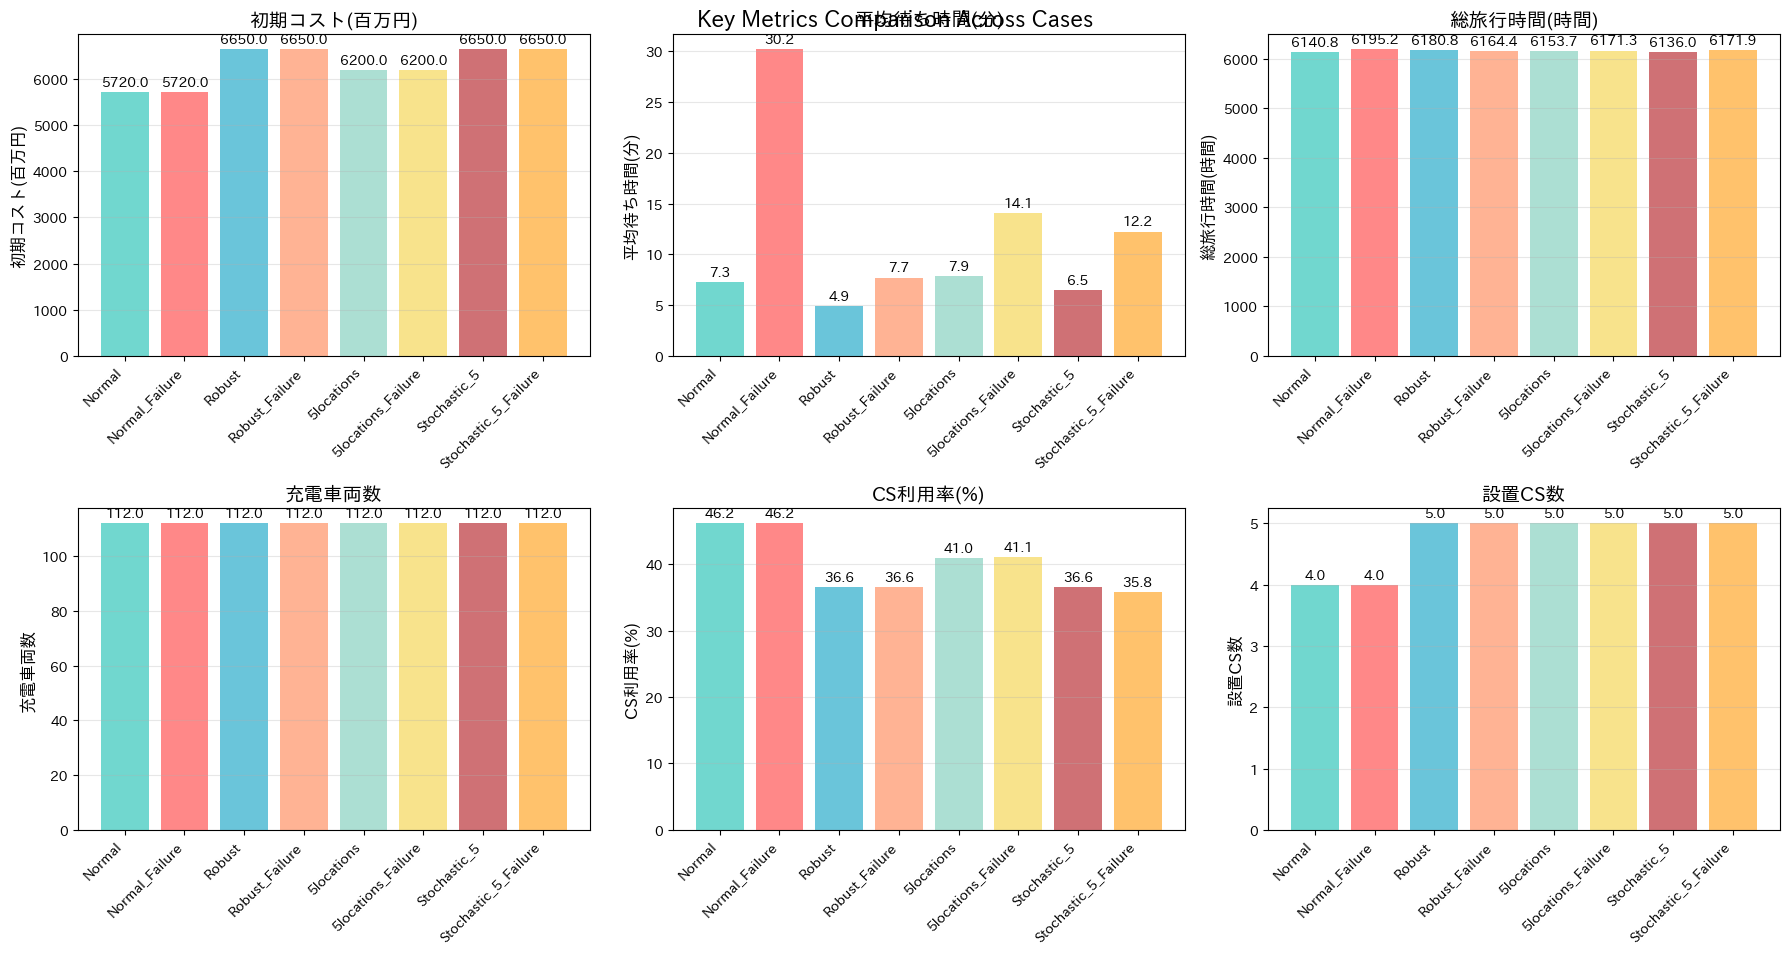

In [6]:
# comparison_dfを棒グラフで表示
def plot_key_metrics_comparison(comparison_df):
    """主要指標を棒グラフで比較表示"""
    
    metrics = comparison_df.columns[1:]  # 'ケース名'以外の列
    num_metrics = len(metrics)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    colors = ['#4ECDC4', '#FF6B6B', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F', '#C44E52', '#FFB347']
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        bars = ax.bar(comparison_df['ケース名'], comparison_df[metric], color=colors[:len(comparison_df)], alpha=0.8)
        ax.set_title(metric, fontsize=14, fontweight='bold')
        ax.set_ylabel(metric, fontsize=12)
        ax.set_xticklabels(comparison_df['ケース名'], rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        # 値をバーの上に表示
        for bar, val in zip(bars, comparison_df[metric]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(comparison_df[metric])*0.01, 
                    f'{val:.1f}', ha='center', va='bottom', fontsize=10)
    
    plt.suptitle('Key Metrics Comparison Across Cases', fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout()
    plt.show()
# 実行
plot_key_metrics_comparison(comparison_df)

###### a.2.2


=== 詳細結果サマリー（共通EVID） ===
              Case  WaitingTime_Minutes  TotalTripTime_Hours
0            Conv.                7.272             6140.813
1    Conv. Failure               26.531             6185.896
2    Conv. Failure               30.229             6193.072
3    Conv. Failure               16.543             6164.131
4    Conv. Failure               30.214             6195.200
5           Robust                4.932             6180.813
6   Robust Failure                7.820             6157.189
7   Robust Failure                8.840             6156.686
8   Robust Failure                8.406             6147.125
9   Robust Failure                7.125             6160.189
10  Robust Failure                7.704             6164.362


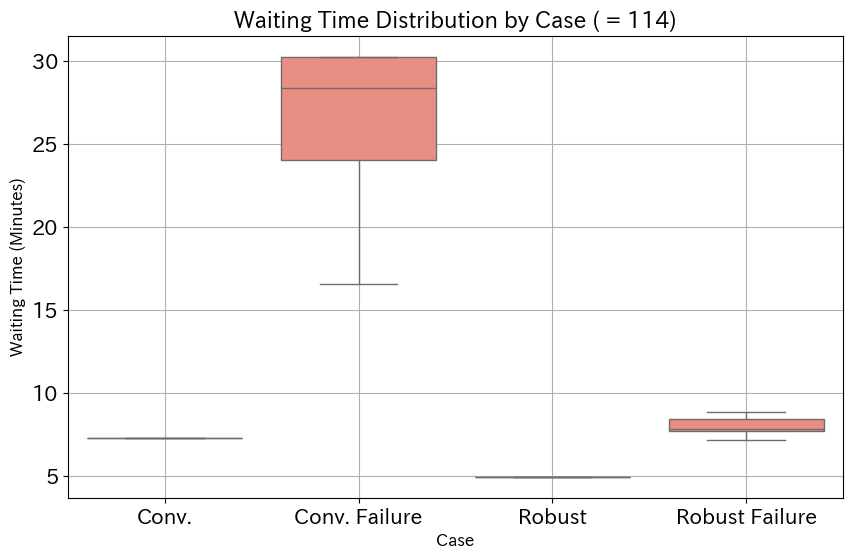

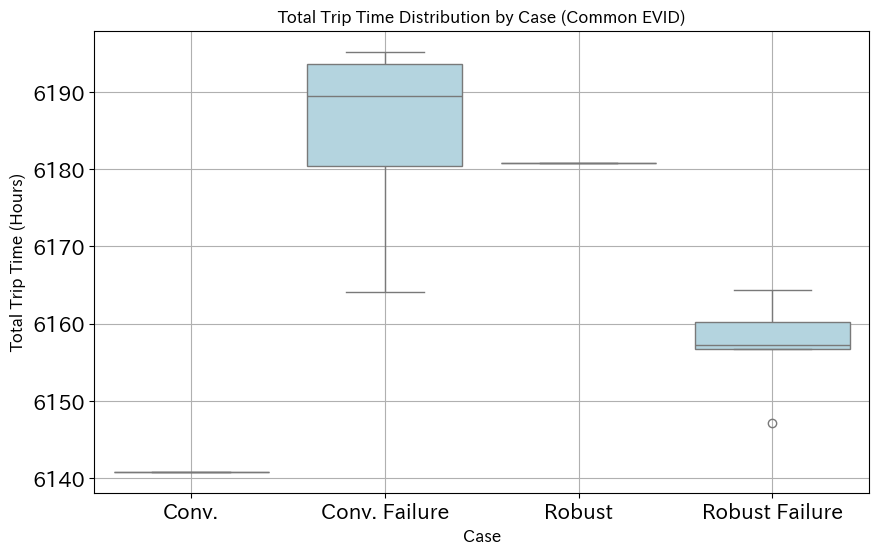

In [7]:
# 同一のEVIDを抽出する
def filter_trips_by_evid(vehicle_trip, evid_set):
    # トリップデータの前処理
    vehicle_trip = vehicle_trip[vehicle_trip['StartTime'] < 86400]
    vehicle_trip['TripTime'] = vehicle_trip['EndTime'] - vehicle_trip['StartTime']
    vehicle_trip['WaitingTime'] = vehicle_trip['startChargingTime'] - vehicle_trip['WaitingEntryTime']
    return vehicle_trip[vehicle_trip['EVID'].isin(evid_set)].copy()
# 例: Normalケースの共通EVIDでフィルタリング
EVID = unified_data['Normal']['vehicle_trip']['EVID'].unique()
waiting_normal_list = []
trip_normal_list = []
waiting_robust_list = []
trip_robust_list = []
for file in result_file_normal_failure_list:
    with open(file, 'rb') as f:
        data = pickle.load(f)
        vehicle_trip_normal_failure = data['vehicle_trip']
        vehicle_trip_normal_failure = filter_trips_by_evid(vehicle_trip_normal_failure, EVID)
        charging_trip = vehicle_trip_normal_failure[vehicle_trip_normal_failure['startChargingTime'] > 0]
        waiting_time = charging_trip['WaitingTime'].mean() /60
        trip_time = vehicle_trip_normal_failure['TripTime'].sum() /3600
        waiting_normal_list.append(waiting_time)
        trip_normal_list.append(trip_time)
for file in result_file_robust_failure_list:
    with open(file, 'rb') as f:
        data = pickle.load(f)
        vehicle_trip_robust_failure = data['vehicle_trip']
        vehicle_trip_robust_failure = filter_trips_by_evid(vehicle_trip_robust_failure, EVID)
        charging_trip = vehicle_trip_robust_failure[vehicle_trip_robust_failure['startChargingTime'] > 0]
        waiting_time = charging_trip['WaitingTime'].mean() /60
        trip_time = vehicle_trip_robust_failure['TripTime'].sum() /3600
        waiting_robust_list.append(waiting_time)
        trip_robust_list.append(trip_time)
# dfにまとめて表示
summary_df_detailed = pd.DataFrame({
    'Case':['Conv.'] + ['Conv. Failure'] * len(waiting_normal_list) + ['Robust'] + ['Robust Failure'] * len(waiting_robust_list),
    'WaitingTime_Minutes': [waiting_normal/60] + waiting_normal_list + [waiting_robust_health/60] + waiting_robust_list,
    'TotalTripTime_Hours': [total_trip_time_normal/3600] +trip_normal_list + [total_trip_time_robust_health/3600] + trip_robust_list
})
print("\n=== 詳細結果サマリー（共通EVID） ===")
print(summary_df_detailed)
# 箱ひげ図で可視化
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x='Case', y='WaitingTime_Minutes', data=summary_df_detailed, color ='salmon')
plt.title('Waiting Time Distribution by Case ( = 114)', fontsize=16)
plt.ylabel('Waiting Time (Minutes)', fontsize=12)
plt.xlabel('Case', fontsize=12)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Case', y='TotalTripTime_Hours', data=summary_df_detailed, color='lightblue')
plt.title('Total Trip Time Distribution by Case (Common EVID)')
plt.ylabel('Total Trip Time (Hours)', fontdict={'fontsize': 12})
plt.xlabel('Case', fontdict={'fontsize': 12})
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True)
plt.show()

全ケースでの結果を図に示す。このようにベースラインの最適配置では故障するCSによってパフォーマンスが大きく低下するが，ロバスト配置においてはどの故障シナリオにおいても幅は小さく頑健性の高いことは確認できる。
一方で，故障に強いロバスト配置においては充電車両の総旅行時間は減少しているが全ドライバーの総旅行時間を見ると増加しており，平常時のパフォーマンスは担保できていないことに加えて必ず故障すると仮定しているため過度に悲観的である。
そこで故障確率を考え，そのリスクによってどのように配置，性能が変化するのかを調査する。

##### 1.3全故障シナリオ

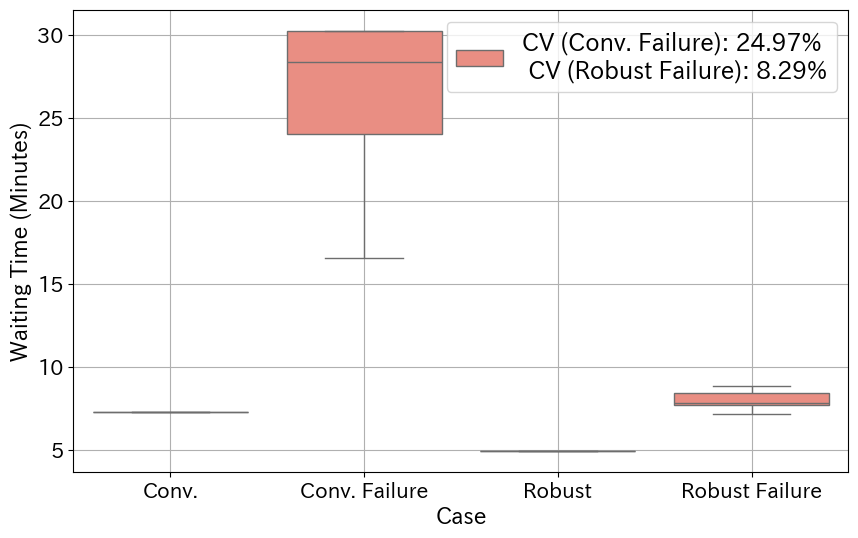

(array([-22500.000, -20000.000, -17500.000, -15000.000, -12500.000,
        -10000.000, -7500.000, -5000.000, -2500.000, 0.000, 2500.000]),
 [Text(0, -22500.0, '−22500'),
  Text(0, -20000.0, '−20000'),
  Text(0, -17500.0, '−17500'),
  Text(0, -15000.0, '−15000'),
  Text(0, -12500.0, '−12500'),
  Text(0, -10000.0, '−10000'),
  Text(0, -7500.0, '−7500'),
  Text(0, -5000.0, '−5000'),
  Text(0, -2500.0, '−2500'),
  Text(0, 0.0, '0'),
  Text(0, 2500.0, '2500')])

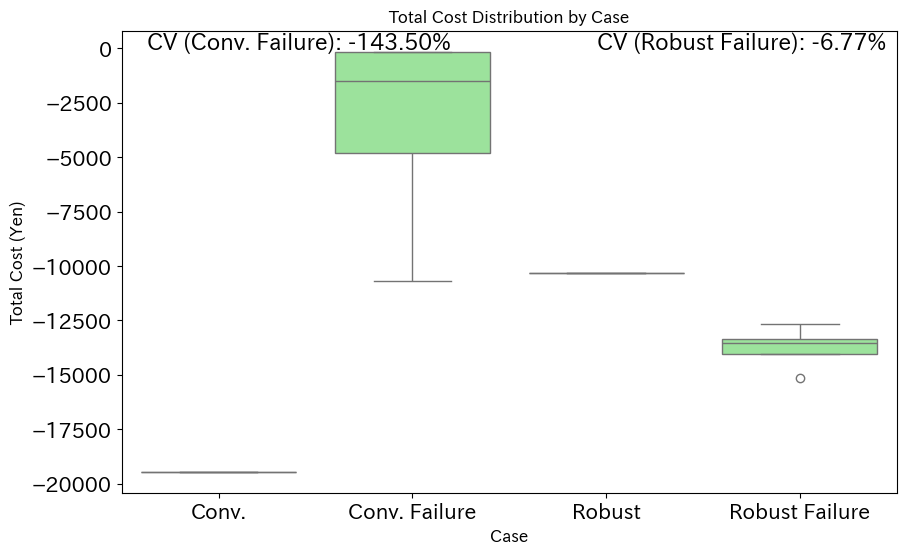

In [31]:
#
normal_stats = []
normal_failure_stats = []
robust_stats = []
robust_failure_stats = []
def add_stats(file, stats_list):
    with open(file, 'rb') as f:
        data = pickle.load(f)
        vehicle_trip = data['vehicle_trip']
        vehicle_trip = filter_trips_by_evid(vehicle_trip, EVID)
        charging_trip = vehicle_trip[vehicle_trip['startChargingTime'] > 0]
        waiting_time = charging_trip['WaitingTime'].mean() /60
        trip_time = vehicle_trip['TripTime'].sum() /3600
    total_cost = evaluation_total_costs(file)[0]  # 初期コスト
    initial_cost = calc_initial_costs(data['cs_config'], None)
    stats_list.append((waiting_time, trip_time, total_cost, initial_cost))
    return stats_list
add_stats(result_file_normal, normal_stats)
add_stats(result_file_robust, robust_stats)
for file in result_file_normal_failure_list:
    add_stats(file, normal_failure_stats)
for file in result_file_robust_failure_list:
    add_stats(file, robust_failure_stats)
# 目的関数の値も追加

# dfにまとめる
summary_df_detailed = pd.DataFrame({
    'Case':['Conv.']+['Conv. Failure'] * len(normal_failure_stats) + ['Robust']+['Robust Failure'] * len(robust_failure_stats),
    'WaitingTime_Minutes': [stat[0] for stat in normal_stats] + [stat[0] for stat in normal_failure_stats] + [stat[0] for stat in robust_stats] + [stat[0] for stat in robust_failure_stats],
    'TotalTripTime_Hours': [stat[1] for stat in normal_stats] + [stat[1] for stat in normal_failure_stats] + [stat[1] for stat in robust_stats] + [stat[1] for stat in robust_failure_stats],
    'TotalCost': [stat[2] for stat in normal_stats] + [stat[2] for stat in normal_failure_stats] + [stat[2] for stat in robust_stats] + [stat[2] for stat in robust_failure_stats]
})
# 箱ひげ図で可視化
import matplotlib.pyplot as plt
import seaborn as sns

# plt.title('Waiting Time Distribution by Case (n = 114)', fontsize=16)
# 平均待ち時間のCV値を計算して表示（Conv. FailureとRobust Failureごとに）
mean_waiting_time_normal = summary_df_detailed[summary_df_detailed['Case'] == 'Conv. Failure']['WaitingTime_Minutes'].mean()
mean_waiting_time_robust = summary_df_detailed[summary_df_detailed['Case'] == 'Robust Failure']['WaitingTime_Minutes'].mean()
std_waiting_time_conv_failure = summary_df_detailed[summary_df_detailed['Case'] == 'Conv. Failure']['WaitingTime_Minutes'].std()
cv_waiting_time_conv_failure = (std_waiting_time_conv_failure / mean_waiting_time_normal * 100) if mean_waiting_time_normal != 0 else 0
std_waiting_time_robust = summary_df_detailed[summary_df_detailed['Case'] == 'Robust Failure']['WaitingTime_Minutes'].std()
cv_waiting_time_robust = (std_waiting_time_robust / mean_waiting_time_robust * 100) if mean_waiting_time_robust != 0 else 0
# グラフにテキストで表示
plt.figure(figsize=(10, 6))
sns.boxplot(x='Case', y='WaitingTime_Minutes', data=summary_df_detailed, color ='salmon',
            label = f'CV (Conv. Failure): {cv_waiting_time_conv_failure:.2f}%\n CV (Robust Failure): {cv_waiting_time_robust:.2f}%')

plt.ylabel('Waiting Time (Minutes)', fontsize=16)
plt.xlabel('Case', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(loc ='upper right', fontsize=17)
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Case', y='TotalCost', data=summary_df_detailed, color='lightgreen')
plt.title('Total Cost Distribution by Case')
plt.ylabel('Total Cost (Yen)', fontdict={'fontsize': 12})
plt.xlabel('Case', fontdict={'fontsize': 12})
plt.xticks(fontsize=15)
# CV値を計算して表示
std_total_cost_conv_failure = summary_df_detailed[summary_df_detailed['Case'] == 'Conv. Failure']['TotalCost'].std()
mean_total_cost_conv_failure = summary_df_detailed[summary_df_detailed['Case'] == 'Conv. Failure']['TotalCost'].mean()
cv_total_cost_conv_failure = (std_total_cost_conv_failure / mean_total_cost_conv_failure * 100) if mean_total_cost_conv_failure != 0 else 0
std_total_cost_robust = summary_df_detailed[summary_df_detailed['Case'] == 'Robust Failure']['TotalCost'].std()
mean_total_cost_robust = summary_df_detailed[summary_df_detailed['Case'] == 'Robust Failure']['TotalCost'].mean()
cv_total_cost_robust = (std_total_cost_robust / mean_total_cost_robust * 100) if mean_total_cost_robust != 0 else 0
plt.figtext(0.15, 0.85, f'CV (Conv. Failure): {cv_total_cost_conv_failure:.2f}%', fontsize=16)
plt.figtext(0.6, 0.85, f'CV (Robust Failure): {cv_total_cost_robust:.2f}%', fontsize=16)
plt.yticks(fontsize=15)

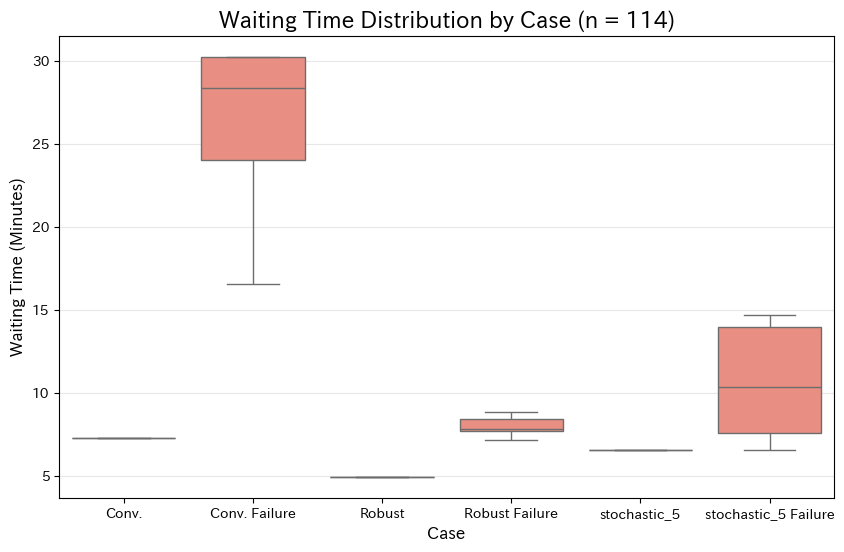

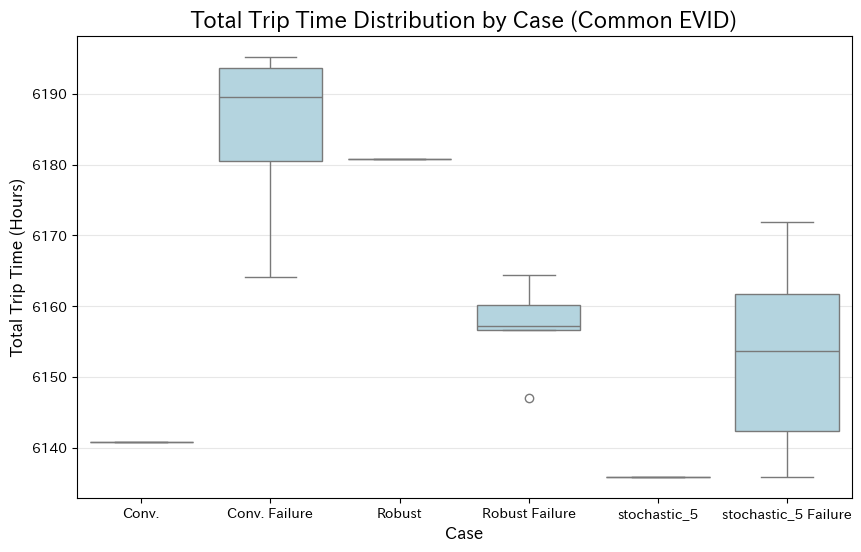

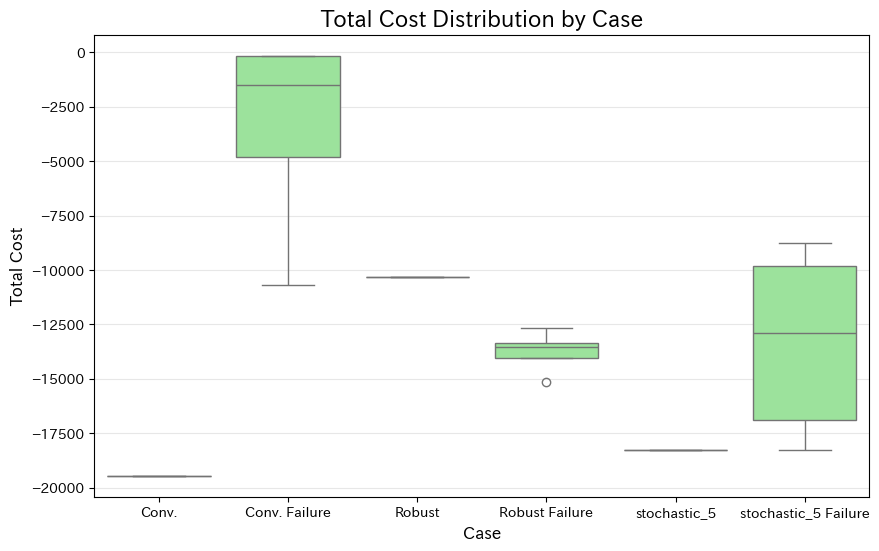

Text(0.5, 1.0, 'Initial Cost Distribution by Case')

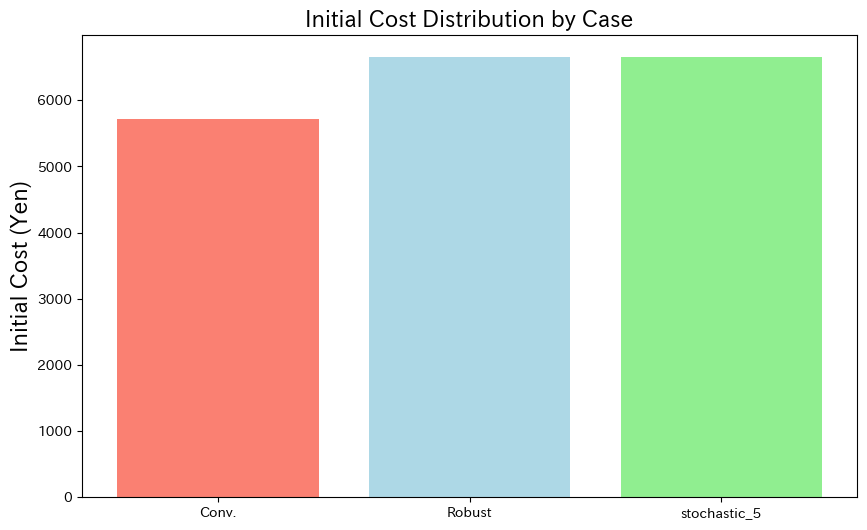

In [35]:
# 5か所とstochastic_5も追加
five_locations_stats = []
stochastic_5_stats = []
five_locations_failure_stats = []
stochastic_5_failure_stats = []

add_stats(result_file_5loc, five_locations_stats)
add_stats(result_file_stochastic_5, stochastic_5_stats)
for file in result_file_5loc_failure_list:
    add_stats(file, five_locations_failure_stats)
for file in result_file_stochastic_5_failure_list:
    add_stats(file, stochastic_5_failure_stats)

summary_df_detailed = pd.DataFrame({
    'Case':['Conv.']+['Conv. Failure'] * len(normal_failure_stats) + ['Robust']+['Robust Failure'] * len(robust_failure_stats) + ['5loc'] + ['5loc Failure'] * len(five_locations_failure_stats) + ['stochastic_5'] + ['stochastic_5 Failure'] * len(stochastic_5_failure_stats),
    'WaitingTime_Minutes': [stat[0] for stat in normal_stats] + [stat[0] for stat in normal_failure_stats] + [stat[0] for stat in robust_stats] + [stat[0] for stat in robust_failure_stats] + [stat[0] for stat in five_locations_stats] + [stat[0] for stat in five_locations_failure_stats] + [stat[0] for stat in stochastic_5_stats] + [stat[0] for stat in stochastic_5_failure_stats],
    'TotalTripTime_Hours': [stat[1] for stat in normal_stats] + [stat[1] for stat in normal_failure_stats] + [stat[1] for stat in robust_stats] + [stat[1] for stat in robust_failure_stats] + [stat[1] for stat in five_locations_stats] + [stat[1] for stat in five_locations_failure_stats] + [stat[1] for stat in stochastic_5_stats] + [stat[1] for stat in stochastic_5_failure_stats],
    'TotalCost': [stat[2] for stat in normal_stats] + [stat[2] for stat in normal_failure_stats] + [stat[2] for stat in robust_stats] + [stat[2] for stat in robust_failure_stats] + [stat[2] for stat in five_locations_stats] + [stat[2] for stat in five_locations_failure_stats] + [stat[2] for stat in stochastic_5_stats] + [stat[2] for stat in stochastic_5_failure_stats],
    'InitialCost': [stat[3] for stat in normal_stats] + [stat[3] for stat in normal_failure_stats] + [stat[3] for stat in robust_stats] + [stat[3] for stat in robust_failure_stats] + [stat[3] for stat in five_locations_stats] + [stat[3] for stat in five_locations_failure_stats] + [stat[3] for stat in stochastic_5_stats] + [stat[3] for stat in stochastic_5_failure_stats]
})

# 箱ひげ図で可視化
import matplotlib.pyplot as plt
import seaborn as sns
filtered_cases = ['5loc', '5loc Failure']
filtered_df = summary_df_detailed[~summary_df_detailed['Case'].isin(filtered_cases)]
plt.figure(figsize=(10, 6))
sns.boxplot(x='Case', y='WaitingTime_Minutes', data=filtered_df, color ='salmon')
plt.title('Waiting Time Distribution by Case (n = 114)', fontsize=16)
plt.xlabel('Case', fontsize=12)
plt.ylabel('Waiting Time (Minutes)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Case', y='TotalTripTime_Hours', data=filtered_df, color='lightblue')
plt.title('Total Trip Time Distribution by Case (Common EVID)', fontsize=16)
plt.xlabel('Case', fontsize=12)
plt.ylabel('Total Trip Time (Hours)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Case', y='TotalCost', data=filtered_df, color='lightgreen')
plt.title('Total Cost Distribution by Case', fontsize=16)
plt.xlabel('Case', fontsize=12)
plt.ylabel('Total Cost', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

# uniqueな初期コスト値を棒グラフで表示
unique_filtered_df = filtered_df[~filtered_df['Case'].str.contains('Failure')].drop_duplicates(subset=['Case', 'InitialCost'])
plt.figure(figsize=(10, 6))
plt.bar(unique_filtered_df['Case'], unique_filtered_df['InitialCost'], color=['salmon', 'lightblue', 'lightgreen', 'orange'])
plt.ylabel('Initial Cost (Yen)', fontsize=16)
plt.title('Initial Cost Distribution by Case', fontsize=16)

##### 構成の確認

In [10]:
def calculate_charging_time_with_capacity(result_files, case_names):
    """
    各ケースでvehicle_tripのCSIDとcs_configのcap_kwを結合し、充電時間を計算
    """
    
    all_charging_time_data = {}
    
    for result_file, case_name in zip(result_files, case_names):
        with open(result_file, 'rb') as f:
            data = pickle.load(f)
            cs_config = data['cs_config']
            vehicle_trip = data['vehicle_trip']
        
        # CS設定をDataFrameに変換
        cs_df = pd.DataFrame({
            'csids': cs_config['csids'],
            'ports': cs_config['ports'],
            'cap_kw': cs_config['cap_kw']
        })
        
        # 設置されたCSのみ（ports > 0）を抽出
        installed_cs = cs_df[cs_df['ports'] > 0].copy()
        
        # 充電車両のトリップを抽出
        charging_trips = vehicle_trip[
            (vehicle_trip['startChargingTime'] > 0) &
            (vehicle_trip['CSID'] > 0) &
            (vehicle_trip['CSID'].notna())
        ].copy()
        
        # CSIDとcs_configのcsidsを結合してcap_kwを取得
        charging_trips_with_capacity = pd.merge(
            charging_trips, 
            installed_cs[['csids', 'cap_kw', 'ports']], 
            left_on='CSID', 
            right_on='csids', 
            how='left'
        )
        
        # 充電時間を計算: InitialSOC * 60kWh / cap_kw
        # InitialSOCが充電する必要がある割合（1 - InitialSOC）として計算
        charging_trips_with_capacity['charging_need_kwh'] = (0.8 - charging_trips_with_capacity['InitialSOC']) * 60
        charging_trips_with_capacity['calculated_charging_time_hours'] = (
            charging_trips_with_capacity['charging_need_kwh'] / charging_trips_with_capacity['cap_kw']
        )
        charging_trips_with_capacity['calculated_charging_time_seconds'] = (
            charging_trips_with_capacity['calculated_charging_time_hours'] * 3600
        )
        
        print(f"\n=== {case_name} 充電時間計算結果 ===")
        print(f"充電トリップ数: {len(charging_trips_with_capacity)}")
        print(f"容量情報付きトリップ数: {len(charging_trips_with_capacity.dropna(subset=['cap_kw']))}")
        
        # 統計情報を表示
        valid_trips = charging_trips_with_capacity.dropna(subset=['cap_kw', 'calculated_charging_time_hours'])
        # CS別充電時間統計
        cs_charging_stats = valid_trips.groupby(['CSID', 'cap_kw']).agg({
            'calculated_charging_time_hours': ['mean', 'median', 'count'],
            'charging_need_kwh': ['mean', 'median']
        }).round(2)
        
        print(f"\nCS別充電時間統計:")
        for (csid, cap_kw), stats in cs_charging_stats.iterrows():
            print(f"  CSID {csid} ({cap_kw}kW): "
                  f"平均充電時間={stats[('calculated_charging_time_hours', 'mean')]:.2f}h, "
                  f"トリップ数={stats[('calculated_charging_time_hours', 'count')]}")
        
        all_charging_time_data[case_name] = {
            'cs_config': installed_cs,
            'charging_trips_with_time': charging_trips_with_capacity,
            'cs_charging_stats': cs_charging_stats,
            'valid_trips_count': len(valid_trips)
        }
    
    return all_charging_time_data

# 実行
charging_time_data = calculate_charging_time_with_capacity(result_files, case_names)



=== Normal 充電時間計算結果 ===
充電トリップ数: 122
容量情報付きトリップ数: 122

CS別充電時間統計:
  CSID 900000.0 (100kW): 平均充電時間=0.36h, トリップ数=47.0
  CSID 900002.0 (100kW): 平均充電時間=0.36h, トリップ数=34.0
  CSID 900010.0 (100kW): 平均充電時間=0.36h, トリップ数=20.0
  CSID 900012.0 (100kW): 平均充電時間=0.36h, トリップ数=21.0

=== Normal_Failure 充電時間計算結果 ===
充電トリップ数: 122
容量情報付きトリップ数: 122

CS別充電時間統計:
  CSID 900000.0 (100kW): 平均充電時間=0.36h, トリップ数=53.0
  CSID 900002.0 (100kW): 平均充電時間=0.36h, トリップ数=47.0
  CSID 900010.0 (100kW): 平均充電時間=0.36h, トリップ数=22.0

=== Robust 充電時間計算結果 ===
充電トリップ数: 121
容量情報付きトリップ数: 121

CS別充電時間統計:
  CSID 900000.0 (100kW): 平均充電時間=0.36h, トリップ数=45.0
  CSID 900002.0 (100kW): 平均充電時間=0.36h, トリップ数=31.0
  CSID 900006.0 (100kW): 平均充電時間=0.36h, トリップ数=17.0
  CSID 900012.0 (100kW): 平均充電時間=0.36h, トリップ数=9.0
  CSID 900014.0 (100kW): 平均充電時間=0.36h, トリップ数=19.0

=== Robust_Failure 充電時間計算結果 ===
充電トリップ数: 121
容量情報付きトリップ数: 121

CS別充電時間統計:
  CSID 900000.0 (100kW): 平均充電時間=0.36h, トリップ数=45.0
  CSID 900002.0 (100kW): 平均充電時間=0.36h, トリップ数=39.0
  CSID 900006.0 (

##### 1.2.1５カ所での平常時最適化


=== 更新されたsummary_df_detailed ===


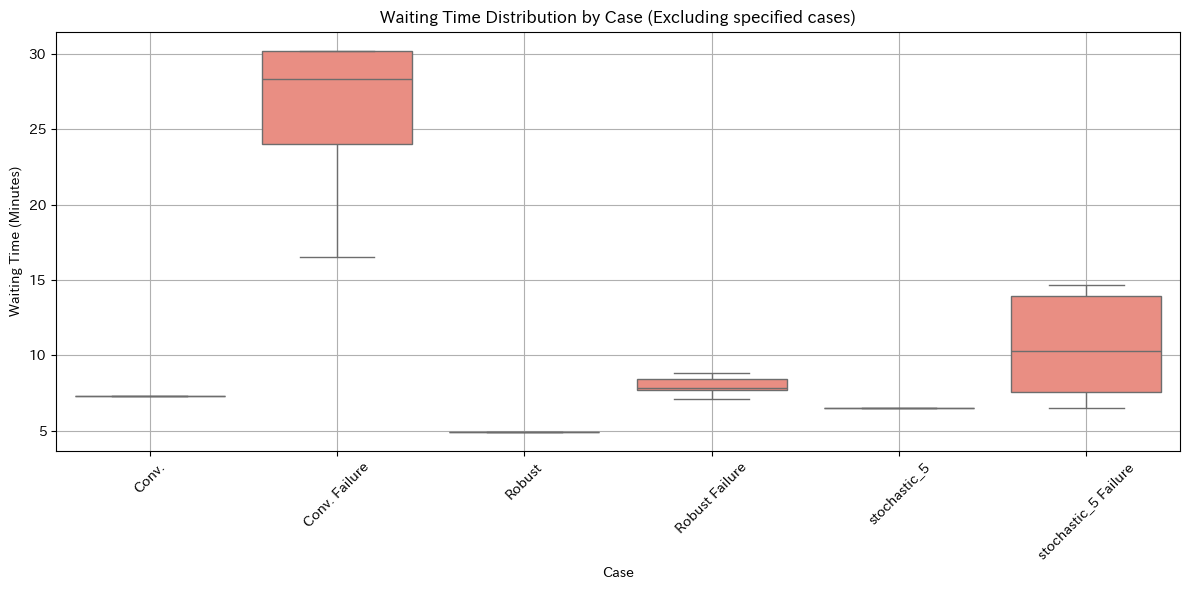

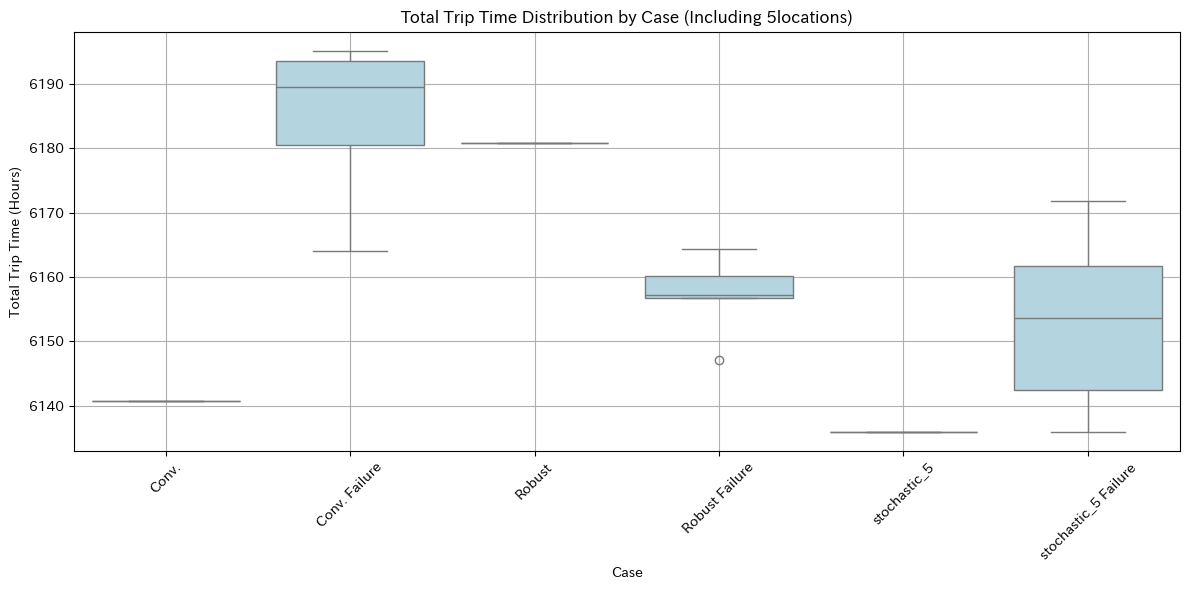

In [30]:
# waiting_5loc_list = []
# trip_5loc_list = []
# for file in result_file_5loc_failure_list:
#     with open(file, 'rb') as f:
#         data = pickle.load(f)
#         vehicle_trip_5loc_failure = data['vehicle_trip']
#         vehicle_trip_5loc_failure = filter_trips_by_evid(vehicle_trip_5loc_failure, EVID)
#         charging_trip = vehicle_trip_5loc_failure[vehicle_trip_5loc_failure['startChargingTime'] > 0]
#         waiting_time = charging_trip['WaitingTime'].mean() /60
#         trip_time = vehicle_trip_5loc_failure['TripTime'].sum() /3600
#         waiting_5loc_list.append(waiting_time)
#         trip_5loc_list.append(trip_time)
# waiting_5loc_normal = charging_trips_5loc['WaitingTime'].mean() /60
# trip_5loc_normal = unified_data['5locations']['vehicle_trip']['TripTime'].sum() /3600
# # リストをDataFrameに展開してから結合
# additional_5loc_data_list = []

# # 正常時のデータを追加
# additional_5loc_data_list.append({
#     'Case': '5locations',
#     'WaitingTime_Minutes': waiting_5loc_normal,
#     'TotalTripTime_Hours': trip_5loc_normal
# })

# # 故障時のデータを追加（各ファイルごとに行を作成）
# for i, (waiting, trip) in enumerate(zip(waiting_5loc_list, trip_5loc_list)):
#     additional_5loc_data_list.append({
#         'Case': '5locations_Failure',
#         'WaitingTime_Minutes': waiting,
#         'TotalTripTime_Hours': trip
#     })

# # DataFrameに変換
# additional_5loc_data = pd.DataFrame(additional_5loc_data_list)

# 30%確率ケースも同様に追加可能
waiting_stochastic_list = []
trip_stochastic_list = []
for file in result_file_stochastic_5_failure_list:
    with open(file, 'rb') as f:
        data = pickle.load(f)
        vehicle_trip_stochastic_failure = data['vehicle_trip']
        vehicle_trip_stochastic_failure = filter_trips_by_evid(vehicle_trip_stochastic_failure, EVID)
        charging_trip = vehicle_trip_stochastic_failure[vehicle_trip_stochastic_failure['startChargingTime'] > 0]
        waiting_time = charging_trip['WaitingTime'].mean() /60
        trip_time = vehicle_trip_stochastic_failure['TripTime'].sum() /3600
        waiting_stochastic_list.append(waiting_time)
        trip_stochastic_list.append(trip_time)
waiting_stochastic_normal = charging_trips_stochastic_5['WaitingTime'].mean() /60
trip_stochastic_normal = unified_data['Stochastic_5']['vehicle_trip']['TripTime'].sum() /3600
# リストをDataFrameに展開してから結合
additional_stochastic_data_list = []
# 正常時のデータを追加
additional_stochastic_data_list.append({
    'Case': 'stochastic_5',
    'WaitingTime_Minutes': waiting_stochastic_normal,
    'TotalTripTime_Hours': trip_stochastic_normal
})
# 故障時のデータを追加（各ファイルごとに行を作成）
for i, (waiting, trip) in enumerate(zip(waiting_stochastic_list, trip_stochastic_list)):
    additional_stochastic_data_list.append({
        'Case': 'stochastic_5_Failure',
        'WaitingTime_Minutes': waiting,
        'TotalTripTime_Hours': trip
    })
# DataFrameに変換
additional_stochastic_data = pd.DataFrame(additional_stochastic_data_list)

# 既存のDataFrameと結合
summary_df_add_5loc_final = pd.concat([summary_df_detailed, additional_stochastic_data], ignore_index=True)

print("\n=== 更新されたsummary_df_detailed ===")
# print(summary_df_add_5loc)

# 箱ひげ図も更新（5locケースを含む）
plt.figure(figsize=(12, 6))
# 特定のCaseを除外
filtered_df = summary_df_detailed[~summary_df_detailed['Case'].isin(['5loc','5loc Failure', 'Stochastic30', 'Stochastic30 Failure'])]

sns.boxplot(x='Case', y='WaitingTime_Minutes', data=filtered_df, color='salmon')
plt.title('Waiting Time Distribution by Case (Excluding specified cases)')
plt.ylabel('Waiting Time (Minutes)')
plt.xlabel('Case')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='Case', y='TotalTripTime_Hours', data=filtered_df, color='lightblue')
plt.title('Total Trip Time Distribution by Case (Including 5locations)')
plt.ylabel('Total Trip Time (Hours)')
plt.xlabel('Case')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

ロバスト最適配置とのCS箇所数を同一にして，通常最適化を行った結果平常時

##### 1.3 確率的最適化による性能

故障確率10%では平常時のみを考慮した最適化と同一の配置が確認された。

#### 1.1 各ユーザーの旅行時間箱ひげ図（充電車両と非充電車両）

###### 充電車両ごとの故障による旅行時間差分の累積分布非充電車両

=== CDF分析による旅行時間変化の専門的評価 ===
=== 非充電車両の旅行時間差分 詳細分析 ===


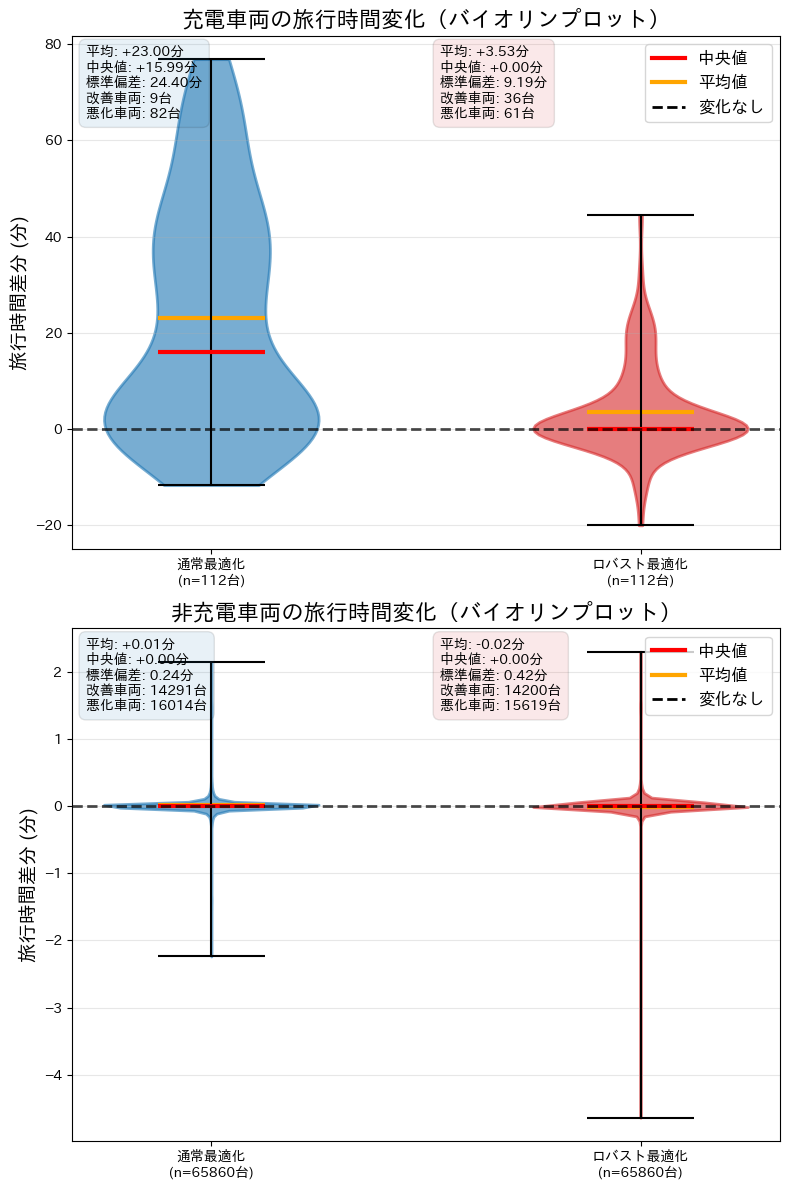

In [12]:
def analyze_user_travel_time_cdf(unified_data):
    """
    同一EVIDユーザーの旅行時間変化をCDF（累積分布関数）で分析
    """
    
    # 通常最適化とロバスト最適化のペアを定義
    comparison_pairs = [
        ('Normal', 'Normal_Failure', '通常最適化'),
        ('Robust', 'Robust_Failure', 'ロバスト最適化')
    ]
    
    all_user_differences = {}
    
    for normal_case, failure_case, opt_type in comparison_pairs:
        if normal_case not in unified_data or failure_case not in unified_data:
            print(f"警告: {normal_case} または {failure_case} のデータが見つかりません")
            continue
        
        # 各ケースの車両データを取得
        normal_data = unified_data[normal_case]['vehicle_trip']
        failure_data = unified_data[failure_case]['vehicle_trip']
        
        # EVID別の総旅行時間を計算
        normal_by_evid = normal_data.groupby('EVID').agg({
            'TripTime': 'sum',
            'startChargingTime': lambda x: (x > 0).any()  # 充電車両かどうか
        }).reset_index()
        normal_by_evid.columns = ['EVID', 'TripTime_Normal', 'IsCharging_Normal']
        
        failure_by_evid = failure_data.groupby('EVID').agg({
            'TripTime': 'sum',
            'startChargingTime': lambda x: (x > 0).any()
        }).reset_index()
        failure_by_evid.columns = ['EVID', 'TripTime_Failure', 'IsCharging_Failure']
        
        # 共通EVIDでマージ
        merged_data = pd.merge(normal_by_evid, failure_by_evid, on='EVID', how='inner')
        
        # 旅行時間差分を計算（分単位）
        merged_data['TripTime_Diff_Minutes'] = (merged_data['TripTime_Failure'] - merged_data['TripTime_Normal']) / 60
        
        # 車両タイプを統一
        merged_data['VehicleType'] = merged_data.apply(
            lambda row: '充電車両' if (row['IsCharging_Normal'] or row['IsCharging_Failure']) else '非充電車両',
            axis=1
        )
        
        all_user_differences[opt_type] = merged_data
    
    return all_user_differences

def plot_travel_time_cdf(all_user_differences):
    """
    旅行時間変化の累積分布関数（CDF）をプロット
    学術論文レベルの専門的な可視化
    """
    
    # カラーパレットとスタイルの設定
    colors = {
        '通常最適化': '#1f77b4',  # 青色
        'ロバスト最適化': '#d62728'  # 赤色
    }
    
    vehicle_types = ['充電車両', '非充電車両', '全車両']
    
    # 3つのサブプロット（充電車両、非充電車両、全車両）
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for subplot_idx, vehicle_type in enumerate(vehicle_types):
        ax = axes[subplot_idx]
        
        for opt_type, user_data in all_user_differences.items():
            if len(user_data) == 0:
                continue
            
            # 車両タイプ別にデータを抽出
            if vehicle_type == '全車両':
                type_data = user_data['TripTime_Diff_Minutes']
            else:
                type_data = user_data[user_data['VehicleType'] == vehicle_type]['TripTime_Diff_Minutes']
            
            if len(type_data) == 0:
                continue
            
            # CDFの計算
            sorted_data = np.sort(type_data)
            n = len(sorted_data)
            cumulative_prob = np.arange(1, n + 1) / n * 100  # パーセンテージ
            
            # CDFプロット
            ax.plot(sorted_data, cumulative_prob, 
                   color=colors[opt_type], 
                   linewidth=3, 
                   label=f'{opt_type} (n={n}台)',
                   alpha=0.9)
            
            # 統計情報の計算
            median_val = np.median(sorted_data)
            percentile_25 = np.percentile(sorted_data, 25)
            percentile_75 = np.percentile(sorted_data, 75)
            mean_val = np.mean(sorted_data)
            
            # 統計情報をテキストで表示
            stats_text = f'{opt_type}:\n中央値: {median_val:+.1f}分\n平均値: {mean_val:+.1f}分'
            
            # テキストボックスの位置を調整
            text_x = 0.95 if opt_type == 'ロバスト最適化' else 0.05
            text_y = 0.25 if opt_type == 'ロバスト最適化' else 0.75
            
            ax.text(text_x, text_y, stats_text, 
                   transform=ax.transAxes,
                   bbox=dict(boxstyle='round,pad=0.5', 
                           facecolor=colors[opt_type], alpha=0.1),
                   verticalalignment='top' if opt_type == '通常最適化' else 'bottom',
                   horizontalalignment='left' if opt_type == '通常最適化' else 'right',
                   fontsize=11)
        
        # 0分線（変化なし）を強調
        ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
        
        # 軸とタイトルの設定
        ax.set_xlabel('旅行時間変化 (分)', fontsize=14)
        ax.set_ylabel('累積確率 (%)', fontsize=14)
        ax.set_title(f'{vehicle_type}の旅行時間変化CDF', fontsize=16, fontweight='bold')
        
        # グリッドと凡例
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=12, loc='center right')
        
        # Y軸の範囲を0-100%に設定
        ax.set_ylim(0, 100)
        
        # 主要なパーセンタイル線を追加
        for percentile in [25, 50, 75]:
            ax.axhline(y=percentile, color='gray', linestyle=':', alpha=0.5, linewidth=0.8)
    
    plt.suptitle('故障シナリオにおける旅行時間変化の累積分布比較', 
                 fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def plot_improvement_analysis_cdf(all_user_differences):
    """
    改善効果の詳細分析用CDF
    """
    
    if '通常最適化' not in all_user_differences or 'ロバスト最適化' not in all_user_differences:
        print("比較データが不足しています")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 充電車両の比較
    conv_charging = all_user_differences['通常最適化'][
        all_user_differences['通常最適化']['VehicleType'] == '充電車両'
    ]['TripTime_Diff_Minutes']
    
    robust_charging = all_user_differences['ロバスト最適化'][
        all_user_differences['ロバスト最適化']['VehicleType'] == '充電車両'
    ]['TripTime_Diff_Minutes']
    
    # 非充電車両の比較
    conv_non_charging = all_user_differences['通常最適化'][
        all_user_differences['通常最適化']['VehicleType'] == '非充電車両'
    ]['TripTime_Diff_Minutes']
    
    robust_non_charging = all_user_differences['ロバスト最適化'][
        all_user_differences['ロバスト最適化']['VehicleType'] == '非充電車両'
    ]['TripTime_Diff_Minutes']
    
    # 充電車両のCDF
    for data, label, color in [(conv_charging, '通常最適化', '#1f77b4'), 
                               (robust_charging, 'ロバスト最適化', '#d62728')]:
        if len(data) > 0:
            sorted_data = np.sort(data)
            cumulative_prob = np.arange(1, len(sorted_data) + 1) / len(sorted_data) * 100
            ax1.plot(sorted_data, cumulative_prob, color=color, linewidth=3, 
                    label=f'{label} (n={len(data)}台)', alpha=0.9)
            
            # 悪化した車両の割合を計算
            worsened_ratio = (data > 0).mean() * 100
            ax1.text(0.05, 0.95 - (0 if '通常' in label else 0.15), 
                    f'{label}\n悪化車両: {worsened_ratio:.1f}%', 
                    transform=ax1.transAxes,
                    bbox=dict(boxstyle='round', facecolor=color, alpha=0.1),
                    fontsize=11)
    
    ax1.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    ax1.set_xlabel('旅行時間変化 (分)', fontsize=14)
    ax1.set_ylabel('累積確率 (%)', fontsize=14)
    ax1.set_title('充電車両の旅行時間変化CDF', fontsize=16, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=12)
    ax1.set_ylim(0, 100)
    
    # 非充電車両のCDF
    for data, label, color in [(conv_non_charging, '通常最適化', '#1f77b4'), 
                               (robust_non_charging, 'ロバスト最適化', '#d62728')]:
        if len(data) > 0:
            sorted_data = np.sort(data)
            cumulative_prob = np.arange(1, len(sorted_data) + 1) / len(sorted_data) * 100
            ax2.plot(sorted_data, cumulative_prob, color=color, linewidth=3, 
                    label=f'{label} (n={len(data)}台)', alpha=0.9)
            
            # 悪化した車両の割合を計算
            worsened_ratio = (data > 0).mean() * 100
            ax2.text(0.05, 0.95 - (0 if '通常' in label else 0.15), 
                    f'{label}\n悪化車両: {worsened_ratio:.1f}%', 
                    transform=ax2.transAxes,
                    bbox=dict(boxstyle='round', facecolor=color, alpha=0.1),
                    fontsize=11)
    
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    ax2.set_xlabel('旅行時間変化 (分)', fontsize=14)
    ax2.set_ylabel('累積確率 (%)', fontsize=14)
    ax2.set_title('非充電車両の旅行時間変化CDF', fontsize=16, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=12)
    ax2.set_ylim(0, 100)
    
    plt.suptitle('車両タイプ別 旅行時間変化の累積分布比較', 
                 fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

def calculate_cdf_statistics(all_user_differences):
    """
    CDF分析に基づく詳細統計を計算
    """
    
    statistics = []
    
    for opt_type, user_data in all_user_differences.items():
        for vehicle_type in ['充電車両', '非充電車両', '全車両']:
            if vehicle_type == '全車両':
                type_data = user_data['TripTime_Diff_Minutes']
            else:
                type_data = user_data[user_data['VehicleType'] == vehicle_type]['TripTime_Diff_Minutes']
            
            if len(type_data) == 0:
                continue
            
            # 統計指標の計算
            stats = {
                '最適化手法': opt_type,
                '車両タイプ': vehicle_type,
                '車両数': len(type_data),
                '平均変化(分)': type_data.mean(),
                '中央値変化(分)': type_data.median(),
                '標準偏差(分)': type_data.std(),
                '最小変化(分)': type_data.min(),
                '最大変化(分)': type_data.max(),
                '25%ile(分)': np.percentile(type_data, 25),
                '75%ile(分)': np.percentile(type_data, 75),
                '90%ile(分)': np.percentile(type_data, 90),
                '95%ile(分)': np.percentile(type_data, 95),
                '改善車両割合(%)': (type_data < 0).mean() * 100,
                '悪化車両割合(%)': (type_data > 0).mean() * 100,
                '変化なし車両割合(%)': (type_data == 0).mean() * 100
            }
            
            statistics.append(stats)
    
    return pd.DataFrame(statistics)

# 分析実行
print("=== CDF分析による旅行時間変化の専門的評価 ===")

# CDFデータの計算
user_differences_cdf = analyze_user_travel_time_cdf(unified_data)

# CDFプロットの作成
# plot_travel_time_cdf(user_differences_cdf)

# 改善効果の詳細分析
# plot_improvement_analysis_cdf(user_differences_cdf)

# 詳細統計の計算と表示
cdf_statistics = calculate_cdf_statistics(user_differences_cdf)

# CSVとして保存
# cdf_statistics.round(3).to_csv("travel_time_cdf_analysis.csv", index=False, encoding='utf-8-sig')
# print("\nCDF分析結果をCSVに保存しました: travel_time_cdf_analysis.csv")

# # 主要な知見を数値で要約
# print("\n=== 主要な知見（CDF分析） ===")

# if '通常最適化' in user_differences_cdf and 'ロバスト最適化' in user_differences_cdf:
#     # 充電車両での比較
#     conv_charging = user_differences_cdf['通常最適化'][
#         user_differences_cdf['通常最適化']['VehicleType'] == '充電車両'
#     ]['TripTime_Diff_Minutes']
    
#     robust_charging = user_differences_cdf['ロバスト最適化'][
#         user_differences_cdf['ロバスト最適化']['VehicleType'] == '充電車両'
#     ]['TripTime_Diff_Minutes']
    
#     if len(conv_charging) > 0 and len(robust_charging) > 0:
#         print(f"\n【充電車両の改善効果】")
#         print(f"通常最適化 - 悪化車両割合: {(conv_charging > 0).mean()*100:.1f}%")
#         print(f"ロバスト最適化 - 悪化車両割合: {(robust_charging > 0).mean()*100:.1f}%")
#         print(f"悪化車両割合の改善: {(conv_charging > 0).mean()*100 - (robust_charging > 0).mean()*100:+.1f}ポイント")
        
def plot_non_charging_vehicle_boxplots(all_user_differences):
    """
    非充電車両の旅行時間差分を箱ひげ図とバイオリンプロットで詳細分析
    """
    
    # 非充電車両のデータを抽出
    charging_data = {}
    non_charging_data = {}
    for opt_type, user_data in all_user_differences.items():
        charging_vehicles = user_data[user_data['VehicleType'] == '充電車両']['TripTime_Diff_Minutes']
        non_charging_vehicles = user_data[user_data['VehicleType'] == '非充電車両']['TripTime_Diff_Minutes']
        
        if len(charging_vehicles) > 0:
            charging_data[opt_type] = charging_vehicles
        if len(non_charging_vehicles) > 0:
            non_charging_data[opt_type] = non_charging_vehicles
    
    # 1. 箱ひげ図での比較
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1-1. 箱ひげ図
    data_to_plot_charging = []
    data_to_plot_noncharging = []
    labels = []
    colors = ['#1f77b4', '#d62728']  # 青、赤

    for i, (opt_type, data) in enumerate(charging_data.items()):
        data_to_plot_charging.append(data)
        labels.append(f'{opt_type}\n(n={len(data)}台)')
   
    for i, (opt_type, data) in enumerate(non_charging_data.items()):
        data_to_plot_charging.append(data)
        labels.append(f'{opt_type}\n(n={len(data)}台)')
    
    # 箱ひげ図の作成
    # bp = ax1.boxplot(data_to_plot_charging, labels=labels, patch_artist=True,
    #                  showfliers=True, flierprops=dict(marker='o', markersize=3, alpha=0.5))
    # 色の設定
    # for patch, color in zip(bp['boxes'], colors):
    #     patch.set_facecolor(color)
    #     patch.set_alpha(0.3)
    #     patch.set_edgecolor(color)
    #     patch.set_linewidth(2)
    
    # # 中央値線を強調
    # for median in bp['medians']:
    #     median.set_color('red')
    #     median.set_linewidth(3)
    
    # # ウィスカーとキャップの色設定
    # for whisker in bp['whiskers']:
    #     whisker.set_color('black')
    #     whisker.set_linewidth(2)
    
    # for cap in bp['caps']:
    #     cap.set_color('black')
    #     cap.set_linewidth(2)
    
    # # 0分線（変化なし）を強調
    # ax1.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7)
    
    # ax1.set_title('非充電車両の旅行時間変化（箱ひげ図）', fontsize=16, fontweight='bold')
    # ax1.set_ylabel('旅行時間差分 (分)', fontsize=14)
    # ax1.grid(axis='y', alpha=0.3)
    
    # 統計情報を表示
    for i, (opt_type, data) in enumerate(charging_data.items()):
        stats_text = (f'平均: {data.mean():+.2f}分\n'
                     f'中央値: {data.median():+.2f}分\n'
                     f'標準偏差: {data.std():.2f}分\n'
                     f'改善車両: {(data < 0).sum()}台\n'
                     f'悪化車両: {(data > 0).sum()}台')
        
        # テキストボックスの位置を調整
        text_x = 0.02 if i == 0 else 0.52
        ax1.text(text_x, 0.98, stats_text, 
                transform=ax1.transAxes,
                bbox=dict(boxstyle='round,pad=0.5', 
                         facecolor=colors[i], alpha=0.1),
                verticalalignment='top',
                fontsize=10)
        # 1-2. バイオリンプロット
    parts = ax1.violinplot(data_to_plot_charging, positions=range(1, len(data_to_plot_charging)-1), 
                          showmeans=True, showmedians=True, showextrema=True)
    
    # バイオリンプロットの色設定
    for i, pc in enumerate(parts['bodies']):
        print(i)
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.6)
        pc.set_edgecolor(colors[i])
        pc.set_linewidth(2)
    
    # 統計線の設定
    parts['cmeans'].set_color('orange')
    parts['cmeans'].set_linewidth(3)
    parts['cmedians'].set_color('red')
    parts['cmedians'].set_linewidth(3)
    parts['cbars'].set_color('black')
    parts['cmins'].set_color('black')
    parts['cmaxes'].set_color('black')
    
    # 0分線を追加
    ax1.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7)

    ax1.set_title('充電車両の旅行時間変化（バイオリンプロット）', fontsize=16, fontweight='bold')
    ax1.set_ylabel('旅行時間差分 (分)', fontsize=14)
    ax1.set_xticks(range(1, len(labels)+1))
    ax1.set_xticklabels(labels)
    ax1.grid(axis='y', alpha=0.3)
        # カスタム凡例を追加
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='red', linewidth=3, label='中央値'),
        Line2D([0], [0], color='orange', linewidth=3, label='平均値'),
        Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='変化なし')
    ]

    ax1.legend(handles=legend_elements, loc='upper right', fontsize=12)

    # 1-2. バイオリンプロット
    parts = ax2.violinplot(data_to_plot_noncharging, positions=range(1, len(data_to_plot_noncharging)+1), 
                          showmeans=True, showmedians=True, showextrema=True)
    
    # バイオリンプロットの色設定
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.6)
        pc.set_edgecolor(colors[i])
        pc.set_linewidth(2)
    
    # 統計線の設定
    parts['cmeans'].set_color('orange')
    parts['cmeans'].set_linewidth(3)
    parts['cmedians'].set_color('red')
    parts['cmedians'].set_linewidth(3)
    parts['cbars'].set_color('black')
    parts['cmins'].set_color('black')
    parts['cmaxes'].set_color('black')
    
    # 0分線を追加
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7)
    
    ax2.set_title('非充電車両の旅行時間変化（バイオリンプロット）', fontsize=16, fontweight='bold')
    ax2.set_ylabel('旅行時間差分 (分)', fontsize=14)
    ax2.set_xticks(range(1, len(labels)+1))
    ax2.set_xticklabels(labels)
    ax2.grid(axis='y', alpha=0.3)
    
    # カスタム凡例を追加
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='red', linewidth=3, label='中央値'),
        Line2D([0], [0], color='orange', linewidth=3, label='平均値'),
        Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='変化なし')
    ]
    ax2.legend(handles=legend_elements, loc='upper right', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
def plot_non_charging_vehicle_boxplots(all_user_differences):
    """
    非充電車両の旅行時間差分を箱ひげ図とバイオリンプロットで詳細分析
    """
    
    # 非充電車両のデータを抽出
    charging_data = {}
    non_charging_data = {}
    for opt_type, user_data in all_user_differences.items():
        charging_vehicles = user_data[user_data['VehicleType'] == '充電車両']['TripTime_Diff_Minutes']
        non_charging_vehicles = user_data[user_data['VehicleType'] == '非充電車両']['TripTime_Diff_Minutes']
        
        if len(charging_vehicles) > 0:
            charging_data[opt_type] = charging_vehicles
        if len(non_charging_vehicles) > 0:
            non_charging_data[opt_type] = non_charging_vehicles
    
    # 1. 箱ひげ図での比較
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 12))
    
    # 1-1. 充電車両データの準備
    data_to_plot_charging = []
    data_to_plot_noncharging = []
    labels_charging = []
    labels_noncharging = []
    colors = ['#1f77b4', '#d62728']  # 青、赤

    for i, (opt_type, data) in enumerate(charging_data.items()):
        data_to_plot_charging.append(data)
        labels_charging.append(f'{opt_type}\n(n={len(data)}台)')
   
    for i, (opt_type, data) in enumerate(non_charging_data.items()):
        data_to_plot_noncharging.append(data)
        labels_noncharging.append(f'{opt_type}\n(n={len(data)}台)')
    
    # 統計情報を表示
    for i, (opt_type, data) in enumerate(charging_data.items()):
        stats_text = (f'平均: {data.mean():+.2f}分\n'
                     f'中央値: {data.median():+.2f}分\n'
                     f'標準偏差: {data.std():.2f}分\n'
                     f'改善車両: {(data < 0).sum()}台\n'
                     f'悪化車両: {(data > 0).sum()}台')
        
        # テキストボックスの位置を調整
        text_x = 0.02 if i == 0 else 0.52
        ax1.text(text_x, 0.98, stats_text, 
                transform=ax1.transAxes,
                bbox=dict(boxstyle='round,pad=0.5', 
                         facecolor=colors[min(i, len(colors)-1)], alpha=0.1),
                verticalalignment='top',
                fontsize=10)
    
    # 1-2. 充電車両のバイオリンプロット
    if data_to_plot_charging:
        parts = ax1.violinplot(data_to_plot_charging, positions=range(1, len(data_to_plot_charging)+1), 
                              showmeans=True, showmedians=True, showextrema=True)
        
        # バイオリンプロットの色設定
        for i, pc in enumerate(parts['bodies']):
            color_idx = min(i, len(colors)-1)  # インデックスを範囲内に制限
            pc.set_facecolor(colors[color_idx])
            pc.set_alpha(0.6)
            pc.set_edgecolor(colors[color_idx])
            pc.set_linewidth(2)
        
        # 統計線の設定
        parts['cmeans'].set_color('orange')
        parts['cmeans'].set_linewidth(3)
        parts['cmedians'].set_color('red')
        parts['cmedians'].set_linewidth(3)
        parts['cbars'].set_color('black')
        parts['cmins'].set_color('black')
        parts['cmaxes'].set_color('black')
        
        ax1.set_xticks(range(1, len(labels_charging)+1))
        ax1.set_xticklabels(labels_charging)
    
    # 0分線を追加
    ax1.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7)

    ax1.set_title('充電車両の旅行時間変化（バイオリンプロット）', fontsize=16, fontweight='bold')
    ax1.set_ylabel('旅行時間差分 (分)', fontsize=14)
    ax1.grid(axis='y', alpha=0.3)
    
    # カスタム凡例を追加
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='red', linewidth=3, label='中央値'),
        Line2D([0], [0], color='orange', linewidth=3, label='平均値'),
        Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='変化なし')
    ]

    ax1.legend(handles=legend_elements, loc='upper right', fontsize=12)

    # 1-3. 非充電車両のバイオリンプロット
        # 統計情報を表示
    for i, (opt_type, data) in enumerate(non_charging_data.items()):
        stats_text = (f'平均: {data.mean():+.2f}分\n'
                     f'中央値: {data.median():+.2f}分\n'
                     f'標準偏差: {data.std():.2f}分\n'
                     f'改善車両: {(data < 0).sum()}台\n'
                     f'悪化車両: {(data > 0).sum()}台')
        
        # テキストボックスの位置を調整
        text_x = 0.02 if i == 0 else 0.52
        ax2.text(text_x, 0.98, stats_text, 
                transform=ax2.transAxes,
                bbox=dict(boxstyle='round,pad=0.5', 
                         facecolor=colors[min(i, len(colors)-1)], alpha=0.1),
                verticalalignment='top',
                fontsize=10)
        
    if data_to_plot_noncharging:
        parts = ax2.violinplot(data_to_plot_noncharging, positions=range(1, len(data_to_plot_noncharging)+1), 
                              showmeans=True, showmedians=True, showextrema=True)
        
        # バイオリンプロットの色設定
        for i, pc in enumerate(parts['bodies']):
            color_idx = min(i, len(colors)-1)  # インデックスを範囲内に制限
            pc.set_facecolor(colors[color_idx])
            pc.set_alpha(0.6)
            pc.set_edgecolor(colors[color_idx])
            pc.set_linewidth(2)
        
        # 統計線の設定
        parts['cmeans'].set_color('orange')
        parts['cmeans'].set_linewidth(3)
        parts['cmedians'].set_color('red')
        parts['cmedians'].set_linewidth(3)
        parts['cbars'].set_color('black')
        parts['cmins'].set_color('black')
        parts['cmaxes'].set_color('black')
        
        ax2.set_xticks(range(1, len(labels_noncharging)+1))
        ax2.set_xticklabels(labels_noncharging)
    
    # 0分線を追加
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7)
    
    ax2.set_title('非充電車両の旅行時間変化（バイオリンプロット）', fontsize=16, fontweight='bold')
    ax2.set_ylabel('旅行時間差分 (分)', fontsize=14)
    ax2.grid(axis='y', alpha=0.3)
    
    # カスタム凡例を追加
    legend_elements = [
        Line2D([0], [0], color='red', linewidth=3, label='中央値'),
        Line2D([0], [0], color='orange', linewidth=3, label='平均値'),
        Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='変化なし')
    ]
    ax2.legend(handles=legend_elements, loc='upper right', fontsize=12)
    
    plt.tight_layout()
    plt.show()

def plot_detailed_non_charging_analysis(all_user_differences):
    """
    非充電車両の詳細分析（分布の形状、外れ値、パーセンタイル分析）
    """
    
    # 非充電車両のデータを抽出
    non_charging_data = {}
    for opt_type, user_data in all_user_differences.items():
        non_charging_vehicles = user_data[user_data['VehicleType'] == '非充電車両']['TripTime_Diff_Minutes']
        if len(non_charging_vehicles) > 0:
            non_charging_data[opt_type] = non_charging_vehicles
    
    if not non_charging_data:
        return
    
    # 2x2のサブプロット
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # 2-1. ヒストグラム比較（密度）
    for opt_type, data in non_charging_data.items():
        color = '#1f77b4' if opt_type == '通常最適化' else '#d62728'
        alpha = 0.7 if opt_type == '通常最適化' else 0.5
        
        ax1.hist(data, bins=50, density=True, alpha=alpha, 
                color=color, label=f'{opt_type} (n={len(data)}台)', 
                edgecolor='black', linewidth=0.5)
    
    ax1.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.7)
    ax1.set_title('非充電車両旅行時間変化の分布（密度）', fontsize=14, fontweight='bold')
    ax1.set_xlabel('旅行時間差分 (分)', fontsize=12)
    ax1.set_ylabel('密度', fontsize=12)
    ax1.legend(fontsize=12)
    ax1.grid(alpha=0.3)
    
    # 2-2. Q-Qプロット（分位点比較）
    if len(non_charging_data) == 2:
        opt_types = list(non_charging_data.keys())
        data1 = non_charging_data[opt_types[0]]
        data2 = non_charging_data[opt_types[1]]
        
        # 分位点を計算
        percentiles = np.linspace(0, 100, 101)
        q1 = np.percentile(data1, percentiles)
        q2 = np.percentile(data2, percentiles)
        
        ax2.scatter(q1, q2, alpha=0.6, s=20)
        
        # 45度線（等しい分布なら点がこの線上に乗る）
        min_val = min(q1.min(), q2.min())
        max_val = max(q1.max(), q2.max())
        ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, alpha=0.7)
        
        ax2.set_title('Q-Qプロット：分位点比較', fontsize=14, fontweight='bold')
        ax2.set_xlabel(f'{opt_types[0]} 分位点 (分)', fontsize=12)
        ax2.set_ylabel(f'{opt_types[1]} 分位点 (分)', fontsize=12)
        ax2.grid(alpha=0.3)
        
        # 対角線からの偏差を示すテキスト
        ax2.text(0.05, 0.95, '対角線上：分布が同じ\n'
                             '対角線より上：右の分布がより大きい\n'
                             '対角線より下：左の分布がより大きい', 
                transform=ax2.transAxes, fontsize=10,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # 2-3. パーセンタイル比較
    percentiles_to_show = [5, 10, 25, 50, 75, 90, 95]
    width = 0.35
    x_pos = np.arange(len(percentiles_to_show))
    
    for i, (opt_type, data) in enumerate(non_charging_data.items()):
        percentile_values = [np.percentile(data, p) for p in percentiles_to_show]
        color = '#1f77b4' if opt_type == '通常最適化' else '#d62728'
        
        ax3.bar(x_pos + i*width, percentile_values, width, 
               label=opt_type, color=color, alpha=0.7)
    
    ax3.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7)
    ax3.set_title('パーセンタイル別旅行時間変化', fontsize=14, fontweight='bold')
    ax3.set_xlabel('パーセンタイル', fontsize=12)
    ax3.set_ylabel('旅行時間差分 (分)', fontsize=12)
    ax3.set_xticks(x_pos + width/2)
    ax3.set_xticklabels([f'{p}%' for p in percentiles_to_show])
    ax3.legend(fontsize=12)
    ax3.grid(axis='y', alpha=0.3)
    
    # 2-4. 外れ値分析
    outlier_stats = []
    for opt_type, data in non_charging_data.items():
        Q1 = np.percentile(data, 25)
        Q3 = np.percentile(data, 75)
        IQR = Q3 - Q1
        
        # 外れ値の定義（IQRの1.5倍）
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        outlier_ratio = len(outliers) / len(data) * 100
        
        outlier_stats.append({
            '最適化手法': opt_type,
            '外れ値数': len(outliers),
            '外れ値割合(%)': outlier_ratio,
            '下限': lower_bound,
            '上限': upper_bound,
            '最小外れ値': outliers.min() if len(outliers) > 0 else None,
            '最大外れ値': outliers.max() if len(outliers) > 0 else None
        })
    
    # 外れ値統計をテーブル表示
    outlier_df = pd.DataFrame(outlier_stats)
    
    # テーブルを軸に表示
    ax4.axis('tight')
    ax4.axis('off')
    table = ax4.table(cellText=outlier_df.round(2).values,
                     colLabels=outlier_df.columns,
                     cellLoc='center',
                     loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    # ヘッダーの色設定
    for i in range(len(outlier_df.columns)):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    ax4.set_title('外れ値分析', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # コンソールに詳細統計を出力
    print("\n" + "="*80)
    print("【非充電車両 詳細統計分析】")
    print("="*80)
    
    for opt_type, data in non_charging_data.items():
        print(f"\n■ {opt_type}")
        print(f"  車両数: {len(data):,}台")
        print(f"  平均変化: {data.mean():+.3f}分")
        print(f"  中央値変化: {data.median():+.3f}分")
        print(f"  標準偏差: {data.std():.3f}分")
        print(f"  最小変化: {data.min():+.3f}分")
        print(f"  最大変化: {data.max():+.3f}分")
        print(f"  改善車両: {(data < 0).sum():,}台 ({(data < 0).mean()*100:.1f}%)")
        print(f"  悪化車両: {(data > 0).sum():,}台 ({(data > 0).mean()*100:.1f}%)")
        print(f"  変化なし: {(data == 0).sum():,}台 ({(data == 0).mean()*100:.1f}%)")
        
        # 歪度と尖度
        from scipy import stats
        skewness = stats.skew(data)
        kurtosis = stats.kurtosis(data)
        print(f"  歪度: {skewness:.3f} ({'右に歪み' if skewness > 0 else '左に歪み' if skewness < 0 else '対称'})")
        print(f"  尖度: {kurtosis:.3f} ({'鋭い' if kurtosis > 0 else '平坦' if kurtosis < 0 else '正規分布並み'})")
    
    # 改善効果の比較
    if len(non_charging_data) == 2:
        opt_types = list(non_charging_data.keys())
        data1 = non_charging_data[opt_types[0]]
        data2 = non_charging_data[opt_types[1]]
        
        print(f"\n■ 改善効果比較")
        mean_diff = data1.mean() - data2.mean()
        median_diff = data1.median() - data2.median()
        std_diff = data1.std() - data2.std()
        
        print(f"  平均値差: {mean_diff:+.3f}分")
        print(f"  中央値差: {median_diff:+.3f}分")
        print(f"  標準偏差差: {std_diff:+.3f}分")
        
        # Statistical significance test
        from scipy.stats import mannwhitneyu
        statistic, p_value = mannwhitneyu(data1, data2, alternative='two-sided')
        print(f"  Mann-Whitney U検定 p値: {p_value:.6f}")
        print(f"  統計的有意性: {'あり' if p_value < 0.05 else 'なし'} (α=0.05)")
    
    return outlier_df

# 実行
print("=== 非充電車両の旅行時間差分 詳細分析 ===")

# 基本的な箱ひげ図とバイオリンプロット
plot_non_charging_vehicle_boxplots(user_differences_cdf)

# 詳細分析
# outlier_analysis = plot_detailed_non_charging_analysis(user_differences_cdf)
# if outlier_analysis is not None:
#     outlier_analysis.to_csv("non_charging_vehicle_outlier_analysis.csv", index=False, encoding='utf-8-sig')
#     print("\n外れ値分析結果をCSVに保存しました: non_charging_vehicle_outlier_analysis.csv")

##### 迂回行動の確認

In [13]:
def analyze_route_changes_due_to_failure(health_charging, failure_charging):
    """
    故障によるEVの経路変化を分析し、迂回ルートを特定
    """
    
    print("=== EVの迂回ルート分析 ===")
    
    # 同一EVIDの経路変化を分析
    health_routes = health_charging.groupby('EVID').agg({
        'CSID': 'first',
        'startID': 'first',
        'goalID': 'first'
    }).reset_index()
    failure_routes = failure_charging.groupby('EVID').agg({
        'CSID': 'first', 
        'startID': 'first',
        'goalID': 'first'
    }).reset_index()
    # 経路変化を特定
    route_comparison = pd.merge(health_routes, failure_routes, 
                               on='EVID', suffixes=('_health', '_failure'))
    
    # 迂回を強いられた車両（異なるCSを利用）
    detoured_vehicles = route_comparison[
        route_comparison['CSID_health'] != route_comparison['CSID_failure']
    ]
    
    print(f"迂回を強いられたEV: {len(detoured_vehicles)}台")
    
    # 新たに利用されるようになったCS
    new_cs_usage = detoured_vehicles.groupby('CSID_failure').size().reset_index()
    new_cs_usage.columns = ['CSID', 'detoured_count']
    
    print("新たに集中するようになったCS:")
    for _, row in new_cs_usage.iterrows():
        print(f"  CSID {row['CSID']}: +{row['detoured_count']}台")
    
    return detoured_vehicles, new_cs_usage

# 実行
detoured_vehicles, new_cs_usage = analyze_route_changes_due_to_failure(
    charging_trips_robust_health, charging_trips_robust_failure
)

=== EVの迂回ルート分析 ===
迂回を強いられたEV: 51台
新たに集中するようになったCS:
  CSID 900000.0: +12.0台
  CSID 900002.0: +16.0台
  CSID 900006.0: +16.0台
  CSID 900012.0: +7.0台


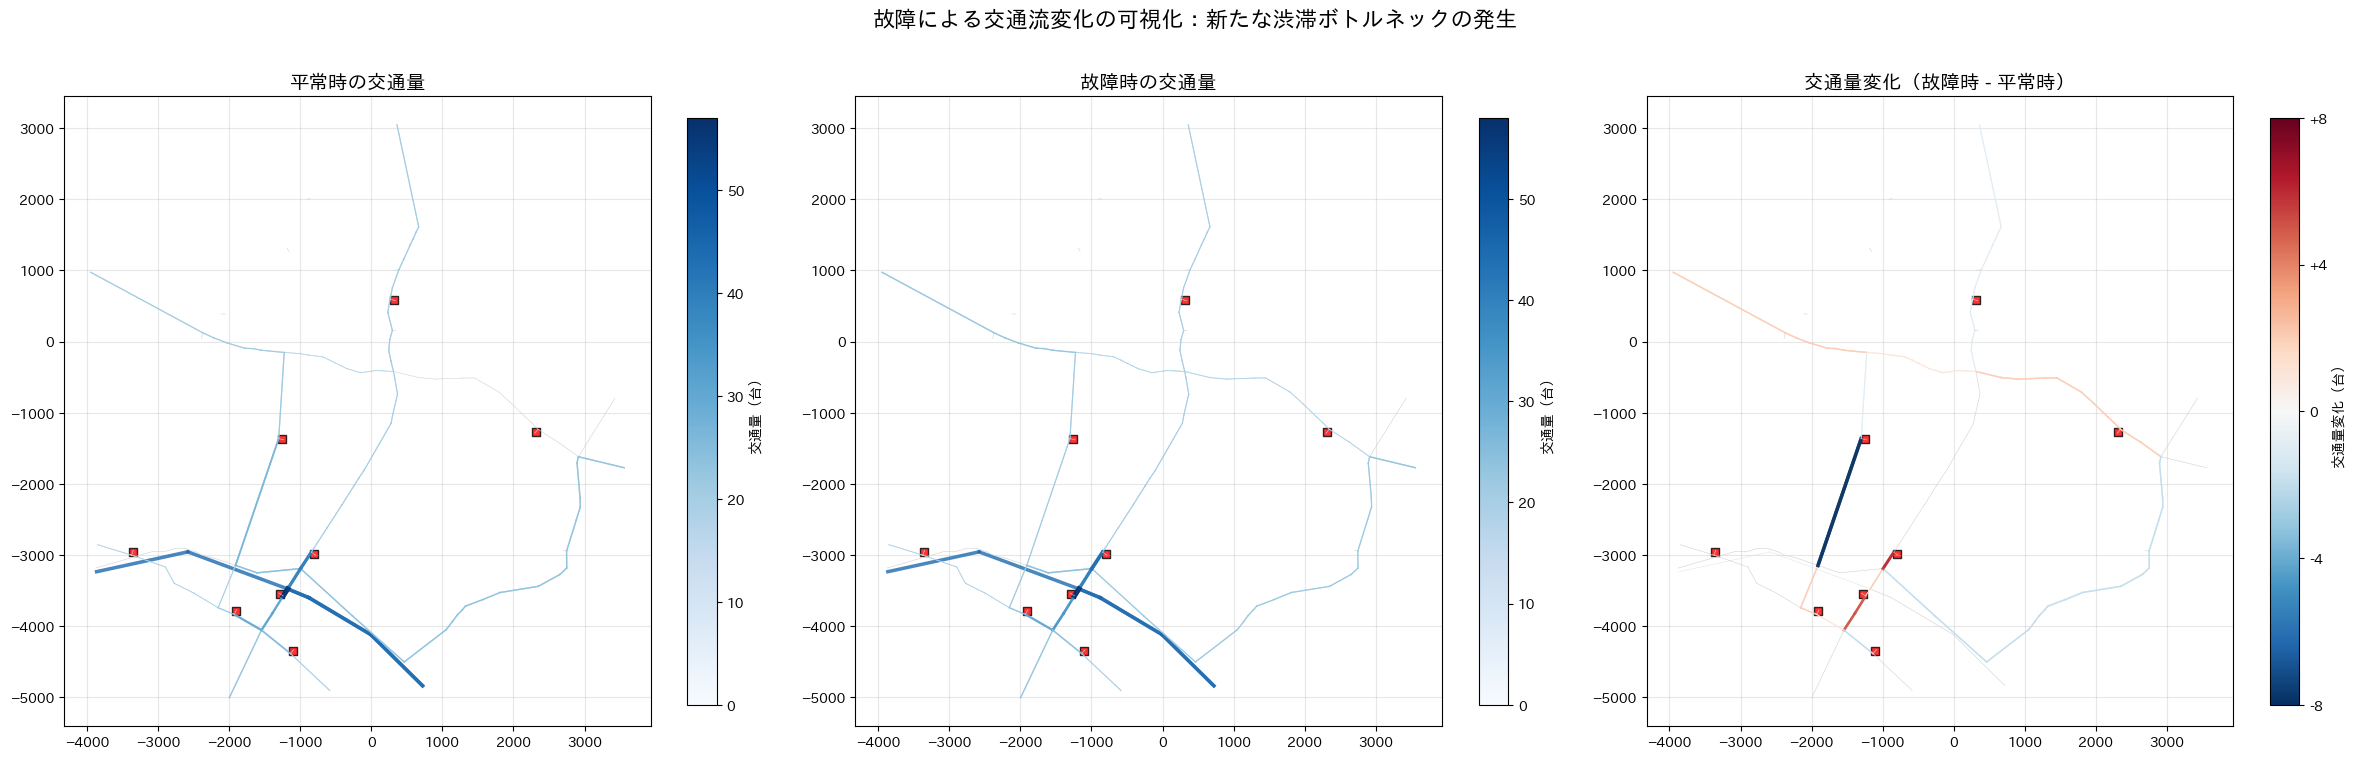


=== 新たな渋滞ボトルネック（リンク） ===


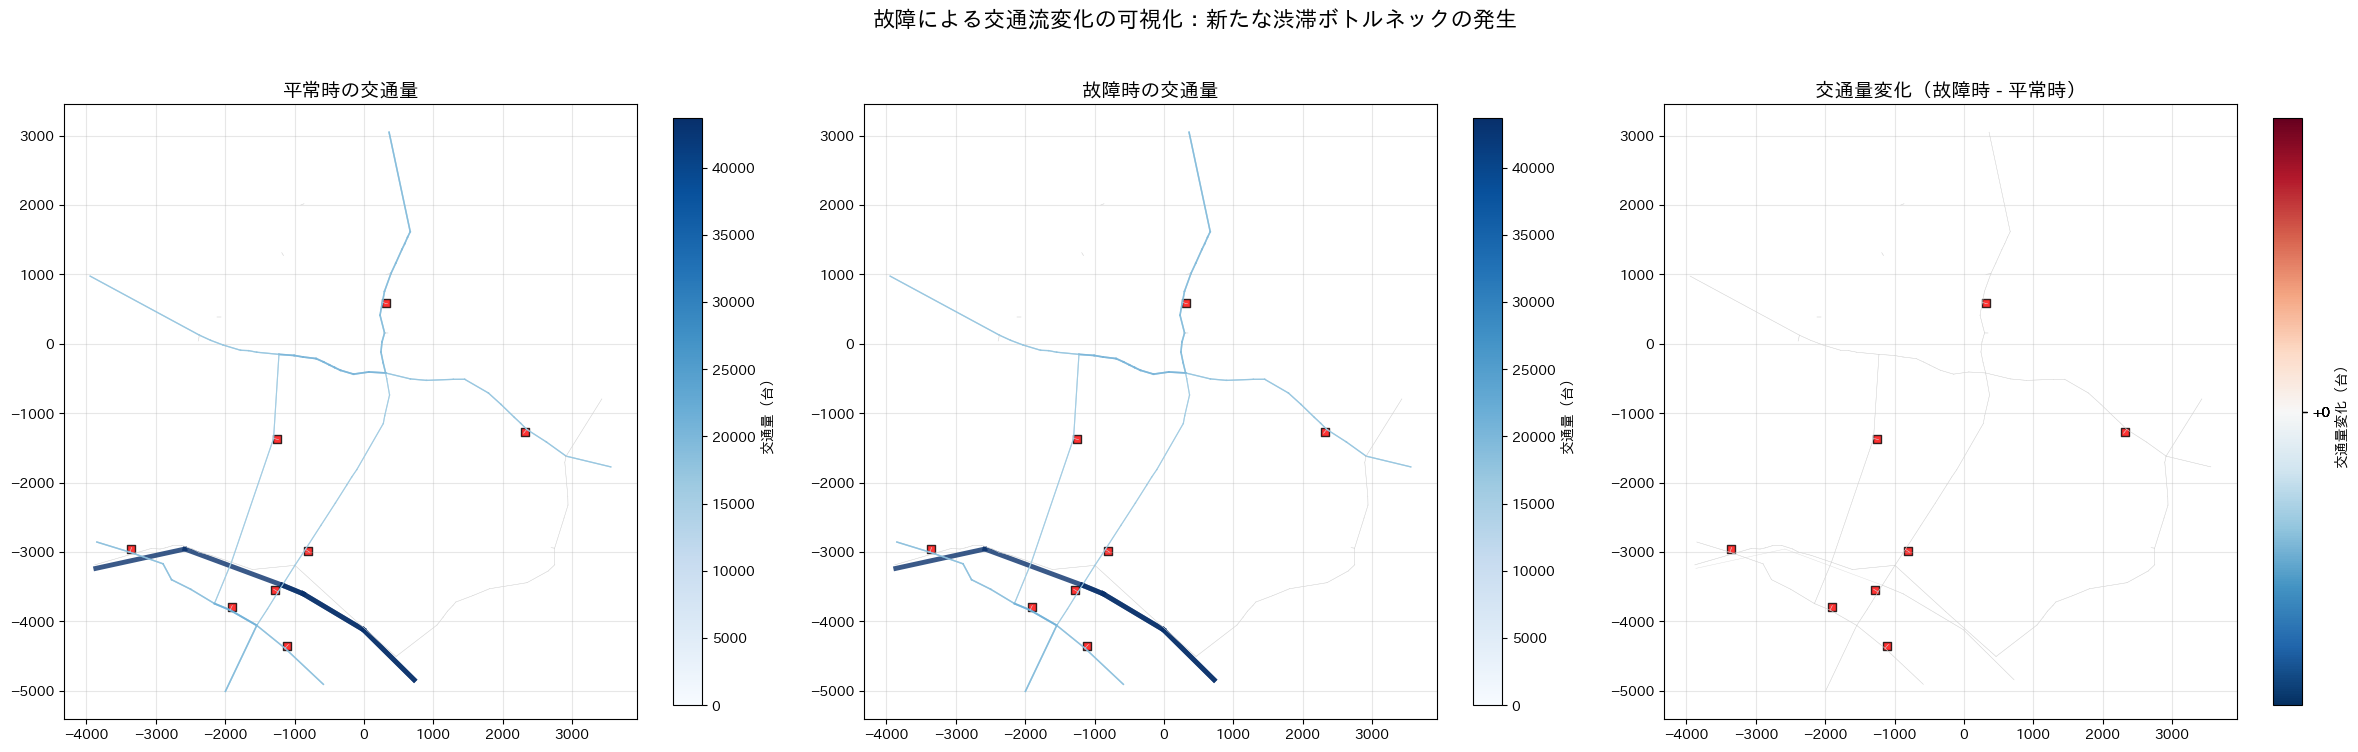


=== 新たな渋滞ボトルネック（リンク） ===


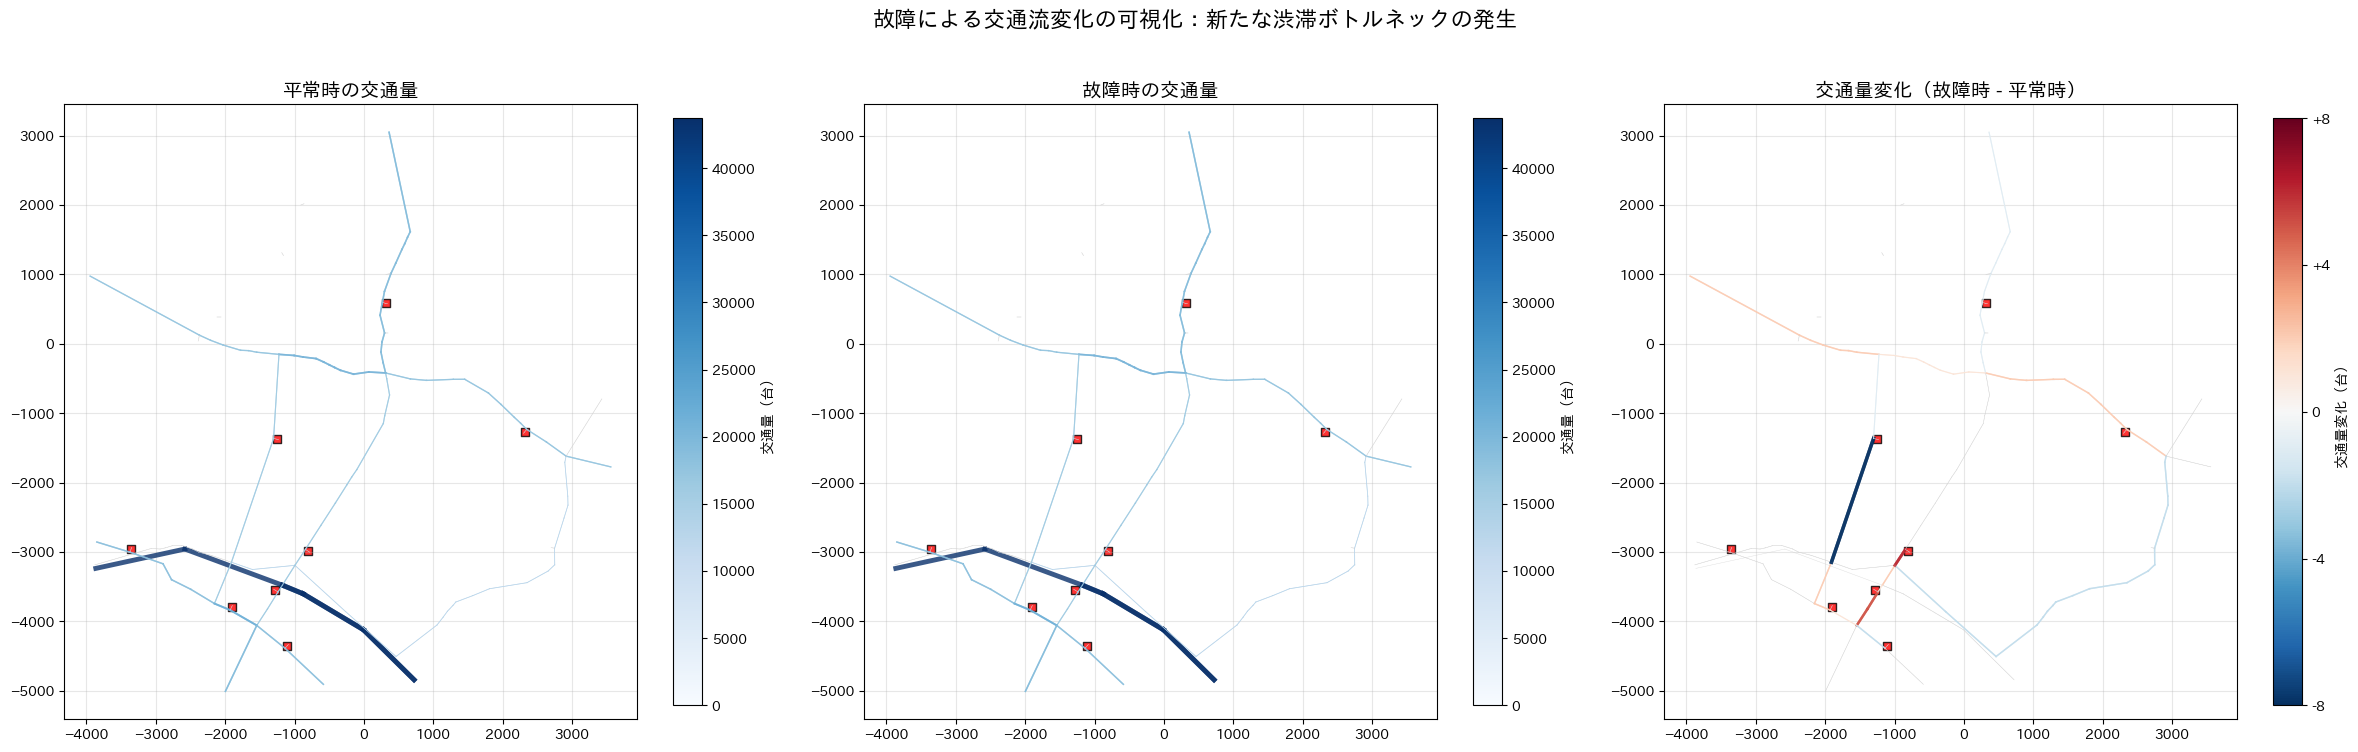


=== 新たな渋滞ボトルネック（リンク） ===


In [14]:
import networkx as nx
from collections import defaultdict

def create_traffic_change_heatmap(health_vehicles, failure_vehicles, 
                                  network_df, map_df):
    """
    平常時と故障時の交通量変化をヒートマップで可視化
    新たな渋滞ボトルネックの発生箇所を特定
    """
    
    # ネットワークグラフを作成
    G = nx.Graph()
    node_positions = {}
    for _, row in map_df.iterrows():
        G.add_node(row['ID'], pos=(row['X'], row['Y']))
        node_positions[row['ID']] = (row['X'], row['Y'])
    
    for _, row in network_df.iterrows():
        from_node = row['from']
        for to_col in ['to_1', 'to_2', 'to_3', 'to_4']:
            if pd.notna(row[to_col]) and row[to_col] != 0:
                to_node = row[to_col]
                G.add_edge(from_node, to_node)

    # 各ケースでのリンク通過回数を計算
    def calculate_link_usage(vehicle_data):
        link_usage = defaultdict(int)
        
        for _, trip in vehicle_data.iterrows():
            start_node = trip['startID']
            end_node = trip['goalID']
            
            try:
                if start_node in G.nodes and end_node in G.nodes:
                    path = nx.shortest_path(G, start_node, end_node)
                    # 経路上の各リンクをカウント
                    for i in range(len(path) - 1):
                        link = (min(path[i], path[i+1]), max(path[i], path[i+1]))
                        link_usage[link] += 1
            except nx.NetworkXNoPath:
                continue
        
        return dict(link_usage)
    
    health_usage = calculate_link_usage(health_vehicles)
    failure_usage = calculate_link_usage(failure_vehicles)
    
    # 交通量変化を計算
    traffic_change = {}
    new_bottlenecks = []
    
    all_links = set(health_usage.keys()) | set(failure_usage.keys())
    
    for link in all_links:
        health_count = health_usage.get(link, 0)
        failure_count = failure_usage.get(link, 0)
        change = failure_count - health_count
        
        traffic_change[link] = change
        
        # 新たなボトルネック（交通量が大幅増加したリンク）を特定
        if change > 20:  # 閾値は調整可能
            new_bottlenecks.append((link, change))
    
    # 可視化
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
    
    # 1. 平常時の交通量
    ax1.set_title('平常時の交通量', fontsize=14, fontweight='bold')
    
    # リンクを描画
    max_health = max(health_usage.values()) if health_usage else 1
    for _, row in network_df.iterrows():
        from_node = row['from']
        from_pos = node_positions.get(from_node)
        if from_pos is None:
            continue
            
        for to_col in ['to_1', 'to_2', 'to_3', 'to_4']:
            if pd.notna(row[to_col]) and row[to_col] != 0:
                to_node = row[to_col]
                to_pos = node_positions.get(to_node)
                if to_pos is not None:
                    # リンクの交通量を取得
                    link = (min(from_node, to_node), max(from_node, to_node))
                    traffic = health_usage.get(link, 0)
                    
                    # 交通量に応じて色と太さを設定
                    if traffic > 0:
                        normalized_traffic = traffic / max_health
                        color = plt.cm.Blues(0.3 + 0.7 * normalized_traffic)
                        linewidth = 0.5 + 3 * normalized_traffic
                    else:
                        color = 'lightgray'
                        linewidth = 0.3
                    
                    ax1.plot([from_pos[0], to_pos[0]], 
                           [from_pos[1], to_pos[1]], 
                           color=color, linewidth=linewidth, alpha=0.8)
    
    # 充電ステーション候補地のみ表示
    csids = cslist_df['ID']
    charging_stations = map_df[map_df['ID'].isin(csids)]
    ax1.scatter(charging_stations['X'], charging_stations['Y'], 
               c='red', s=30, marker='s', alpha=0.8, edgecolors='black', linewidth=1)
    
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    
    # 平常時用カラーバー
    sm1 = plt.cm.ScalarMappable(cmap=plt.cm.Blues, 
                               norm=plt.Normalize(vmin=0, vmax=max_health))
    sm1.set_array([])
    cbar1 = plt.colorbar(sm1, ax=ax1, shrink=0.8)
    cbar1.set_label('交通量（台）', fontsize=10)
    
    # 2. 故障時の交通量
    ax2.set_title('故障時の交通量', fontsize=14, fontweight='bold')
    
    max_failure = max(failure_usage.values()) if failure_usage else 1
    for _, row in network_df.iterrows():
        from_node = row['from']
        from_pos = node_positions.get(from_node)
        if from_pos is None:
            continue
            
        for to_col in ['to_1', 'to_2', 'to_3', 'to_4']:
            if pd.notna(row[to_col]) and row[to_col] != 0:
                to_node = row[to_col]
                to_pos = node_positions.get(to_node)
                if to_pos is not None:
                    link = (min(from_node, to_node), max(from_node, to_node))
                    traffic = failure_usage.get(link, 0)
                    
                    if traffic > 0:
                        normalized_traffic = traffic / max_failure
                        color = plt.cm.Blues(0.3 + 0.7 * normalized_traffic)
                        linewidth = 0.5 + 3 * normalized_traffic
                    else:
                        color = 'lightgray'
                        linewidth = 0.3
                    
                    ax2.plot([from_pos[0], to_pos[0]], 
                           [from_pos[1], to_pos[1]], 
                           color=color, linewidth=linewidth, alpha=0.8)
    
    ax2.scatter(charging_stations['X'], charging_stations['Y'], 
               c='red', s=30, marker='s', alpha=0.8, edgecolors='black', linewidth=1)
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)
    
    # 故障時用カラーバー
    sm2 = plt.cm.ScalarMappable(cmap=plt.cm.Blues, 
                               norm=plt.Normalize(vmin=0, vmax=max_failure))
    sm2.set_array([])
    cbar2 = plt.colorbar(sm2, ax=ax2, shrink=0.8)
    cbar2.set_label('交通量（台）', fontsize=10)
    
    # 3. 交通量変化（差分）
    ax3.set_title('交通量変化（故障時 - 平常時）', fontsize=14, fontweight='bold')
    
    if traffic_change:
        max_change = max(abs(change) for change in traffic_change.values())
        
        for _, row in network_df.iterrows():
            from_node = row['from']
            from_pos = node_positions.get(from_node)
            if from_pos is None:
                continue
                
            for to_col in ['to_1', 'to_2', 'to_3', 'to_4']:
                if pd.notna(row[to_col]) and row[to_col] != 0:
                    to_node = row[to_col]
                    to_pos = node_positions.get(to_node)
                    if to_pos is not None:
                        link = (min(from_node, to_node), max(from_node, to_node))
                        change = traffic_change.get(link, 0)
                        
                        if change != 0 and max_change > 0:
                            normalized_change = change / max_change
                            # 青（減少）から赤（増加）のカラーマップ
                            color = plt.cm.RdBu_r(0.5 + 0.5 * normalized_change)
                            linewidth = 0.5 + 2 * abs(normalized_change)
                        else:
                            color = 'lightgray'
                            linewidth = 0.3
                        
                        ax3.plot([from_pos[0], to_pos[0]], 
                               [from_pos[1], to_pos[1]], 
                               color=color, linewidth=linewidth, alpha=0.8)
        
        # 新たなボトルネックを強調表示
        for link, change in new_bottlenecks:
            node1, node2 = link
            pos1 = node_positions.get(node1)
            pos2 = node_positions.get(node2)
            if pos1 and pos2:
                # ボトルネックリンクを太い赤線で強調
                ax3.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]], 
                        color='red', linewidth=5, alpha=0.9)
                
                # 中点にテキストを表示
                mid_x = (pos1[0] + pos2[0]) / 2
                mid_y = (pos1[1] + pos2[1]) / 2
                ax3.annotate(f'+{change}台', 
                           xy=(mid_x, mid_y), xytext=(10, 10), 
                           textcoords='offset points',
                           bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.8),
                           fontsize=8, fontweight='bold')
        
        # 交通量変化用カラーバー
        sm3 = plt.cm.ScalarMappable(cmap=plt.cm.RdBu_r, 
                                   norm=plt.Normalize(vmin=-max_change, vmax=max_change))
        sm3.set_array([])
        cbar3 = plt.colorbar(sm3, ax=ax3, shrink=0.8)
        cbar3.set_label('交通量変化（台）', fontsize=10)
        # カラーバーのラベルを設定
        cbar3.set_ticks([-max_change, -max_change/2, 0, max_change/2, max_change])
        cbar3.set_ticklabels([f'-{max_change:.0f}', f'-{max_change/2:.0f}', 
                             '0', f'+{max_change/2:.0f}', f'+{max_change:.0f}'])
    
    ax3.scatter(charging_stations['X'], charging_stations['Y'], 
               c='red', s=30, marker='s', alpha=0.8, edgecolors='black', linewidth=1)
    ax3.set_aspect('equal')
    ax3.grid(True, alpha=0.3)
    
    plt.suptitle('故障による交通流変化の可視化：新たな渋滞ボトルネックの発生', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 新たなボトルネックの詳細レポート
    print("\n=== 新たな渋滞ボトルネック（リンク） ===")
    for link, change in sorted(new_bottlenecks, key=lambda x: x[1], reverse=True):
        node1, node2 = link
        pos1 = node_positions.get(node1, 'Unknown')
        pos2 = node_positions.get(node2, 'Unknown')
        print(f"Link {node1}-{node2}: +{change}台 (位置: {pos1} - {pos2})")
    
    return traffic_change, new_bottlenecks

# 実行
map_path = r'\\wsl.localhost\Ubuntu-22.04\home\tsato-cnlab\Emates\eMATES_2308\network\simple_shikata\mapPosition.txt'
map_df = pd.read_csv(map_path, sep=',', header=None, names=['ID', 'X', 'Y', 'Z'])

network_path = r'\\wsl.localhost\Ubuntu-22.04\home\tsato-cnlab\Emates\eMATES_2308\network\simple_shikata\network.txt'
network_df = pd.read_csv(network_path, sep=',', header=None, names=['from', 'link', 'to_1', 'to_2', 'to_3', 'to_4'])

cslist_path = r'\\wsl.localhost\Ubuntu-22.04\home\tsato-cnlab\Emates\eMATES_2308\network\simple_shikata\csList.txt'
cslist_df = pd.read_csv(cslist_path, sep=',', header=None, names=['ID', 'port', 'kw'])

traffic_change, new_bottlenecks = create_traffic_change_heatmap(
    charging_trips_robust_health, charging_trips_robust_failure, 
    network_df, map_df
)

_,_ = create_traffic_change_heatmap(non_charging_trips_robust_health, 
                                    non_charging_trips_robust_failure,
                                    network_df, map_df)

_,_ =create_traffic_change_heatmap(unified_data['Robust']['vehicle_trip'],
                                   unified_data['Robust_Failure']['vehicle_trip'],
                                   network_df,map_df)

##### 全ケースでの旅行時間の箱ひげ図

In [15]:
def analyze_individual_vehicle_performance(unified_data):
    """
    各EVIDごとの旅行時間・待ち時間を分析し、充電車両と非充電車両に分けて比較
    """
    
    cases = {
        'Normal': {'data': unified_data['Normal'], 'color': 'lightblue'},
        'Normal_Failure': {'data': unified_data['Normal_Failure'], 'color': 'salmon'}, 
        'Robust': {'data': unified_data['Robust'], 'color': 'lightgreen'},
        'Robust_Failure': {'data': unified_data['Robust_Failure'], 'color': 'orange'},
        '5loc': {'data': unified_data['5locations'], 'color': 'yellow'},
        '5loc_Failure': {'data': unified_data['5locations_Failure'], 'color': 'purple'},
        'Stochastic': {'data': unified_data['Stochastic'], 'color': 'lightblue'},
        'Stochastic_Failure': {'data': unified_data['Stochastic_Failure'], 'color': 'salmon'},
        'Stochastic30': {'data': unified_data['Stochastic30'], 'color': 'lightgreen'},
        'Stochastic30_Failure': {'data': unified_data['Stochastic30_Failure'], 'color': 'orange'}
    }
    
    # 各ケースのEVID別統計を計算
    all_stats = {}
    
    for case_name, case_info in cases.items():
        charging_trips = case_info['data']['charging_trips'].copy()
        non_charging_trips = case_info['data']['non_charging_trips'].copy()
        
        # 旅行時間と待ち時間を計算（分単位）
        charging_trips['trip_time'] = (charging_trips['EndTime'] - charging_trips['StartTime']) / 60
        charging_trips['waiting_time'] = (charging_trips['startChargingTime'] - charging_trips['WaitingEntryTime']) / 60
        non_charging_trips['trip_time'] = (non_charging_trips['EndTime'] - non_charging_trips['StartTime']) / 60
        
        # EVID別に集計
        charging_stats = charging_trips.groupby('EVID')['trip_time'].agg(['mean', 'std', 'count']).reset_index()
        charging_wait_stats = charging_trips.groupby('EVID')['waiting_time'].agg(['mean', 'std', 'count']).reset_index()
        non_charging_stats = non_charging_trips.groupby('EVID')['trip_time'].agg(['mean', 'std', 'count']).reset_index()
        
        all_stats[case_name] = {
            'charging_trip_times': charging_stats['mean'].dropna(),
            'charging_wait_times': charging_wait_stats['mean'].dropna(),
            'non_charging_trip_times': non_charging_stats['mean'].dropna(),
            'color': case_info['color'],
            'charging_count': len(charging_stats),
            'non_charging_count': len(non_charging_stats)
        }
        
        print(f"{case_name}: 充電車両{len(charging_stats)}台, 非充電車両{len(non_charging_stats)}台")
    
    return all_stats

def plot_unified_vehicle_boxplots(all_stats):
    """統一された縦軸で各ケースの旅行時間・待ち時間を同じグラフ上で比較"""
    
    # 統一縦軸範囲の計算
    all_trip_times = []
    all_wait_times = []
    
    for case_name, stats in all_stats.items():
        if len(stats['charging_trip_times']) > 0:
            all_trip_times.extend(stats['charging_trip_times'])
        if len(stats['non_charging_trip_times']) > 0:
            all_trip_times.extend(stats['non_charging_trip_times'])
        if len(stats['charging_wait_times']) > 0:
            all_wait_times.extend(stats['charging_wait_times'])
    
    trip_time_ylim = (0, max(all_trip_times) * 1.1) if all_trip_times else (0, 100)
    wait_time_ylim = (0, max(all_wait_times) * 1.1) if all_wait_times else (0, 50)
    
    print(f"旅行時間統一範囲: {trip_time_ylim[0]:.1f} - {trip_time_ylim[1]:.1f} 分")
    print(f"待ち時間統一範囲: {wait_time_ylim[0]:.1f} - {wait_time_ylim[1]:.1f} 分")
    
    # 1. 旅行時間比較（充電車両 vs 非充電車両）
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # 1-1. 充電車両の旅行時間比較
    charging_data_to_plot = []
    charging_labels = []
    charging_colors = []
    
    for case_name, stats in all_stats.items():
        if len(stats['charging_trip_times']) > 0:
            charging_data_to_plot.append(stats['charging_trip_times'])
            charging_labels.append(f"{case_name}\n({len(stats['charging_trip_times'])}台)")
            charging_colors.append(stats['color'])
    
    if charging_data_to_plot:
        bp1 = ax1.boxplot(charging_data_to_plot, labels=charging_labels, patch_artist=True)
        for patch, color in zip(bp1['boxes'], charging_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        for median in bp1['medians']:
            median.set_color('red')
            median.set_linewidth(2)
    
    ax1.set_title('充電車両の旅行時間分布', fontsize=14, fontweight='bold')
    ax1.set_ylabel('旅行時間 (分)', fontsize=12)
    ax1.set_ylim(trip_time_ylim)
    ax1.grid(axis='y', alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # 1-2. 非充電車両の旅行時間比較
    non_charging_data_to_plot = []
    non_charging_labels = []
    non_charging_colors = []
    
    for case_name, stats in all_stats.items():
        if len(stats['non_charging_trip_times']) > 0:
            non_charging_data_to_plot.append(stats['non_charging_trip_times'])
            non_charging_labels.append(f"{case_name}\n({len(stats['non_charging_trip_times'])}台)")
            non_charging_colors.append(stats['color'])
    
    if non_charging_data_to_plot:
        bp2 = ax2.boxplot(non_charging_data_to_plot, labels=non_charging_labels, patch_artist=True)
        for patch, color in zip(bp2['boxes'], non_charging_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        for median in bp2['medians']:
            median.set_color('red')
            median.set_linewidth(2)
    
    ax2.set_title('非充電車両の旅行時間分布', fontsize=14, fontweight='bold')
    ax2.set_ylabel('旅行時間 (分)', fontsize=12)
    ax2.set_ylim(trip_time_ylim)
    ax2.grid(axis='y', alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    plt.suptitle('車両別旅行時間の比較（統一軸）', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 2. 充電車両の待ち時間比較
    plt.figure(figsize=(12, 6))
    
    wait_data_to_plot = []
    wait_labels = []
    wait_colors = []
    
    for case_name, stats in all_stats.items():
        if len(stats['charging_wait_times']) > 0:
            wait_data_to_plot.append(stats['charging_wait_times'])
            wait_labels.append(f"{case_name}\n({len(stats['charging_wait_times'])}台)")
            wait_colors.append(stats['color'])
    
    if wait_data_to_plot:
        bp3 = plt.boxplot(wait_data_to_plot, labels=wait_labels, patch_artist=True)
        for patch, color in zip(bp3['boxes'], wait_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        for median in bp3['medians']:
            median.set_color('red')
            median.set_linewidth(2)
    
    plt.title('充電車両の待ち時間分布比較（統一軸）', fontsize=16, fontweight='bold')
    plt.ylabel('待ち時間 (分)', fontsize=12)
    plt.ylim(wait_time_ylim)
    plt.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_combined_comparison(all_stats):
    """旅行時間と待ち時間を統合した比較表示"""
    
    # データの準備
    case_names = list(all_stats.keys())
    metrics_data = {
        'charging_trip': [],
        'non_charging_trip': [],
        'waiting': []
    }
    colors = [all_stats[case]['color'] for case in case_names]
    
    for case_name in case_names:
        stats = all_stats[case_name]
        metrics_data['charging_trip'].append(stats['charging_trip_times'])
        metrics_data['non_charging_trip'].append(stats['non_charging_trip_times'])
        metrics_data['waiting'].append(stats['charging_wait_times'])
    
    # 統一軸範囲の計算
    all_values = []
    for metric_data in metrics_data.values():
        for data in metric_data:
            if len(data) > 0:
                all_values.extend(data)
    
    unified_ylim = (0, max(all_values) * 1.1) if all_values else (0, 100)
    
    # 3つのメトリクスを並べて表示
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    metric_titles = ['充電車両 旅行時間', '非充電車両 旅行時間', '充電車両 待ち時間']
    
    for i, (metric_key, title) in enumerate(zip(metrics_data.keys(), metric_titles)):
        ax = axes[i]
        metric_data = metrics_data[metric_key]
        
        # データが存在するケースのみプロット
        plot_data = []
        plot_labels = []
        plot_colors = []
        
        for j, (case_name, data) in enumerate(zip(case_names, metric_data)):
            if len(data) > 0:
                plot_data.append(data)
                plot_labels.append(f"{case_name}\n({len(data)}台)")
                plot_colors.append(colors[j])
        
        if plot_data:
            bp = ax.boxplot(plot_data, labels=plot_labels, patch_artist=True)
            for patch, color in zip(bp['boxes'], plot_colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            for median in bp['medians']:
                median.set_color('red')
                median.set_linewidth(2)
        else:
            ax.text(0.5, 0.5, 'データなし', transform=ax.transAxes, 
                   ha='center', va='center', fontsize=14)
        
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_ylabel('時間 (分)', fontsize=12)
        ax.set_ylim(unified_ylim)
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    plt.suptitle('車両別性能指標の統合比較（統一軸）', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def calculate_summary_statistics(all_stats):
    """統計値の計算とまとめ"""
    
    summary_data = []
    
    for case_name, stats in all_stats.items():
        # 充電車両の旅行時間統計
        if len(stats['charging_trip_times']) > 0:
            data = stats['charging_trip_times']
            summary_data.append({
                'ケース': case_name,
                '車両タイプ': '充電車両',
                '指標': '旅行時間',
                '合計': data.sum(),
                '平均値': data.mean(),
                '標準偏差': data.std(),
                '95パーセンタイル': np.percentile(data, 95),
                'CV値': data.std() / data.mean() if data.mean() > 0 else 0,
                '車両数': len(data)
            })
        
        # 充電車両の待ち時間統計
        if len(stats['charging_wait_times']) > 0:
            data = stats['charging_wait_times']
            summary_data.append({
                'ケース': case_name,
                '車両タイプ': '充電車両',
                '指標': '待ち時間',
                '合計': data.sum(),
                '平均値': data.mean(),
                '標準偏差': data.std(),
                '95パーセンタイル': np.percentile(data, 95),
                'CV値': data.std() / data.mean() if data.mean() > 0 else 0,
                '車両数': len(data)
            })
        
        # 非充電車両の旅行時間統計
        if len(stats['non_charging_trip_times']) > 0:
            data = stats['non_charging_trip_times']
            summary_data.append({
                'ケース': case_name,
                '車両タイプ': '非充電車両',
                '指標': '旅行時間',
                '合計': data.sum(),
                '平均値': data.mean(),
                '標準偏差': data.std(),
                '95パーセンタイル': np.percentile(data, 95),
                'CV値': data.std() / data.mean() if data.mean() > 0 else 0,
                '車両数': len(data)
            })
    
    return pd.DataFrame(summary_data)

# 分析実行
print("車両別性能分析を開始...")
vehicle_stats = analyze_individual_vehicle_performance(unified_data)

# 統一軸での箱ひげ図描画
plot_unified_vehicle_boxplots(vehicle_stats)

# 統合比較表示
# plot_combined_comparison(vehicle_stats)

# 統計サマリーの計算と表示
summary_df = calculate_summary_statistics(vehicle_stats)

print("\n" + "="*100)
print("【統計サマリー】")
print("="*100)
print(summary_df.round(3).to_string(index=False))

# ピボットテーブル形式での表示
print("\n" + "="*80)
print("【旅行時間統計（ピボットテーブル）】")
print("="*80)
trip_stats = summary_df[summary_df['指標'] == '旅行時間']
if not trip_stats.empty:
    trip_pivot = trip_stats.pivot_table(
        index=['ケース', '車両タイプ'], 
        values=['平均値', '標準偏差', '95パーセンタイル', 'CV値'],
        aggfunc='first'
    ).round(2)
    print(trip_pivot)

print("\n" + "="*80)
print("【待ち時間統計（ピボットテーブル）】")
print("="*80)
wait_stats = summary_df[summary_df['指標'] == '待ち時間']
if not wait_stats.empty:
    wait_pivot = wait_stats.pivot_table(
        index='ケース', 
        values=['平均値', '標準偏差', '95パーセンタイル', 'CV値'],
        aggfunc='first'
    ).round(2)
    print(wait_pivot)
else:
    print("待ち時間データが見つかりません")

# CSVとして保存
timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M")
summary_df_round = round(summary_df, 3)
summary_df_round.to_csv(f'vehicle_performance_stats.csv', index=False, encoding='utf-8-sig')
print(f"\n統計結果をCSVに保存: vehicle_performance_stats_{timestamp}.csv")

車両別性能分析を開始...


KeyError: 'Stochastic30'

#### 1:最適化推移の確認

In [29]:
plot_optimization_history(STUDY_NAME=study_stochastic_5, db_path=f"{robust_save_dir}/{failure_db}")
plot_optimization_history(STUDY_NAME=failure_study_name, db_path=f"{robust_save_dir}/{failure_db}")

StorageInternalError: An exception is raised during the commit. This typically happens due to invalid data in the commit, e.g. exceeding max length. 

#### 2:各指標の確認

##### 2.0：最適化配置

In [ ]:
plt.figure(figsize=(10, 8))
plot_network_structure(result_path=f'{result_file_normal}', title='充電ステーション(通常最適化配置)')
plt.figure(figsize=(10, 8))
plot_network_structure(result_path=f'{result_file_robust_health}', title='充電ステーション(ロバスト最適配置)')

In [ ]:
def plot_network_structure_comparison(normal_result_path: Path = None, robust_result_path: Path = None, 
                                    title='充電ステーション配置比較', 
                                    show_traffic_highlight=False, traffic_df=None):
    """
    通常最適化とロバスト最適化の充電ステーション配置を比較表示
    
    Parameters:
    - normal_result_path: 通常最適化結果のpklファイルパス
    - robust_result_path: ロバスト最適化結果のpklファイルパス
    - title: グラフのタイトル
    - show_traffic_highlight: 交通量ハイライト表示の有無
    - traffic_df: 交通量データ
    """
    # データの読み込み
    map_path = r'\\wsl.localhost\Ubuntu-22.04\home\tsato-cnlab\Emates\eMATES_2308\network\simple_shikata\mapPosition.txt'
    map_df = pd.read_csv(map_path, sep=',', header=None, names=['ID', 'X', 'Y', 'Z'])

    network_path = r'\\wsl.localhost\Ubuntu-22.04\home\tsato-cnlab\Emates\eMATES_2308\network\simple_shikata\network.txt'
    network_df = pd.read_csv(network_path, sep=',', header=None, names=['from', 'link', 'to_1', 'to_2', 'to_3', 'to_4'])
    
    cslist_path = r'\\wsl.localhost\Ubuntu-22.04\home\tsato-cnlab\Emates\eMATES_2308\network\simple_shikata\csList.txt'
    cslist_df = pd.read_csv(cslist_path, sep=',', header=None, names=['ID', 'port', 'kw'])
    
    # 交通量ハイライト用のリンク色計算（既存コードと同じ）
    link_colors = {}
    link_widths = {}
    
    if show_traffic_highlight and traffic_df is not None:
        traffic_df_copy = traffic_df.copy()
        traffic_df_copy['time_hour'] = traffic_df_copy['startTime'] // (3600*1000)
        traffic_df_copy = traffic_df_copy[traffic_df_copy['time_hour'] < 24]
        
        daily_traffic = traffic_df_copy.groupby(['from', 'to'])['volume'].sum().reset_index()
        
        if len(daily_traffic) > 0:
            max_traffic = daily_traffic['volume'].max()
            min_traffic = daily_traffic['volume'].min()
            
            for _, row in daily_traffic.iterrows():
                from_node, to_node = row['from'], row['to']
                volume = row['volume']
                
                if max_traffic > min_traffic:
                    normalized_volume = (volume - min_traffic) / (max_traffic - min_traffic)
                else:
                    normalized_volume = 0.5
                
                color_intensity = 0.3 + 0.7 * normalized_volume
                link_colors[(from_node, to_node)] = plt.cm.Blues(color_intensity)
                link_colors[(to_node, from_node)] = plt.cm.Blues(color_intensity)
                
                link_widths[(from_node, to_node)] = 0.5 + 1.5 * normalized_volume
                link_widths[(to_node, from_node)] = 0.5 + 1.5 * normalized_volume
    
    # ベースネットワークの描画
    plt.scatter(map_df['X'], map_df['Y'], c='lightblue', s=10, alpha=0.5, label='Node')

    # リンクの描画
    for _, row in network_df.iterrows():
        from_node = map_df[map_df['ID'] == row['from']]
        
        for to_col in ['to_1', 'to_2', 'to_3', 'to_4']:
            if pd.notna(row[to_col]) and row[to_col] != 0:
                to_node = map_df[map_df['ID'] == row[to_col]]
                
                if not from_node.empty and not to_node.empty:
                    from_id = row['from']
                    to_id = row[to_col]
                    
                    if show_traffic_highlight and (from_id, to_id) in link_colors:
                        color = link_colors[(from_id, to_id)]
                        linewidth = link_widths[(from_id, to_id)]
                        alpha = 0.8
                    else:
                        color = 'gray'
                        linewidth = 0.3
                        alpha = 0.3
                    
                    plt.plot([from_node['X'].iloc[0], to_node['X'].iloc[0]], 
                            [from_node['Y'].iloc[0], to_node['Y'].iloc[0]], 
                            color=color, alpha=alpha, linewidth=linewidth)

    # 充電ステーション候補地を表示
    csids = cslist_df['ID']
    charging_stations = map_df[map_df['ID'].isin(csids)]
    plt.scatter(charging_stations['X'], charging_stations['Y'], c='black', 
               s=50, alpha=0.5, label='FCS Candidates', marker='o')
    
    # 充電ステーション配置データの読み込みと処理
    normal_cs_data = None
    robust_cs_data = None
    
    if normal_result_path:
        with open(normal_result_path, 'rb') as f:
            data = pickle.load(f)
        normal_cs_config = data['cs_config']
        normal_cs_df = pd.DataFrame({
            'csids': normal_cs_config['csids'],
            'ports': normal_cs_config['ports'],
            'cap_kw': normal_cs_config['cap_kw']
        })
        normal_cs_data = normal_cs_df[normal_cs_df['ports'] > 0]
    
    if robust_result_path:
        with open(robust_result_path, 'rb') as f:
            data = pickle.load(f)
        robust_cs_config = data['cs_config']
        robust_cs_df = pd.DataFrame({
            'csids': robust_cs_config['csids'],
            'ports': robust_cs_config['ports'],
            'cap_kw': robust_cs_config['cap_kw']
        })
        robust_cs_data = robust_cs_df[robust_cs_df['ports'] > 0]
    
    # 共通の色・サイズマッピング用の値範囲を計算
    all_ports = []
    all_cap_kw = []
    
    if normal_cs_data is not None:
        all_ports.extend(normal_cs_data['ports'].tolist())
        all_cap_kw.extend(normal_cs_data['cap_kw'].tolist())
    if robust_cs_data is not None:
        all_ports.extend(robust_cs_data['ports'].tolist())
        all_cap_kw.extend(robust_cs_data['cap_kw'].tolist())
    
    if all_ports and all_cap_kw:
        min_ports, max_ports = min(all_ports), max(all_ports)
        min_cap_kw, max_cap_kw = min(all_cap_kw), max(all_cap_kw)
        
        # サイズとアルファ値の正規化関数
        def normalize_size(ports):
            if max_ports == min_ports:
                return 200
            return 100 + 300 * (ports - min_ports) / (max_ports - min_ports)
        
        def normalize_alpha(cap_kw):
            if max_cap_kw == min_cap_kw:
                return 0.8
            return 0.4 + 0.6 * (cap_kw - min_cap_kw) / (max_cap_kw - min_cap_kw)
    
    # 設置位置の重複チェック用
    installed_positions = set()
    offset = 100  # 重複時のオフセット距離
    
    # ラベル重複を防ぐためのフラグ
    normal_label_added = False
    robust_label_added = False
    
    # 通常最適化の充電ステーション描画（青色の四角形）
    if normal_cs_data is not None:
        normal_cs_with_pos = pd.merge(normal_cs_data, map_df, 
                                    left_on='csids', right_on='ID', how='inner')
        
        for _, row in normal_cs_with_pos.iterrows():
            x, y = row['X'], row['Y']
            pos_key = (x, y)
            
            # 重複チェック（同じ位置に既に設置されている場合）
            if pos_key in installed_positions:
                x -= offset  # 左にオフセット

            size = min(normalize_size(row['ports']), 100)
            alpha = normalize_alpha(row['cap_kw'])
            
            # 最初の要素のみにラベルを付ける
            label = 'Conventional' if not normal_label_added else ""
            
            plt.scatter(x, y, c='blue', s=size, alpha=alpha,
                       marker='s', edgecolors='darkblue', linewidths=2,
                       label=label)
            
            normal_label_added = True
            installed_positions.add(pos_key)
    
    # ロバスト最適化の充電ステーション描画（赤色のひし形）
    if robust_cs_data is not None:
        robust_cs_with_pos = pd.merge(robust_cs_data, map_df, 
                                    left_on='csids', right_on='ID', how='inner')

        for i, (_, row) in enumerate(robust_cs_with_pos.iterrows()):
            x, y = row['X'], row['Y']
            pos_key = (x, y)
            
            # 重複チェック（同じ位置に既に設置されている場合）
            if pos_key in installed_positions:
                x += offset  # 右にオフセット
                y += offset  # 上にオフセット

            size = min(normalize_size(row['ports']), 100)
            alpha = normalize_alpha(row['cap_kw'])
            
            # 最初の要素のみにラベルを付ける
            label = 'Robust' if not robust_label_added else ""
            
            plt.scatter(x, y, c='red', s=size, alpha=alpha,
                       marker='D', edgecolors='darkred', linewidths=2,
                       label=label)
            
            robust_label_added = True
            installed_positions.add(pos_key)
            # csid = (robust_cs_with_pos['csids'].iloc[i] % 900000) / 2
            # plt.annotate(csid, xy=(x, y), xytext=(x + 10, y + 10))

    # 交通量ハイライト用のカラーバー追加
    if show_traffic_highlight and traffic_df is not None and len(daily_traffic) > 0:
        sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, 
                                  norm=plt.Normalize(vmin=min_traffic, vmax=max_traffic))
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.6)
        cbar.set_label('Daily Traffic Volume', fontsize=10)
    
    # 凡例の表示
    plt.legend(loc='upper left', fontsize=10, 
                framealpha=0.9, title='Deployment Type')


    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('X', fontsize=12)
    plt.ylabel('Y', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

    print(f'通常最適化充電ステーション配置: {normal_cs_data}')
    print(f'ロバスト最適化充電ステーション配置: {robust_cs_data}')

# 使用例
plot_network_structure_comparison(
    normal_result_path=result_file_normal,
    robust_result_path=result_file_robust,
    title='Comparison of Charging Station Deployments',)

##### CSごとの累積充電量

In [ ]:
def plot_kwh_timeseries_unified(result_files, case_names, max_cumulative_kwh=None):
    """
    複数の結果ファイルの累積充電量を統一された縦軸で比較表示
    
    Parameters:
    - result_files: 結果ファイルのパスのリスト
    - case_names: 各ケースの名前のリスト  
    - max_cumulative_kwh: 縦軸の最大値（Noneの場合は自動計算）
    """
    
    # 1. 全データから最大累積充電量を計算（縦軸統一用）
    all_max_values = []
    all_data = []
    
    for result_file in result_files:
        with open(result_file, 'rb') as f:
            data = pickle.load(f)
        
        timeseries_kw = data['time_series_kw']
        cs_config = data['cs_config']
        timeseries_kw.index = pd.to_datetime(timeseries_kw.index, unit='s')
        
        # Nanの列を削除
        timeseries_kw = timeseries_kw.dropna(axis=1, how='all')
        
        # cs_configをDataFrameに変換
        cs_df = pd.DataFrame({
            'csids': cs_config['csids'],
            'ports': cs_config['ports'],
            'cap_kw': cs_config['cap_kw']
        })
        
        # ポート数が0より大きい充電ステーションのみ抽出
        valid_cs = cs_df[(cs_df['ports'] > 0)]
        
        # 累積和を計算（kWh単位）
        cumulative_kwh = timeseries_kw.cumsum() / 60
        
        # 最大値を記録
        if len(cumulative_kwh.columns) > 0:
            max_val = cumulative_kwh.max().max()
            all_max_values.append(max_val)
        
        all_data.append({
            'cumulative_kwh': cumulative_kwh,
            'valid_cs': valid_cs,
            'timeseries_kw': timeseries_kw
        })
    
    # 統一する縦軸の最大値を決定
    if max_cumulative_kwh is None:
        max_cumulative_kwh = max(all_max_values) if all_max_values else 100
    
    print(f"統一縦軸の最大累積充電量: {max_cumulative_kwh:.1f} kWh")
    
    # 2. 各ケースをプロット
    for i, (result_file, case_name, data_dict) in enumerate(zip(result_files, case_names, all_data)):
        cumulative_kwh = data_dict['cumulative_kwh']
        valid_cs = data_dict['valid_cs']
        
        plt.figure(figsize=(12, 6))
        
        # 各充電ステーションの累積充電量をプロット
        for col, port, cap in zip(cumulative_kwh.columns, valid_cs['ports'], valid_cs['cap_kw']):
            plt.plot(cumulative_kwh[col], 
                    label=f'ID{int(col)%900000}_Port{port}_{cap}kW', 
                    linewidth=2)
        
        plt.title(f'累積充電量 ({case_name})', fontsize=14)
        plt.xlabel('時刻', fontsize=12)
        plt.ylabel('累積充電量 (kWh)', fontsize=12)
        plt.ylim(0, max_cumulative_kwh * 1.05)  # 少し余裕をもたせる
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # 統計情報を表示
        if len(cumulative_kwh.columns) > 0:
            total_final = cumulative_kwh.iloc[-1].sum()
            max_single = cumulative_kwh.iloc[-1].max()
            min_single = cumulative_kwh.iloc[-1].min()
            print(f"{case_name}: 総充電量={total_final:.1f}kWh, "
                  f"最大CS={max_single:.1f}kWh, 最小CS={min_single:.1f}kWh")
        else:
            print(f"{case_name}: 充電ステーションが設置されていません")
        print()

# 3. サブプロット版：4つのケースを1つの図にまとめて表示
def plot_kwh_timeseries_subplots(result_files, case_names):
    """
    4つのケースを2x2のサブプロットで統一軸表示
    """
    
    # 全データの最大累積充電量を計算
    all_max_values = []
    overall_max_total_kwh = []
    all_data = []
    
    for result_file in result_files:
        with open(result_file, 'rb') as f:
            data = pickle.load(f)
        
        timeseries_kw = data['time_series_kw']
        cs_config = data['cs_config']
        timeseries_kw.index = pd.to_datetime(timeseries_kw.index, unit='s')
        timeseries_kw = timeseries_kw.dropna(axis=1, how='all')
        
        cs_df = pd.DataFrame({
            'csids': cs_config['csids'],
            'ports': cs_config['ports'],
            'cap_kw': cs_config['cap_kw']
        })
        
        valid_cs = cs_df[(cs_df['ports'] > 0)]
        cumulative_kwh = timeseries_kw.cumsum() / 60
        total_cumulative_kwh = cumulative_kwh.sum(axis=1)
        print(cumulative_kwh.shape)
        print(f"総充電量: {total_cumulative_kwh.shape} kWh")
        total_kwh = timeseries_kw.sum().sum() / 60  # 総充電量を計算
        
        max_val_cs = cumulative_kwh.max().max()

        all_max_values.append(max_val_cs)
        overall_max_total_kwh.append(total_kwh)

        all_data.append({
            'cumulative_kwh': cumulative_kwh,
            'total_cumulative_kwh': total_cumulative_kwh,
            'valid_cs': valid_cs
            })
    
    max_cumulative_kwh = max(all_max_values)
    max_total_kwh = max(overall_max_total_kwh)
    print(f"統一縦軸の最大総充電量: {max_total_kwh:.1f} kWh")

    # 2x2のサブプロット作成
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    for i, (case_name, data_dict) in enumerate(zip(case_names, all_data)):
        ax = axes[i]
        cumulative_kwh = data_dict['cumulative_kwh']
        valid_cs = data_dict['valid_cs']
        total_cumulative_kwh = data_dict['total_cumulative_kwh']
        # 各充電ステーションの累積充電量をプロット(全体の累積充電量も同時に表示)
        for col, port, cap in zip(cumulative_kwh.columns, valid_cs['ports'], valid_cs['cap_kw']):
            ax.plot(cumulative_kwh[col], 
                   label=f'ID{int(col)%900000}_P{port}_{cap}kW', 
                   linewidth=2)

        # 全体の累積充電量をプロット
        ax.plot(total_cumulative_kwh, label='全体', linewidth=2, color='black', linestyle='--')

        ax.set_title(f'累積充電量 ({case_name})', fontsize=12)
        ax.set_xlabel('時刻', fontsize=10)
        ax.set_ylabel('累積充電量 (kWh)', fontsize=10)
        ax.set_ylim(0, max_total_kwh * 1.05)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        
        # X軸の時刻ラベルを調整
        # ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        # ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
        ax.tick_params(axis='x', rotation=45)
    
    plt.suptitle('累積充電量の比較（統一軸）', fontsize=16)
    plt.tight_layout()
    plt.show()


# 使用例
result_files = [result_file_normal, result_file_normal_failure, result_file_robust_health, result_file_robust]
case_names = ['通常(健常時)', '通常(故障時)', 'ロバスト(健常時)', 'ロバスト(故障時)']
# サブプロット版（統一軸）
plot_kwh_timeseries_subplots(result_files, case_names)
# # 個別表示版（統一軸）
# # plot_kwh_timeseries_unified(result_files, case_names)

##### CSごとの利用率

In [ ]:
def get_utilization_rates(result_file_normal):
    with open(result_file_normal, 'rb') as f:
        data = pickle.load(f)
        timeseries_kw = data['time_series_kw']
        cs_config = data['cs_config']
        total_kw = np.array(cs_config['cap_kw']) * np.array(cs_config['ports'])
        
        max_kwh_eachCS = total_kw * timeseries_kw.shape[0] / 60
        actual_kwh_eachCS = timeseries_kw.sum() / 60
        util_eachCS = actual_kwh_eachCS / max_kwh_eachCS
        util_eachCS = util_eachCS.dropna()

        # Print utilization rates for each charging station
        for i, (cs_id, utilization) in enumerate(zip(cs_config['csids'], util_eachCS)):
            print(f"CS {int(cs_id)%900000}: {utilization:.2%}")
    return util_eachCS

util_normal = get_utilization_rates(result_file_normal)
util_normal_failure = get_utilization_rates(result_file_normal_failure)
util_robust = get_utilization_rates(result_file_robust)
util_robust_failure = get_utilization_rates(result_file_robust_failure)

# 縦軸を合わせる
max_util = max(util_normal.max(), util_normal_failure.max(), util_robust.max(), util_robust_failure.max())
plt.figure(figsize=(15, 12))
plt.subplot(2, 2, 1)
plt.bar(util_normal.index, util_normal.values, color='skyblue')
plt.title('通常(健常時)の充電ステーション利用率')
plt.ylim(0, max_util * 1.05)
plt.subplot(2, 2, 2)
plt.bar(util_normal_failure.index, util_normal_failure.values, color='salmon')
plt.title('通常(異常時)の充電ステーション利用率')
plt.ylim(0, max_util * 1.05)
plt.subplot(2, 2, 3)
plt.bar(util_robust.index, util_robust.values, color='lightgreen')
plt.title('ロバスト(健常時)の充電ステーション利用率')
plt.ylim(0, max_util * 1.05)
plt.subplot(2, 2, 4)
plt.bar(util_robust_failure.index, util_robust_failure.values, color='orange')
plt.title('ロバスト(異常時)の充電ステーション利用率')
plt.ylim(0, max_util * 1.05)

# 平均利用率の表示
print(f"通常(健常時)の平均利用率: {util_normal.mean():.2%}")
print(f"通常(異常時)の平均利用率: {util_normal_failure.mean():.2%}")
print(f"ロバスト(健常時)の平均利用率: {util_robust.mean():.2%}")
print(f"ロバスト(異常時)の平均利用率: {util_robust_failure.mean():.2%}")

CS到着時刻，充電開始時刻，充電完了時刻を縦軸台数でプロットして累積で表示。差分面積が待ち時間を示す。

In [ ]:
def plot_cumulative_charging_trips(result_file_normal):
    with open(result_file_normal, 'rb') as f:
        data = pickle.load(f)
        vehicle_trip = data['vehicle_trip']
    charging_trip = vehicle_trip[vehicle_trip['startChargingTime'] > 0]
    arrival_time = charging_trip['WaitingEntryTime']
    start_chr_time = charging_trip['startChargingTime']
    completed_time = start_chr_time + (36 / 100)*3600  # 100kWで充電した場合の終了時間
    # completed_time = charging_trip['EndTime']

    # 時間を秒からdatetimeに変換してインデックスに設定
    arrival_datetime = pd.to_datetime(arrival_time, unit='s')
    start_datetime = pd.to_datetime(start_chr_time, unit='s')
    completed_datetime = pd.to_datetime(completed_time.dropna(), unit='s')

    # DataFrameを作成してresampleを実行
    arrival_df = pd.DataFrame({'count': 1}, index=arrival_datetime)
    start_df = pd.DataFrame({'count': 1}, index=start_datetime)
    completed_df = pd.DataFrame({'count': 1}, index=completed_datetime)

    # 1分間隔でサンプリングして累積を計算
    cumulative_arrival = arrival_df.resample('T').sum().cumsum()['count']
    cumulative_start = start_df.resample('T').sum().cumsum()['count']
    cumulative_completed = completed_df.resample('T').sum().cumsum()['count']

    # 共通の時間範囲を作成（最も早い開始時刻から最も遅い終了時刻まで）
    start_time = min(cumulative_arrival.index[0], cumulative_start.index[0])
    end_time = max(cumulative_arrival.index[-1], cumulative_start.index[-1], cumulative_completed.index[-1])
    common_index = pd.date_range(start=start_time, end=end_time, freq='T')

    # 共通インデックスに合わせてリインデックス（欠損値は前の値で埋める）
    cumulative_arrival = cumulative_arrival.reindex(common_index, method='ffill').fillna(0)
    cumulative_start = cumulative_start.reindex(common_index, method='ffill').fillna(0)
    cumulative_completed = cumulative_completed.reindex(common_index, method='ffill').fillna(0)

    # 差分を計算
    waiting_diff = cumulative_arrival.values - cumulative_start.values
    charging_diff = cumulative_start.values - cumulative_completed.values

    # 方法1: 2つのサブプロット（累積車両数と差分を分離）
    ax1 = plt.gca()
    # 上側: 累積車両数（面積付き）
    ax1.plot(cumulative_arrival.index, cumulative_arrival.values, label='到着車両数', color='blue', linewidth=1)
    ax1.plot(cumulative_start.index, cumulative_start.values, label='充電開始車両数', color='orange', linewidth=1)
    ax1.plot(cumulative_completed.index, cumulative_completed.values, label='充電完了車両数', color='green', linewidth=1)

    ax1.fill_between(cumulative_arrival.index, cumulative_arrival.values, cumulative_start.values, 
                    alpha=0.5, color = 'green', label='待機エリア')
    ax1.fill_between(cumulative_start.index, cumulative_start.values, cumulative_completed.values, 
                    alpha=0.3, color='purple', label='充電エリア')

    ax1.set_ylabel('累積車両数', fontsize=12)
    ax1.set_title('EV充電ステーションの車両数推移', fontsize=14)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    ax1.grid(alpha=0.3)
    from matplotlib.dates import DateFormatter, HourLocator
    plt.gca().xaxis.set_major_formatter(DateFormatter('%H:%M'))
    plt.gca().xaxis.set_major_locator(HourLocator(interval=2))
    plt.xticks(rotation=45)


    # # 下側: 差分のみ（スケールを調整）
    # ax2.plot(cumulative_arrival.index, waiting_diff, color='red', linewidth=2.5, label='待機車両数')
    # ax2.plot(cumulative_start.index, charging_diff, color='purple', linewidth=2.5, label='充電中車両数')

    # ax2.fill_between(cumulative_arrival.index, 0, waiting_diff, alpha=0.5, color='red')
    # ax2.fill_between(cumulative_start.index, 0, charging_diff, alpha=0.5, color='purple')

    # ax2.set_xlabel('時間', fontsize=12)
    # ax2.set_ylabel('車両数（差分）', fontsize=12)
    # ax2.set_title('待機・充電中車両数（拡大表示）', fontsize=12)
    # ax2.legend(fontsize=10)
    # ax2.grid(alpha=0.3)

    # # Y軸の範囲を差分に適した範囲に調整
    # max_diff = max(max(waiting_diff), max(charging_diff))
    # ax2.set_ylim(-max_diff*0.1, max_diff*1.1)
    # # X軸の時刻表示を改善
    # from matplotlib.dates import DateFormatter, HourLocator
    # plt.gca().xaxis.set_major_formatter(DateFormatter('%H:%M'))
    # plt.gca().xaxis.set_major_locator(HourLocator(interval=2))
    # plt.xticks(rotation=45)
    # plt.tight_layout()
    # plt.show()

    # X軸の時刻表示を改善
    from matplotlib.dates import DateFormatter, HourLocator
    plt.gca().xaxis.set_major_formatter(DateFormatter('%H:%M'))
    plt.gca().xaxis.set_major_locator(HourLocator(interval=2))
    plt.xticks(rotation=45)


    # 統計情報の表示
    max_waiting = max(waiting_diff)
    max_charging = max(charging_diff)
    avg_waiting = np.mean(waiting_diff[waiting_diff > 0])  # 0より大きい値のみ
    avg_charging = np.mean(charging_diff[charging_diff > 0])  # 0より大きい値のみ

    print(f"=== 待機・充電状況の統計 ===")
    print(f"最大待機車両数: {max_waiting:.0f}台")
    print(f"平均待機車両数: {avg_waiting:.1f}台")
    print(f"最大充電中車両数: {max_charging:.0f}台")
    print(f"平均充電中車両数: {avg_charging:.1f}台")
    print(f"総到着車両数: {cumulative_arrival.values[-1]:.0f}台")
    print(f"総充電完了車両数: {cumulative_completed.values[-1]:.0f}台")

plt.subplot(2, 2, 1)
plot_cumulative_charging_trips(result_file_normal)
plt.subplot(2, 2, 2)
plot_cumulative_charging_trips(result_file_normal_failure)
plt.subplot(2, 2, 3)
plot_cumulative_charging_trips(result_file_robust_health)
plt.subplot(2, 2, 4)
plot_cumulative_charging_trips(result_file_robust)

In [ ]:
# ...existing code...

def plot_cumulative_charging_trips_comparison(result_files, case_names):
    """4つの結果ファイルを2x2サブプロットで比較表示"""
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    axes = axes.flatten()
    
    # 統一軸用の最大値を計算
    max_cumulative = 0
    all_data = []
    
    # まず全データを処理して最大値を求める
    for result_file in result_files:
        with open(result_file, 'rb') as f:
            data = pickle.load(f)
            vehicle_trip = data['vehicle_trip']
        
        charging_trip = vehicle_trip[vehicle_trip['startChargingTime'] > 0]
        if len(charging_trip) == 0:
            all_data.append(None)
            continue
            
        arrival_time = charging_trip['WaitingEntryTime']
        start_chr_time = charging_trip['startChargingTime']
        completed_time = start_chr_time + (36 / 100)*3600  # 100kWで充電した場合の終了時間

        # 時間を秒からdatetimeに変換してインデックスに設定
        arrival_datetime = pd.to_datetime(arrival_time, unit='s')
        start_datetime = pd.to_datetime(start_chr_time, unit='s')
        completed_datetime = pd.to_datetime(completed_time.dropna(), unit='s')

        # DataFrameを作成してresampleを実行
        arrival_df = pd.DataFrame({'count': 1}, index=arrival_datetime)
        start_df = pd.DataFrame({'count': 1}, index=start_datetime)
        completed_df = pd.DataFrame({'count': 1}, index=completed_datetime)

        # 1分間隔でサンプリングして累積を計算
        cumulative_arrival = arrival_df.resample('T').sum().cumsum()['count']
        cumulative_start = start_df.resample('T').sum().cumsum()['count']
        cumulative_completed = completed_df.resample('T').sum().cumsum()['count']

        # 共通の時間範囲を作成
        start_time = min(cumulative_arrival.index[0], cumulative_start.index[0])
        end_time = max(cumulative_arrival.index[-1], cumulative_start.index[-1], cumulative_completed.index[-1])
        common_index = pd.date_range(start=start_time, end=end_time, freq='T')

        # 共通インデックスに合わせてリインデックス
        cumulative_arrival = cumulative_arrival.reindex(common_index, method='ffill').fillna(0)
        cumulative_start = cumulative_start.reindex(common_index, method='ffill').fillna(0)
        cumulative_completed = cumulative_completed.reindex(common_index, method='ffill').fillna(0)

        # 最大値を更新
        max_cumulative = max(max_cumulative, cumulative_arrival.values.max())
        
        all_data.append({
            'cumulative_arrival': cumulative_arrival,
            'cumulative_start': cumulative_start,
            'cumulative_completed': cumulative_completed,
            'arrival_df': arrival_df,
            'start_df': start_df,
            'completed_df': completed_df
        })
    
    # 各サブプロットを描画
    for i, (result_file, case_name, data_dict) in enumerate(zip(result_files, case_names, all_data)):
        ax = axes[i]
        
        if data_dict is None:
            ax.text(0.5, 0.5, f'{case_name}\n充電データなし', 
                   transform=ax.transAxes, ha='center', va='center', fontsize=12)
            ax.set_title(case_name, fontsize=14)
            continue
        
        cumulative_arrival = data_dict['cumulative_arrival']
        cumulative_start = data_dict['cumulative_start']
        cumulative_completed = data_dict['cumulative_completed']
        
        # 差分を計算
        waiting_diff = cumulative_arrival.values - cumulative_start.values
        charging_diff = cumulative_start.values - cumulative_completed.values
        
        # 累積車両数をプロット
        ax.plot(cumulative_arrival.index, cumulative_arrival.values, 
               label='到着車両数', color='blue', linewidth=1.5)
        ax.plot(cumulative_start.index, cumulative_start.values, 
               label='充電開始車両数', color='orange', linewidth=1.5)
        ax.plot(cumulative_completed.index, cumulative_completed.values, 
               label='充電完了車両数', color='green', linewidth=1.5)

        # 面積を塗りつぶし
        ax.fill_between(cumulative_arrival.index, cumulative_arrival.values, cumulative_start.values, 
                       alpha=0.5, color='red', label='待機エリア')
        ax.fill_between(cumulative_start.index, cumulative_start.values, cumulative_completed.values, 
                       alpha=0.5, color='blue', label='充電エリア')

        # 軸設定
        ax.set_ylabel('累積車両数', fontsize=12)
        ax.set_title(case_name, fontsize=14)
        ax.set_ylim(0, max_cumulative * 1.05)
        ax.grid(alpha=0.3)
        
        # X軸の時刻表示を改善
        from matplotlib.dates import DateFormatter, HourLocator
        ax.xaxis.set_major_formatter(DateFormatter('%H:%M'))
        ax.xaxis.set_major_locator(HourLocator(interval=3))
        ax.tick_params(axis='x', rotation=45)
        
        # 凡例は最初のサブプロットのみ
        if i == 0:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
        
        # 統計情報を計算・表示
        max_waiting = max(waiting_diff) if len(waiting_diff) > 0 else 0
        max_charging = max(charging_diff) if len(charging_diff) > 0 else 0
        avg_waiting = np.mean(waiting_diff[waiting_diff > 0]) if np.any(waiting_diff > 0) else 0
        avg_charging = np.mean(charging_diff[charging_diff > 0]) if np.any(charging_diff > 0) else 0
        
        # 統計情報をテキストボックスで表示
        stats_text = f"最大待機: {max_waiting:.0f}台\n最大充電中: {max_charging:.0f}台\n総到着: {cumulative_arrival.values[-1]:.0f}台"
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
               bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
               verticalalignment='top', fontsize=9)
        
        print(f"\n=== {case_name} 待機・充電状況の統計 ===")
        print(f"最大待機車両数: {max_waiting:.0f}台")
        print(f"平均待機車両数: {avg_waiting:.1f}台")
        print(f"最大充電中車両数: {max_charging:.0f}台")
        print(f"平均充電中車両数: {avg_charging:.1f}台")
        print(f"総到着車両数: {cumulative_arrival.values[-1]:.0f}台")
        print(f"総充電完了車両数: {cumulative_completed.values[-1]:.0f}台")
    
    plt.suptitle('EV充電ステーションの車両数推移比較', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

# 使用例
result_files = [result_file_normal, result_file_normal_failure, result_file_robust, result_file_robust_failure]
case_names = ['通常(健常時)', '通常(故障時)', 'ロバスト(健常時)', 'ロバスト(故障時)']

plot_cumulative_charging_trips_comparison(result_files, case_names)

# ...existing code...

In [ ]:
# ...existing code...

def plot_charging_performance_comparison(result_files, case_names):
    """
    充電開始車両数の推移を1つのグラフで4ケース比較
    通常最適化とロバスト最適化の健常時・故障時の性能差を明確に可視化
    """
    
    plt.figure(figsize=(14, 8))
    
    # 色と線種の定義
    colors = {'normal': '#1f77b4', 'robust': '#d62728'}  # 青と赤
    linestyles = {'health': '-', 'failure': '--'}  # 実線と破線
    
    # ケース名とスタイルのマッピング
    style_mapping = [
        ('normal', 'health', '通常最適化(健常時)'),
        ('normal', 'failure', '通常最適化(故障時)'),
        ('robust', 'health', 'ロバスト最適化(健常時)'),
        ('robust', 'failure', 'ロバスト最適化(故障時)')
    ]
    
    all_data = []
    max_time = None
    min_time = None
    
    # データ処理
    for i, result_file in enumerate(result_files):
        with open(result_file, 'rb') as f:
            data = pickle.load(f)
            vehicle_trip = data['vehicle_trip']
        
        charging_trip = vehicle_trip[vehicle_trip['startChargingTime'] > 0]
        
        if len(charging_trip) == 0:
            all_data.append(None)
            continue
        
        start_chr_time = charging_trip['startChargingTime']
        start_datetime = pd.to_datetime(start_chr_time, unit='s')
        
        # 充電開始の累積カウント
        start_df = pd.DataFrame({'count': 1}, index=start_datetime)
        cumulative_start = start_df.resample('T').sum().cumsum()['count']
        
        # 時間範囲の更新
        if max_time is None or cumulative_start.index[-1] > max_time:
            max_time = cumulative_start.index[-1]
        if min_time is None or cumulative_start.index[0] < min_time:
            min_time = cumulative_start.index[0]
        
        all_data.append(cumulative_start)
    
    # 共通時間軸の作成
    if min_time and max_time:
        common_index = pd.date_range(start=min_time, end=max_time, freq='T')
        
        # 各ケースをプロット
        for i, (opt_type, condition, label) in enumerate(style_mapping):
            if all_data[i] is not None:
                # 共通時間軸にリインデックス
                data_reindexed = all_data[i].reindex(common_index, method='ffill').fillna(0)
                
                # プロット
                plt.plot(data_reindexed.index, data_reindexed.values,
                        color=colors[opt_type],
                        linestyle=linestyles[condition],
                        linewidth=1 if condition == 'health' else 2,
                        alpha=0.9 if condition == 'health' else 0.7,
                        label=label,
                        marker='o' if condition == 'failure' else None,
                        markersize=2 if condition == 'failure' else 0,
                        markevery=60)  # 1時間ごとにマーカー
    
    # グラフの装飾
    plt.title('充電ステーション性能比較：累積充電開始車両数の推移', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('時刻', fontsize=14)
    plt.ylabel('累積充電開始車両数', fontsize=14)
    
    # 凡例の配置（右上に配置し、背景を白に）
    legend = plt.legend(fontsize=12, loc='upper left', 
                       frameon=True, fancybox=True, shadow=True,
                       bbox_to_anchor=(0.02, 0.98))
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)
    
    # グリッドの設定
    plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    # X軸の時刻表示を改善
    from matplotlib.dates import DateFormatter, HourLocator
    plt.gca().xaxis.set_major_formatter(DateFormatter('%H:%M'))
    plt.gca().xaxis.set_major_locator(HourLocator(interval=2))
    plt.xticks(rotation=45)
    
    # Y軸の範囲を調整
    plt.ylim(bottom=0)
    
    # 注釈テキストの追加（グラフ内に説明を追加）
    textstr = '''
    【読み方】
    ・実線：健常時の性能
    ・破線：故障時の性能
    ・青色：通常最適化
    ・赤色：ロバスト最適化
    
    【ポイント】
    通常最適化は故障時に大幅性能低下
    ロバスト最適化は故障影響を最小限に抑制
    '''
    
    # テキストボックスを右下に配置
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    plt.text(0.98, 0.02, textstr, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='bottom', horizontalalignment='right', bbox=props)
    
    plt.tight_layout()
    plt.show()
    
    # 数値による性能比較も出力
    print("\n" + "="*60)
    print("【性能比較サマリー】")
    print("="*60)
    
    for i, (_, _, label) in enumerate(style_mapping):
        if all_data[i] is not None:
            final_count = all_data[i].iloc[-1]
            print(f"{label:20}: {final_count:>6.0f}台")
    
    # 故障時の性能維持率を計算
    if all_data[0] is not None and all_data[1] is not None:  # 通常最適化
        normal_health = all_data[0].iloc[-1]
        normal_failure = all_data[1].iloc[-1]
        normal_retention = (normal_failure / normal_health) * 100
        print(f"\n通常最適化の故障時性能維持率: {normal_retention:.1f}%")
    
    if all_data[2] is not None and all_data[3] is not None:  # ロバスト最適化
        robust_health = all_data[2].iloc[-1]
        robust_failure = all_data[3].iloc[-1]
        robust_retention = (robust_failure / robust_health) * 100
        print(f"ロバスト最適化の故障時性能維持率: {robust_retention:.1f}%")
        
        if all_data[0] is not None and all_data[1] is not None:
            improvement = robust_retention - normal_retention
            print(f"ロバスト最適化による改善: +{improvement:.1f}ポイント")
    
    print("="*60)


# 使用例
result_files = [result_file_normal, result_file_normal_failure, result_file_robust_health, result_file_robust]
case_names = ['通常(健常時)', '通常(故障時)', 'ロバスト(健常時)', 'ロバスト(故障時)']

plot_charging_performance_comparison(result_files, case_names)

# ...existing code...

In [ ]:
# ...existing code...

def plot_charging_performance_comparison(result_files, case_names):
    """
    充電開始車両数の推移を1つのグラフで4ケース比較
    通常最適化とロバスト最適化の健常時・故障時の性能差を明確に可視化
    """
    
    plt.figure(figsize=(14, 8))
    
    # 色と線種の定義（より区別しやすく）
    colors = {'normal': '#1f77b4', 'robust': '#ff4d4d'}  # 青と明るい赤
    linestyles = {'health': '-', 'failure': '--'}  # 実線と破線
    linewidths = {'health': 3, 'failure': 3}  # 太い線に統一
    alphas = {'health': 0.9, 'failure': 0.9}  # 透明度を上げて見やすく
    
    # ケース名とスタイルのマッピング
    style_mapping = [
        ('normal', 'health', '通常最適化(健常時)'),
        ('normal', 'failure', '通常最適化(故障時)'),
        ('robust', 'health', 'ロバスト最適化(健常時)'),
        ('robust', 'failure', 'ロバスト最適化(故障時)')
    ]
    
    all_data = []
    max_time = None
    min_time = None
    
    # データ処理
    for i, result_file in enumerate(result_files):
        with open(result_file, 'rb') as f:
            data = pickle.load(f)
            vehicle_trip = data['vehicle_trip']
        
        charging_trip = vehicle_trip[vehicle_trip['startChargingTime'] > 0]
        
        if len(charging_trip) == 0:
            all_data.append(None)
            continue
        
        start_chr_time = charging_trip['startChargingTime']
        start_datetime = pd.to_datetime(start_chr_time, unit='s')
        
        # 充電開始の累積カウント
        start_df = pd.DataFrame({'count': 1}, index=start_datetime)
        cumulative_start = start_df.resample('30T').sum().cumsum()['count']
        
        # 時間範囲の更新
        if max_time is None or cumulative_start.index[-1] > max_time:
            max_time = cumulative_start.index[-1]
        if min_time is None or cumulative_start.index[0] < min_time:
            min_time = cumulative_start.index[0]
        
        all_data.append(cumulative_start)
    
    # 共通時間軸の作成
    if min_time and max_time:
        common_index = pd.date_range(start=min_time, end=max_time, freq='30T')
        
        # 各ケースをプロット（描画順序を工夫）
        plot_order = [1, 3, 0, 2]  # 故障時を先に描画して、健常時を上に重ねる
        
        for idx in plot_order:
            opt_type, condition, label = style_mapping[idx]
            
            if all_data[idx] is not None:
                # 共通時間軸にリインデックス
                data_reindexed = all_data[idx].reindex(common_index, method='ffill').fillna(0)
                
                # プロット
                plt.plot(data_reindexed.index, data_reindexed.values,
                        color=colors[opt_type],
                        linestyle=linestyles[condition],
                        linewidth=linewidths[condition],
                        alpha=alphas[condition],
                        label=label,
                        marker='o' if condition == 'failure' else 's',  # 故障時は丸、健常時は四角
                        markersize=3 if condition == 'failure' else 2,
                        markevery=4,  # 2時間ごとにマーカー（30分×4=2時間）
                        markerfacecolor='white' if condition == 'health' else colors[opt_type],
                        markeredgecolor=colors[opt_type],
                        markeredgewidth=2)
        
        # 故障による性能低下の面積を塗りつぶし
        # 通常最適化の健常時と故障時の差分
        if all_data[0] is not None and all_data[1] is not None:
            normal_health_data = all_data[0].reindex(common_index, method='ffill').fillna(0)
            normal_failure_data = all_data[1].reindex(common_index, method='ffill').fillna(0)
            
            plt.fill_between(common_index, normal_health_data.values, normal_failure_data.values,
                           alpha=0.3, color='lightblue', 
                           label='通常最適化：故障による性能低下')
        
        # ロバスト最適化の健常時と故障時の差分
        if all_data[2] is not None and all_data[3] is not None:
            robust_health_data = all_data[2].reindex(common_index, method='ffill').fillna(0)
            robust_failure_data = all_data[3].reindex(common_index, method='ffill').fillna(0)
            
            plt.fill_between(common_index, robust_health_data.values, robust_failure_data.values,
                           alpha=0.3, color='lightcoral', 
                           label='ロバスト最適化：故障による性能低下')
    
    # グラフの装飾
    plt.title('充電ステーション性能比較：累積充電開始車両数の推移', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('時刻', fontsize=14)
    plt.ylabel('累積充電開始車両数', fontsize=14)
    
    # 凡例の配置（左上に配置し、背景を白に）
    legend = plt.legend(fontsize=11, loc='upper left', 
                       frameon=True, fancybox=True, shadow=True,
                       bbox_to_anchor=(0.02, 0.98),
                       facecolor='white', edgecolor='gray')
    legend.get_frame().set_alpha(0.95)
    
    # グリッドの設定
    plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    # X軸の時刻表示を改善
    from matplotlib.dates import DateFormatter, HourLocator
    plt.gca().xaxis.set_major_formatter(DateFormatter('%H:%M'))
    plt.gca().xaxis.set_major_locator(HourLocator(interval=2))
    plt.xticks(rotation=45)
    
    # Y軸の範囲を調整
    plt.ylim(bottom=0)
    
    # 注釈テキストの追加（右下に移動し、より詳細な説明）
    textstr = '''【グラフの読み方】
・実線：健常時の性能 (□マーカー)
・破線：故障時の性能 (○マーカー)
・青色：通常最適化
・赤色：ロバスト最適化

【重要な知見】
青い実線と破線の間に大きなギャップ
→ 通常最適化は故障時に大幅性能低下

赤い実線と破線の間のギャップは小さい
→ ロバスト最適化は故障影響を最小化'''
    
    # テキストボックスを右下に配置
    props = dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='gray')
    plt.text(0.98, 0.02, textstr, transform=plt.gca().transAxes, fontsize=9,
             verticalalignment='bottom', horizontalalignment='right', bbox=props)
    
    plt.tight_layout()
    plt.show()
    
    # 数値による性能比較も出力
    print("\n" + "="*60)
    print("【性能比較サマリー】")
    print("="*60)
    
    for i, (_, _, label) in enumerate(style_mapping):
        if all_data[i] is not None:
            final_count = all_data[i].iloc[-1]
            print(f"{label:20}: {final_count:>6.0f}台")
    
    # 故障時の性能維持率を計算
    if all_data[0] is not None and all_data[1] is not None:  # 通常最適化
        normal_health = all_data[0].iloc[-1]
        normal_failure = all_data[1].iloc[-1]
        normal_retention = (normal_failure / normal_health) * 100
        print(f"\n通常最適化の故障時性能維持率: {normal_retention:.1f}%")
    
    if all_data[2] is not None and all_data[3] is not None:  # ロバスト最適化
        robust_health = all_data[2].iloc[-1]
        robust_failure = all_data[3].iloc[-1]
        robust_retention = (robust_failure / robust_health) * 100
        print(f"ロバスト最適化の故障時性能維持率: {robust_retention:.1f}%")
        
        if all_data[0] is not None and all_data[1] is not None:
            improvement = robust_retention - normal_retention
            print(f"ロバスト最適化による改善: +{improvement:.1f}ポイント")
    
    print("="*60)


# 使用例
result_files = [result_file_normal, result_file_normal_failure, result_file_robust_health, result_file_robust]
case_names = ['通常(健常時)', '通常(故障時)', 'ロバスト(健常時)', 'ロバスト(故障時)']

plot_charging_performance_comparison(result_files, case_names)

# ...existing code...

In [ ]:
# 方法3: パーセンテージ表示（相対的な待機・充電状況）
plt.figure(figsize=(14, 10))

# 相対的な割合を計算
waiting_rate = (waiting_diff / cumulative_arrival.values) * 100  # 到着車両に対する待機車両の割合
charging_rate = (charging_diff / cumulative_arrival.values) * 100  # 到着車両に対する充電中車両の割合

plt.subplot(2, 1, 1)
plt.plot(cumulative_arrival.index, waiting_rate, color='red', linewidth=2.5, label='待機車両割合', marker='o', markersize=3)
plt.plot(cumulative_start.index, charging_rate, color='purple', linewidth=2.5, label='充電中車両割合', marker='s', markersize=3)

plt.fill_between(cumulative_arrival.index, 0, waiting_rate, alpha=0.4, color='red')
plt.fill_between(cumulative_start.index, 0, charging_rate, alpha=0.4, color='purple')

plt.ylabel('割合 (%)', fontsize=12)
plt.title('待機・充電中車両の相対割合', fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.ylim(0, max(max(waiting_rate), max(charging_rate)) * 1.1)

# 絶対数（小さなスケールで拡大）
plt.subplot(2, 1, 2)
plt.bar(range(len(waiting_diff))[::60], waiting_diff[::60], width=0.4, alpha=0.7, color='red', label='待機車両数')  # 1時間間隔
plt.bar([i+0.4 for i in range(len(charging_diff))[::60]], charging_diff[::60], width=0.4, alpha=0.7, color='purple', label='充電中車両数')

plt.xlabel('時間（1時間間隔）', fontsize=12)
plt.ylabel('車両数', fontsize=12)
plt.title('時間帯別 待機・充電中車両数', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

# X軸のラベルを時刻に変換（1時間間隔）
time_labels = [cumulative_arrival.index[i].strftime('%H:%M') for i in range(0, len(cumulative_arrival.index), 60)]
plt.xticks(range(0, len(waiting_diff), 60), time_labels, rotation=45)

plt.tight_layout()
plt.show()

# 方法4: 移動平均を使った平滑化表示
from scipy.ndimage import uniform_filter1d

window_size = 30  # 30分の移動平均
waiting_smooth = uniform_filter1d(waiting_diff.astype(float), size=window_size)
charging_smooth = uniform_filter1d(charging_diff.astype(float), size=window_size)

plt.figure(figsize=(14, 6))
plt.plot(cumulative_arrival.index, waiting_smooth, color='red', linewidth=3, label='待機車両数（30分移動平均）')
plt.plot(cumulative_start.index, charging_smooth, color='purple', linewidth=3, label='充電中車両数（30分移動平均）')

# 原データを薄く表示
plt.plot(cumulative_arrival.index, waiting_diff, color='red', alpha=0.3, linewidth=1)
plt.plot(cumulative_start.index, charging_diff, color='purple', alpha=0.3, linewidth=1)

plt.fill_between(cumulative_arrival.index, 0, waiting_smooth, alpha=0.3, color='red')
plt.fill_between(cumulative_start.index, 0, charging_smooth, alpha=0.3, color='purple')

plt.xlabel('時間', fontsize=12)
plt.ylabel('車両数', fontsize=12)
plt.title('待機・充電中車両数の推移（平滑化）', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

# Y軸の範囲を調整
plt.ylim(0, max(max(waiting_smooth), max(charging_smooth)) * 1.1)

# 時刻表示の改善
plt.gca().xaxis.set_major_formatter(DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(HourLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# より詳細な分析：時間帯別の混雑状況
plt.figure(figsize=(16, 12))

# 1. 累積車両数の推移（面積付き）
plt.subplot(2, 2, 1)
plt.plot(cumulative_arrival.index, cumulative_arrival.values, label='到着車両数', color='blue', linewidth=2)
plt.plot(cumulative_start.index, cumulative_start.values, label='充電開始車両数', color='orange', linewidth=2)
plt.plot(cumulative_completed.index, cumulative_completed.values, label='充電完了車両数', color='green', linewidth=2)

plt.fill_between(cumulative_arrival.index, cumulative_arrival.values, cumulative_start.values, 
                 alpha=0.3, color='red', label='待機エリア')
plt.fill_between(cumulative_start.index, cumulative_start.values, cumulative_completed.values, 
                 alpha=0.3, color='purple', label='充電エリア')

plt.title('累積車両数推移（面積表示）')
plt.xlabel('時間')
plt.ylabel('累積車両数')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

# 2. 待機車両数の推移
plt.subplot(2, 2, 2)
waiting_vehicles = cumulative_arrival.values - cumulative_start.values
plt.plot(cumulative_arrival.index, waiting_vehicles, color='red', linewidth=2, label='待機車両数')
plt.fill_between(cumulative_arrival.index, 0, waiting_vehicles, alpha=0.5, color='red')
plt.title('待機車両数の推移')
plt.xlabel('時間')
plt.ylabel('待機車両数')
plt.legend()
plt.grid(alpha=0.3)

# 3. 充電中車両数の推移
plt.subplot(2, 2, 3)
charging_vehicles = cumulative_start.values - cumulative_completed.values
plt.plot(cumulative_start.index, charging_vehicles, color='purple', linewidth=2, label='充電中車両数')
plt.fill_between(cumulative_start.index, 0, charging_vehicles, alpha=0.5, color='purple')
plt.title('充電中車両数の推移')
plt.xlabel('時間')
plt.ylabel('充電中車両数')
plt.legend()
plt.grid(alpha=0.3)

# 4. 時間単位の到着・開始・完了車両数
plt.subplot(2, 2, 4)
# 時間単位でサンプリング（1分間隔から1時間間隔へ）
hourly_arrival = arrival_df.resample('H').sum()['count']
hourly_start = start_df.resample('H').sum()['count']  
hourly_completed = completed_df.resample('H').sum()['count']

hours = range(len(hourly_arrival))
width = 0.25
plt.bar([h - width for h in hours], hourly_arrival, width, label='到着', color='blue', alpha=0.7)
plt.bar(hours, hourly_start, width, label='充電開始', color='orange', alpha=0.7)
plt.bar([h + width for h in hours], hourly_completed, width, label='充電完了', color='green', alpha=0.7)

plt.title('時間帯別車両数')
plt.xlabel('時間帯')
plt.ylabel('車両数（台/時）')
plt.legend()
plt.xticks(hours, [f'{int(idx.hour):02d}:00' for idx in hourly_arrival.index], rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 混雑のピーク時間を特定
peak_waiting_time = cumulative_arrival.index[np.argmax(waiting_vehicles)]
peak_charging_time = cumulative_start.index[np.argmax(charging_vehicles)]

print(f"=== ピーク混雑時間の分析 ===")
print(f"最大待機車両数発生時刻: {peak_waiting_time.strftime('%H:%M')} ({max(waiting_vehicles):.0f}台)")
print(f"最大充電中車両数発生時刻: {peak_charging_time.strftime('%H:%M')} ({max(charging_vehicles):.0f}台)")

# 効率性の指標を計算
total_waiting_time_minutes = np.sum(waiting_vehicles)  # 分単位
total_charging_time_minutes = np.sum(charging_vehicles)  # 分単位
total_vehicles = cumulative_arrival.values[-1]

print(f"\n=== 効率性指標 ===")
print(f"総待機時間: {total_waiting_time_minutes:.0f} 車両・分")
print(f"総充電時間: {total_charging_time_minutes:.0f} 車両・分")
print(f"車両1台あたり平均待機時間: {total_waiting_time_minutes/total_vehicles:.1f} 分")
print(f"車両1台あたり平均充電時間: {total_charging_time_minutes/total_vehicles:.1f} 分")

##### 2.1:コスト（初期コスト，運用，総旅行時間）

In [ ]:
cost_df = crt_cost_df(normal_save_dir)
cost_df['total_cost'] = cost_df['initial_cost'] + cost_df['operational_cost'] + cost_df['user_cost']
best_cost_df = cost_df[cost_df['total_cost'] == cost_df['total_cost'].min()]

robust_cost_df = crt_cost_df(robust_save_dir)
robust_cost_df['total_cost'] = robust_cost_df['initial_cost'] + robust_cost_df['operational_cost'] + robust_cost_df['user_cost']
best_robust_cost_df = robust_cost_df[robust_cost_df['total_cost'] == robust_cost_df['total_cost'].min()]


# 軸を統一
upper_limit = max((best_cost_df['initial_cost'] + best_cost_df['user_cost']).max(), (best_robust_cost_df['initial_cost'] + best_robust_cost_df['user_cost']).max()) * 1.05
lower_limit = min(best_cost_df['operational_cost'].min(), best_robust_cost_df['initial_cost'].min()) * 1.05
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plot_costs(best_cost_df.iloc[0], case_names[0])
plt.ylim(lower_limit, upper_limit)
plt.subplot(2, 2, 2)
plot_costs(best_robust_cost_df.iloc[0], case_names[1])
plt.ylim(lower_limit, upper_limit)


##### 2.2:待ち時間のヒストグラム

最大待ち時間: 99.72166666666648分
最小待ち時間: 0.0分
最大頻度: 74台
通常最適化配置(健常時): 
95%tile: 25.30min, 平均: 7.27min, 総待ち時間: 894.10min
通常最適化配置(故障時): 
95%tile: 80.60min, 平均: 29.60min, 総待ち時間: 3640.56min
ロバスト最適配置(健常時): 
95%tile: 20.47min, 平均: 5.38min, 総待ち時間: 656.69min
ロバスト最適配置(故障時): 
95%tile: 23.99min, 平均: 7.59min, 総待ち時間: 926.25min


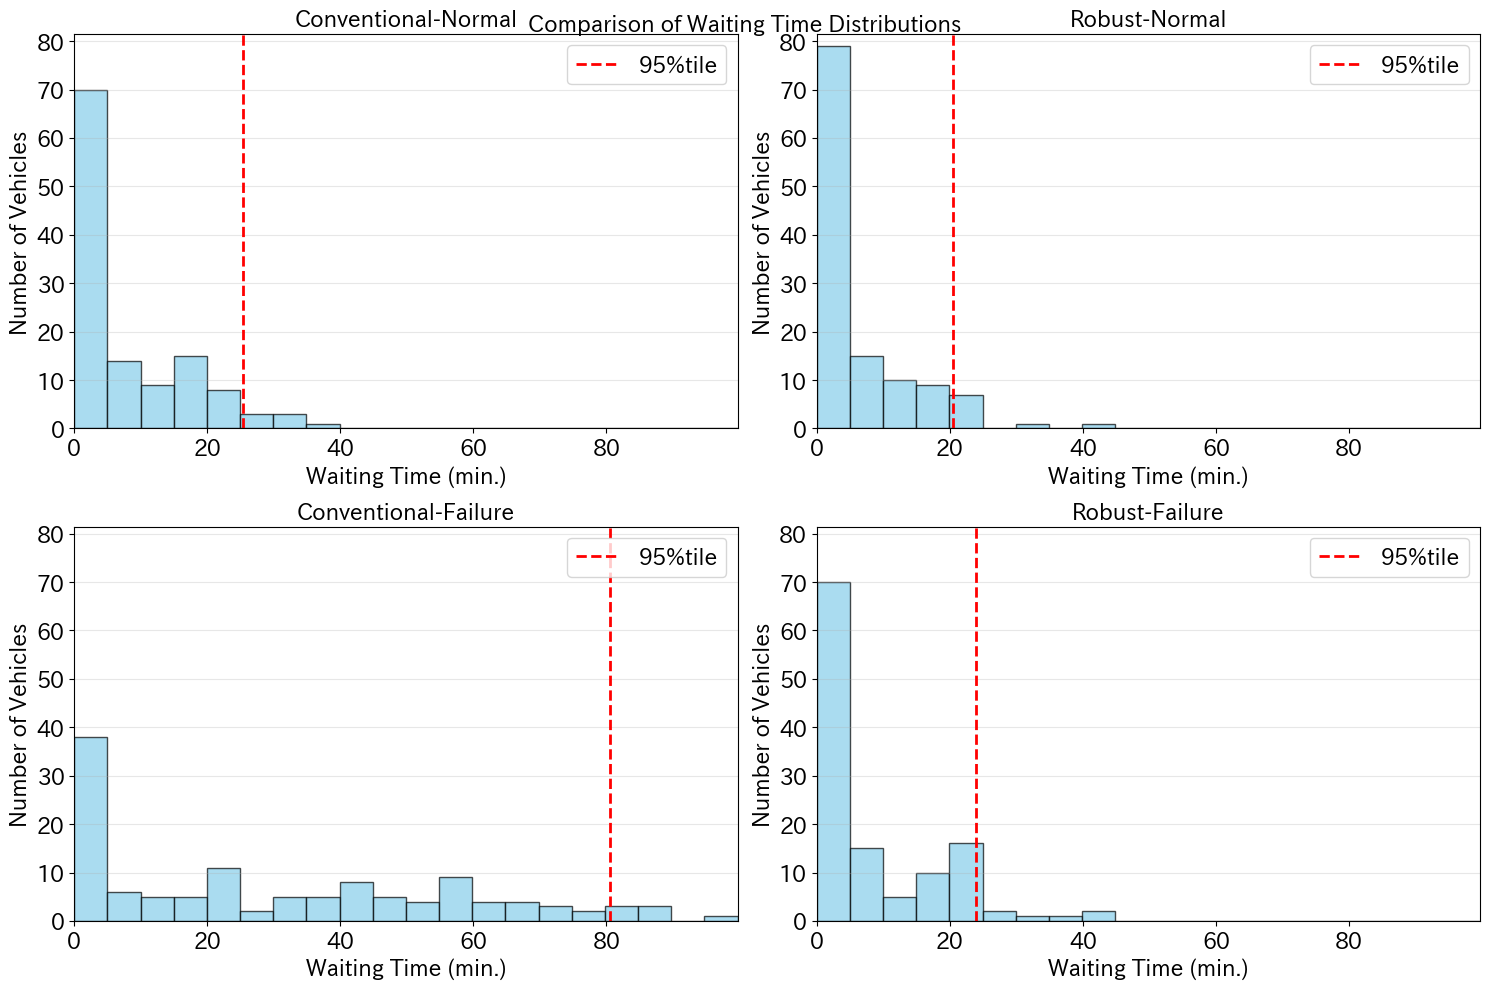

In [ ]:
waiting_time_normal = get_waiting_times(result_file_normal)
waiting_time_normal_failure = get_waiting_times(result_file_normal_failure)
waiting_time_robust = get_waiting_times(result_file_robust)
waiting_time_robust_failure = get_waiting_times(result_file_robust_failure)

waiting_time_normal = charging_trips_normal['WaitingTime'] / 60
waiting_time_normal_failure = charging_trips_normal_failure['WaitingTime'] / 60
waiting_time_robust = charging_trips_robust_health['WaitingTime'] / 60
waiting_time_robust_failure = charging_trips_robust_failure['WaitingTime'] / 60



# 統一された軸範囲の計算
all_waiting_times = list(waiting_time_normal) + list(waiting_time_normal_failure) + list(waiting_time_robust) + list(waiting_time_robust_failure)
max_waiting_time = max(all_waiting_times)
min_waiting_time = min(all_waiting_times)

# 最大頻度の計算（縦軸統一用）
bins = 20
max_frequency = 0
hist_data = [waiting_time_normal, waiting_time_normal_failure, waiting_time_robust, waiting_time_robust_failure]

for data in hist_data:
    counts, _ = np.histogram(data, bins=bins, range=(min_waiting_time, max_waiting_time))
    max_frequency = max(max_frequency, max(counts))
    
# 統一された範囲
xlim_range = (min_waiting_time, max_waiting_time)
ylim_range = (0, max_frequency * 1.1)  # 少し余裕をもたせる

print(f"最大待ち時間: {max_waiting_time}分")
print(f"最小待ち時間: {min_waiting_time}分")
print(f"最大頻度: {max_frequency}台")

# 通常最適化の比較（統一軸）
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
print("通常最適化配置(健常時): ")
plot_waiting_times_unified(result_file_normal, 
                         "Conventional-Normal",
                         xlim_range, ylim_range, bins)

plt.subplot(2, 2, 3)
print("通常最適化配置(故障時): ")
plot_waiting_times_unified(result_file_normal_failure, 
                         "Conventional-Failure",
                         xlim_range, ylim_range, bins)

plt.subplot(2, 2, 2)
print("ロバスト最適配置(健常時): ")
plot_waiting_times_unified(result_file_robust, 
                         "Robust-Normal",
                         xlim_range, ylim_range, bins)

plt.subplot(2, 2, 4)
print("ロバスト最適配置(故障時): ")
plot_waiting_times_unified(result_file_robust_failure, 
                         "Robust-Failure",
                         xlim_range, ylim_range, bins)

plt.tight_layout()
plt.suptitle('Comparison of Waiting Time Distributions', fontsize=16, y=0.98)
plt.show()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
95%tile: 25.30min, 平均: 7.27min, 総待ち時間: 894.10min
95%tile: 80.60min, 平均: 29.60min, 総待ち時間: 3640.56min
95%tile: 20.47min, 平均: 5.38min, 総待ち時間: 656.69min
95%tile: 23.99min, 平均: 7.59min, 総待ち時間: 926.25min


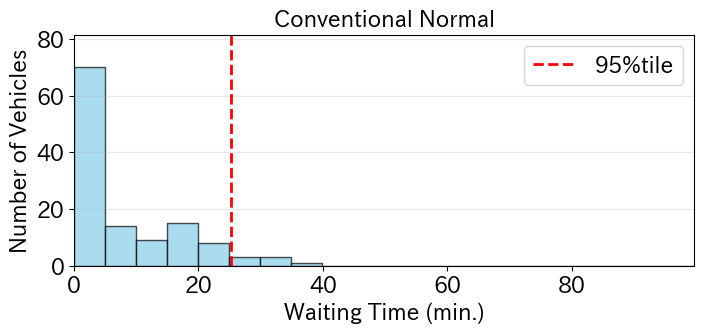

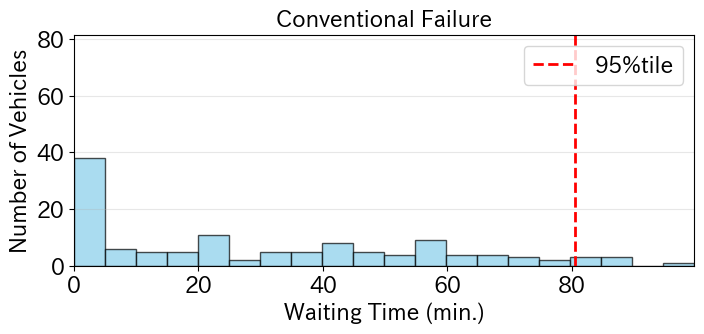

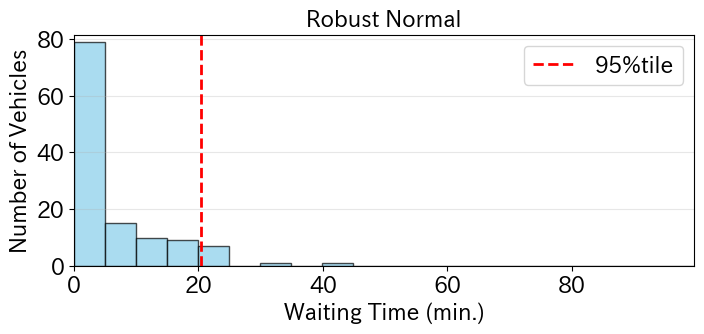

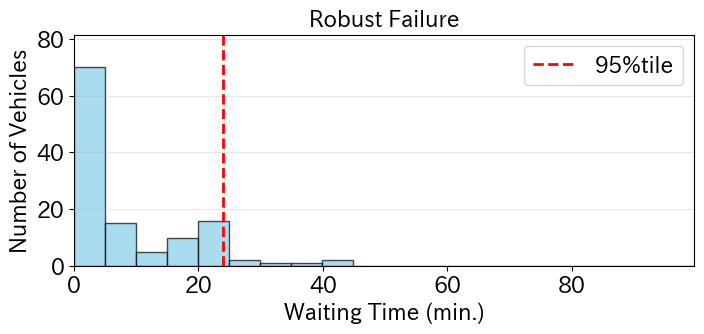

In [ ]:
%load_ext autoreload
%autoreload 2
import importlib
from src.util.vis_result import plot_waiting_times_unified
plt.figure(figsize=(8,3))
plot_waiting_times_unified(result_file_normal, 
                         "Conventional Normal",xlim_range, ylim_range, bins)
plt.figure(figsize=(8,3))
plot_waiting_times_unified(result_file_normal_failure,
                         "Conventional Failure",xlim_range, ylim_range, bins)
plt.figure(figsize=(8,3))
plot_waiting_times_unified(result_file_robust,
                         "Robust Normal",xlim_range, ylim_range, bins)
plt.figure(figsize=(8,3))
plot_waiting_times_unified(result_file_robust_failure,
                         "Robust Failure",xlim_range, ylim_range, bins)

- 通常最適化では故障によって，平均待ち時間が23分増加した。故障CSに向かっていた車両が残りのCSに集中したため。
    - 他の故障シナリオの詳細は表でまとめる
- ロバスト最適化では反対に二分ほど減少。原因として充電車両を考慮せずにCSに向かうため，近場のCSに集中してしまう。
    - eMATESで，CS探索時にそのCSがすでに充電器が埋まっている場合では，次に近いCSを目標地点とする。->仮にすべてのCSの充電器が埋まっている場合は最近傍のCSに向かう。

##### 2.3:総旅行時間,総充電需要，初期コスト，総待ち時間，95パーセンタイル待ち時間の比較

In [ ]:
def aggregate_results(result_file):
        # パラメータ設定
    DISCOUNT_RATE = 0.03
    YEAR = 5
    waiting_times = get_waiting_times(result_file)
    total_waiting_times = sum(waiting_times) /60
    waiting_times_95 = np.percentile(waiting_times, 95)
    demand = get_total_kw(result_file)
    
    with open(result_file, 'rb') as f:
        data = pickle.load(f)
        vehicle_trip = data['vehicle_trip']
        timeseries_kw = data['time_series_kw']
        cs_config = data['cs_config']
    initial_costs = calc_initial_costs(cs_config, timeseries_kw)
    total_trip_time_normal, transport_costs = calc_diff_trnsprt_costs(vehicle_trip)
    running_costs = calc_running_costs(cs_config, timeseries_kw)
    total_kwh = timeseries_kw.sum().sum() / 60

    # 年間コストの割引計算
    running_costs_discounted = sum(
        (running_costs / ((1 + DISCOUNT_RATE) ** i)) for i in range(1, YEAR + 1)
    )
    
    # ユーザーコストの割引計算
    transport_costs_discounted = sum(
        (transport_costs / ((1 + DISCOUNT_RATE) ** i)) for i in range(1, YEAR + 1)
    )
    return {
        "InitialCost": initial_costs,
        "TotalDemand": demand,
        "WaitingTimes": total_waiting_times,
        "95percentileWait": waiting_times_95,
        "TotalTripTime": total_trip_time_normal,
        "TransportCosts": transport_costs_discounted,
        "RunningCosts": running_costs_discounted,
        "TotalCosts": initial_costs + running_costs_discounted + transport_costs_discounted
    }
# # 通常最適化＿健常時
# normal_results = aggregate_results(result_file_normal)
# # 通常最適化＿故障時
# normal_results_failure = aggregate_results(result_file_normal_failure)
# # ロバスト最適化＿健常時
# robust_results = aggregate_results(result_file_robust)
# # ロバスト最適化＿故障時
# robust_results_failure = aggregate_results(result_file_robust_failure)
# # 5か所の通常最適化
# normal_results_5_locations = aggregate_results(result_file_5loc)
# normal_results_5_locations_failure = aggregate_results(result_file_5loc_failure)

# result_filesとcase_namesを対応させてデータを収集
result_data = []

for file, case in zip(result_files, case_names):
    result = aggregate_results(file)
    result_data.append({
        "Case": case,
        "InitialCost": result["InitialCost"],
        "TotalDemand": result["TotalDemand"], 
        "WaitingTimes": result["WaitingTimes"],
        "95percentileWait": result["95percentileWait"],
        "TotalTripTime": result["TotalTripTime"],
        "TransportCosts": result["TransportCosts"],
        "RunningCosts": result["RunningCosts"],
        "TotalCosts": result["TotalCosts"]
    })

# DataFrameを作成
df = pd.DataFrame(result_data)
df.set_index("Case", inplace=True)
df_rounded = df.round(3)
df_rounded

##### 待ち時間と総旅行時間の比率を可視化

In [ ]:
# 棒グラフで表示
import matplotlib.pyplot as plt

# # スケールが異なるため、個別に表示
# for i, col in enumerate(df.columns):
#     if col == "TotalDemand":
#         continue
#     color = plt.cm.viridis(i / len(df.columns))
#     plt.figure(figsize=(5,3))
#     df[col].plot(kind='bar', color=color)
#     plt.title(f'Optimization Results - {col}')
#     plt.ylabel('Value')
#     plt.xlabel('Case')
#     plt.xticks(rotation=45)
#     plt.grid(axis='y', linestyle='--', alpha=0.7)
#     plt.tight_layout()
#     plt.show()
# 待ち時間と総旅行時間の比率を可視化するために積み上げ図を作成
waiting_times = df['WaitingTimes']
total_trip_times = df['TotalTripTime']
plt.figure(figsize=(6,4))
plt.bar(df.index, total_trip_times, label='Total trip time', color='green', alpha=0.5)
plt.bar(df.index, waiting_times, label='Total waiting time', color='skyblue', alpha=1)
plt.ylabel('Time (hours)')
plt.xlabel('Case')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("=== 最適化結果の集計 ===")
print(f'総旅行時間: {total_trip_times} hours')

##### 2.4: 初期コスト分析
通常最適化とロバスト最適化の初期コスト比較、投資効率性の評価

In [ ]:
# 初期コスト分析
def analyze_initial_costs(cases):
    """初期コストの詳細分析を実行"""
    
    initial_cost_analysis = {}
    
    for case_name, result_file in cases.items():
        with open(result_file, 'rb') as f:
            data = pickle.load(f)
        
        cs_config = data['cs_config']
        time_series_kw = data['time_series_kw']
        
        # 初期コストの詳細計算
        initial_cost = calc_initial_costs(cs_config, time_series_kw)
        
        # 充電ステーション設置数と容量
        installed_cs = sum(1 for ports in cs_config['ports'] if ports > 0)
        total_ports = sum(cs_config['ports'])
        total_capacity = sum(cap * ports for cap, ports in zip(cs_config['cap_kw'], cs_config['ports']))
        
        # 総充電量（需要）
        total_demand = time_series_kw.sum().sum() / 60  # kWh
        
        # 性能指標
        waiting_times = get_waiting_times(result_file)
        total_waiting_time = sum(waiting_times) / 60  # hours
        
        # 投資効率性指標
        cost_per_station = initial_cost / installed_cs if installed_cs > 0 else 0
        cost_per_port = initial_cost / total_ports if total_ports > 0 else 0
        cost_per_kwh_capacity = initial_cost / total_capacity if total_capacity > 0 else 0
        cost_per_kwh_demand = initial_cost / total_demand if total_demand > 0 else 0
        
        # 性能効率性指標
        performance_per_cost = total_demand / (initial_cost / 1000000) if initial_cost > 0 else 0  # kWh per million yen
        waiting_time_per_cost = total_waiting_time / (initial_cost / 1000000) if initial_cost > 0 else 0  # hours per million yen
        
        initial_cost_analysis[case_name] = {
            'initial_cost_million_yen': initial_cost / 1000000,
            'installed_stations': installed_cs,
            'total_ports': total_ports,
            'total_capacity_kw': total_capacity,
            'total_demand_kwh': total_demand,
            'total_waiting_time_hours': total_waiting_time,
            'cost_per_station_million': cost_per_station / 1000000,
            'cost_per_port_million': cost_per_port / 1000000,
            'cost_per_kwh_capacity_yen': cost_per_kwh_capacity,
            'cost_per_kwh_demand_yen': cost_per_kwh_demand,
            'performance_per_cost_kwh_per_million': performance_per_cost,
            'waiting_time_per_cost_hours_per_million': waiting_time_per_cost
        }
    
    return initial_cost_analysis

# 初期コスト分析の実行
result_files = []
for file, case in zip(result_files, case_names):
    cases = {case: file for case, file in zip(case_names, result_files)}
cost_analysis = analyze_initial_costs(cases)

# 結果をDataFrameに変換
cost_df = pd.DataFrame(cost_analysis).T

print("="*80)
print("【初期コスト詳細分析】")
print("="*80)
print(cost_df.round(3))

# 主要指標の比較
print("\n" + "="*80)
print("【コスト効率性比較】")
print("="*80)

# 通常最適化 vs ロバスト最適化（健常時）
normal_cost = cost_analysis['']['initial_cost_million_yen']
robust_cost = cost_analysis['Robust Normal']['initial_cost_million_yen']
cost_difference = robust_cost - normal_cost
cost_ratio = robust_cost / normal_cost if normal_cost > 0 else 0

print(f"初期コスト比較（健常時）:")
print(f"  通常最適化: {normal_cost:.2f} 百万円")
print(f"  ロバスト最適化: {robust_cost:.2f} 百万円")
print(f"  差額: {cost_difference:+.2f} 百万円 ({((cost_ratio-1)*100):+.1f}%)")

# 投資効率性の比較
normal_perf_per_cost = cost_analysis['Conventional Normal']['performance_per_cost_kwh_per_million']
robust_perf_per_cost = cost_analysis['Robust Normal']['performance_per_cost_kwh_per_million']
perf_efficiency_ratio = robust_perf_per_cost / normal_perf_per_cost if normal_perf_per_cost > 0 else 0

print(f"\n投資効率性比較（性能/コスト）:")
print(f"  通常最適化: {normal_perf_per_cost:.1f} kWh/百万円")
print(f"  ロバスト最適化: {robust_perf_per_cost:.1f} kWh/百万円")
print(f"  効率比: {perf_efficiency_ratio:.3f} ({((perf_efficiency_ratio-1)*100):+.1f}%)")

# 故障時の追加コストなしでの性能維持
print(f"\n【ロバスト性の経済価値】")
normal_failure_waiting = cost_analysis['Conventional Failure']['total_waiting_time_hours']
normal_normal_waiting = cost_analysis['Conventional Normal']['total_waiting_time_hours']
robust_failure_waiting = cost_analysis['Robust Failure']['total_waiting_time_hours']
robust_normal_waiting = cost_analysis['Robust Normal']['total_waiting_time_hours']

normal_degradation = normal_failure_waiting - normal_normal_waiting
robust_degradation = robust_failure_waiting - robust_normal_waiting
degradation_reduction = normal_degradation - robust_degradation

print(f"故障時の待ち時間増加:")
print(f"  通常最適化: {normal_degradation:+.1f} 時間")
print(f"  ロバスト最適化: {robust_degradation:+.1f} 時間")
print(f"  劣化軽減効果: {degradation_reduction:.1f} 時間")

# 単位あたりコスト比較
print(f"\n【単位コスト比較】")
for metric in ['cost_per_station_million', 'cost_per_port_million', 'cost_per_kwh_capacity_yen']:
    normal_val = cost_analysis['Conventional Normal'][metric]
    robust_val = cost_analysis['Robust Normal'][metric]
    ratio = robust_val / normal_val if normal_val > 0 else 0
    
    unit_map = {
        'cost_per_station_million': '百万円/ステーション',
        'cost_per_port_million': '百万円/ポート',
        'cost_per_kwh_capacity_yen': '円/kW'
    }
    
    print(f"{unit_map[metric]}:")
    print(f"  通常最適化: {normal_val:.3f}")
    print(f"  ロバスト最適化: {robust_val:.3f}")
    print(f"  比率: {ratio:.3f} ({((ratio-1)*100):+.1f}%)")

print("="*80)

#### ワーストケース以外の故障ケースでの性能評価

In [ ]:
from src.util.optimization import calc_initial_costs
def plot_comprehensive_comparison_boxplots(all_normal_health_dir, all_normal_failure_dir, 
                                         all_robust_health_dir, all_robust_failure_dir):
    """
    4つのケース（通常平常・故障、ロバスト平常・故障）を箱ひげ図で比較表示
    """
    
    # 各ケースのデータを取得
    cases = {
        'Conventional\nw/o Failure': all_normal_health_dir,
        'Conventional\nw/ Failure': all_normal_failure_dir,
        'Robust\nw/o Failure': all_robust_health_dir,
        'Robust\nw/ Failure': all_robust_failure_dir
    }
    
    all_data = {}
    colors = ['lightblue', 'salmon', 'lightgreen', 'orange']
    
    for i, (case_name, directory) in enumerate(cases.items()):
        if directory and os.path.exists(directory):
            pkl_files = glob.glob(os.path.join(directory, 'trial_*.pkl'))
            if not pkl_files:  # trial_*.pklがない場合は単一ファイルを探す
                pkl_files = glob.glob(os.path.join(directory, '*.pkl'))
            
            results = []
            for file in pkl_files:
                try:
                    res = aggregate_results(file)
                    results.append(res)
                except Exception as e:
                    print(f"エラー: {file} - {e}")
            
            if results:
                all_data[case_name] = pd.DataFrame(results)
                print(f"{case_name}: {len(results)}件のデータ")
            else:
                print(f"{case_name}: データが見つかりません")
        else:
            print(f"{case_name}: ディレクトリが存在しません - {directory}")
    
    if not all_data:
        print("比較可能なデータがありません")
        return None, None
    
    # 複数指標での比較
    metrics = ['TotalTripTime', 'WaitingTimes']
    metric_names = ['Total Trip Time (h)', 'Total Waiting Time (h)']

    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, (metric, name) in enumerate(zip(metrics, metric_names)):
        ax = axes[i]
        
        # 各ケースの箱ひげ図データを準備
        data_to_plot = []
        labels = []
        case_colors = []
        
        for j, (case_name, df) in enumerate(all_data.items()):
            if metric in df.columns:
                metric_data = df[metric]
                if metric == 'InitialCost':
                    metric_data = metric_data / 1000000  # 百万円単位
                
                data_to_plot.append(metric_data)
                labels.append(case_name)
                case_colors.append(colors[j % len(colors)])
        
        if data_to_plot:
            # 箱ひげ図を描画
            bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
            
            # 色の設定
            for patch, color in zip(bp['boxes'], case_colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            # 中央値線を赤色に
            for median in bp['medians']:
                median.set_color('red')
                median.set_linewidth(2)
            
            ax.set_title(name, fontsize=14, fontweight='bold')
            ax.grid(axis='y', alpha=0.3)
            ax.tick_params(axis='x', labelsize=16)
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
            
            # 統計情報をテキストで表示
            stats_text = ""
            for k, (case_name, data) in enumerate(zip(labels, data_to_plot)):
                mean_val = np.mean(data)
                std_val = np.std(data)
                stats_text += f"{case_name.replace(chr(10), ' ')}: μ={mean_val:.2f}, σ={std_val:.2f}\n"
            
            # 統計情報を右上に表示
            ax.text(0.98, 0.98, stats_text, transform=ax.transAxes, 
                   fontsize=12, verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.suptitle('Comprehensive Performance Comparison: 4-Case Analysis\n(Conventional vs Robust × Normal vs Failure)', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 詳細統計を表示
    print("\n" + "="*80)
    print("【4ケース詳細統計比較】")
    print("="*80)
    
    for metric in metrics:
        print(f"\n■ {metric}")
        print("-" * 60)
        
        for case_name, df in all_data.items():
            if metric in df.columns:
                data = df[metric]
                if metric == 'InitialCost':
                    data = data / 1000000
                    unit = "百万円"
                elif 'Time' in metric:
                    unit = "時間" if 'Trip' in metric or 'Waiting' in metric else "分"
                else:
                    unit = "分"
                
                print(f"{case_name:20}: 平均{data.mean():8.2f}{unit} "
                      f"(中央値{data.median():6.2f}, 標準偏差{data.std():6.2f})")
    
    # 改善効果の計算
    print("\n" + "="*80)
    print("【改善効果分析】")
    print("="*80)
    
    # ロバスト最適化による改善効果（故障時）
    if 'Conventional\n(Failure)' in all_data and 'Robust\n(Failure)' in all_data:
        conv_failure = all_data['Conventional\n(Failure)']
        robust_failure = all_data['Robust\n(Failure)']
        
        print("\n■ 故障シナリオでのロバスト最適化の改善効果:")
        for metric in metrics:
            if metric in conv_failure.columns and metric in robust_failure.columns:
                conv_mean = conv_failure[metric].mean()
                robust_mean = robust_failure[metric].mean()
                improvement = ((conv_mean - robust_mean) / conv_mean) * 100
                
                print(f"  {metric:20}: {improvement:+6.2f}% 改善")
    
    # 故障による性能劣化
    print("\n■ 故障による性能劣化:")
    for opt_type in ['Conventional', 'Robust']:
        normal_key = f'{opt_type}\n(Normal)'
        failure_key = f'{opt_type}\n(Failure)'
        
        if normal_key in all_data and failure_key in all_data:
            normal_data = all_data[normal_key]
            failure_data = all_data[failure_key]
            
            print(f"\n  {opt_type}最適化:")
            for metric in metrics:
                if metric in normal_data.columns and metric in failure_data.columns:
                    normal_mean = normal_data[metric].mean()
                    failure_mean = failure_data[metric].mean()
                    degradation = ((failure_mean - normal_mean) / normal_mean) * 100
                    
                    print(f"    {metric:18}: {degradation:+6.2f}% 変化")
    
    return all_data

comprehensive_data = plot_comprehensive_comparison_boxplots(
    normal_save_dir, normal_failure_save_dir, 
    robust_save_dir, robust_failure_save_dir
)

# 要約テーブルの作成
def create_summary_table(comprehensive_data):
    """
    4ケースの要約統計テーブルを作成
    """
    if not comprehensive_data:
        return None
    
    metrics = ['TotalTripTime', 'WaitingTimes', '95percentileWait', 'InitialCost']
    summary_stats = []
    
    for case_name, df in comprehensive_data.items():
        case_stats = {'Case': case_name.replace('\n', ' ')}
        
        for metric in metrics:
            if metric in df.columns:
                data = df[metric]
                if metric == 'InitialCost':
                    data = data / 1000000
                
                case_stats[f'{metric}_mean'] = data.mean()
                case_stats[f'{metric}_std'] = data.std()
                case_stats[f'{metric}_median'] = data.median()
        
        summary_stats.append(case_stats)
    
    summary_df = pd.DataFrame(summary_stats)
    return summary_df

if comprehensive_data:
    summary_table = create_summary_table(comprehensive_data)
    if summary_table is not None:
        print("\n" + "="*80)
        print("【要約統計テーブル】")
        print("="*80)
        print(summary_table.round(3))

In [ ]:
def create_comprehensive_performance_table(all_normal_health_dir, all_normal_failure_dir, 
                                         all_robust_health_dir, all_robust_failure_dir):
    """
    4ケースの詳細性能比較表を作成（改善率・振れ幅・ロバスト性指標を含む）
    """
    
    # 各ケースのデータを取得
    cases = {
        'Conventional Normal': all_normal_health_dir,
        'Conventional Failure': all_normal_failure_dir,
        'Robust Normal': all_robust_health_dir,
        'Robust Failure': all_robust_failure_dir
    }
    
    all_data = {}
    
    for case_name, directory in cases.items():
        if directory and os.path.exists(directory):
            pkl_files = glob.glob(os.path.join(directory, 'trial_*.pkl'))
            if not pkl_files:  # trial_*.pklがない場合は単一ファイルを探す
                pkl_files = glob.glob(os.path.join(directory, '*.pkl'))
            
            results = []
            for file in pkl_files:
                try:
                    res = aggregate_results(file)
                    results.append(res)
                except Exception as e:
                    print(f"エラー: {file} - {e}")
            
            if results:
                all_data[case_name] = pd.DataFrame(results)
                print(f"{case_name}: {len(results)}件のデータ")
    
    if not all_data:
        print("比較可能なデータがありません")
        return None
    
    # 性能指標の定義
    metrics = ['TotalTripTime', 'WaitingTimes', '95percentileWait']
    metric_names = ['Total Trip Time (h)', 'Total Waiting Time (h)', '95th Percentile Wait (min)']
    
    # 詳細統計表の作成
    detailed_stats = []
    
    for case_name, df in all_data.items():
        case_stats = {'Case': case_name}
        
        for metric in metrics:
            if metric in df.columns:
                data = df[metric]
                case_stats[f'{metric}_Mean'] = data.mean()
                case_stats[f'{metric}_Std'] = data.std()
                case_stats[f'{metric}_Min'] = data.min()
                case_stats[f'{metric}_Max'] = data.max()
                case_stats[f'{metric}_Median'] = data.median()
                case_stats[f'{metric}_CV'] = data.std() / data.mean() if data.mean() != 0 else 0  # 変動係数
        
        detailed_stats.append(case_stats)
    
    detailed_df = pd.DataFrame(detailed_stats)
    
    # 改善率・劣化率の計算
    improvement_analysis = []
    
    # 1. ロバスト最適化による改善効果（故障時）
    if 'Conventional Failure' in all_data and 'Robust Failure' in all_data:
        conv_failure = all_data['Conventional Failure']
        robust_failure = all_data['Robust Failure']
        
        improvement_row = {'Comparison': 'Robust vs Conventional (Failure Scenario)'}
        
        for metric in metrics:
            if metric in conv_failure.columns and metric in robust_failure.columns:
                conv_mean = conv_failure[metric].mean()
                robust_mean = robust_failure[metric].mean()
                improvement = ((conv_mean - robust_mean) / conv_mean) * 100
                improvement_row[f'{metric}_Improvement'] = improvement
        
        improvement_analysis.append(improvement_row)
    
    # 2. 故障による性能劣化（通常最適化）
    if 'Conventional Normal' in all_data and 'Conventional Failure' in all_data:
        conv_normal = all_data['Conventional Normal']
        conv_failure = all_data['Conventional Failure']
        
        degradation_row = {'Comparison': 'Conventional: Failure Impact'}
        
        for metric in metrics:
            if metric in conv_normal.columns and metric in conv_failure.columns:
                normal_mean = conv_normal[metric].mean()
                failure_mean = conv_failure[metric].mean()
                degradation = ((failure_mean - normal_mean) / normal_mean) * 100
                degradation_row[f'{metric}_Degradation'] = degradation
        
        improvement_analysis.append(degradation_row)
    
    # 3. 故障による性能劣化（ロバスト最適化）
    if 'Robust Normal' in all_data and 'Robust Failure' in all_data:
        robust_normal = all_data['Robust Normal']
        robust_failure = all_data['Robust Failure']
        
        degradation_row = {'Comparison': 'Robust: Failure Impact'}
        
        for metric in metrics:
            if metric in robust_normal.columns and metric in robust_failure.columns:
                normal_mean = robust_normal[metric].mean()
                failure_mean = robust_failure[metric].mean()
                degradation = ((failure_mean - normal_mean) / normal_mean) * 100
                degradation_row[f'{metric}_Degradation'] = degradation
        
        improvement_analysis.append(degradation_row)
    
    improvement_df = pd.DataFrame(improvement_analysis)
    
    # ロバスト性指標の計算
    robustness_metrics = []
    
    for opt_type in ['Conventional', 'Robust']:
        normal_key = f'{opt_type} Normal'
        failure_key = f'{opt_type} Failure'
        
        if normal_key in all_data and failure_key in all_data:
            normal_data = all_data[normal_key]
            failure_data = all_data[failure_key]
            
            robustness_row = {'Optimization': opt_type}
            
            for metric in metrics:
                if metric in normal_data.columns and metric in failure_data.columns:
                    # 変動係数の比較（振れ幅の指標）
                    normal_cv = normal_data[metric].std() / normal_data[metric].mean()
                    failure_cv = failure_data[metric].std() / failure_data[metric].mean()
                    
                    # 最悪ケース性能（95パーセンタイル）
                    normal_95 = normal_data[metric].quantile(0.95)
                    failure_95 = failure_data[metric].quantile(0.95)
                    
                    # 性能劣化の標準偏差（ロバスト性の指標）
                    performance_changes = []
                    min_len = min(len(normal_data), len(failure_data))
                    for i in range(min_len):
                        normal_val = normal_data[metric].iloc[i]
                        failure_val = failure_data[metric].iloc[i]
                        change = ((failure_val - normal_val) / normal_val) * 100
                        performance_changes.append(change)
                    
                    robustness_row[f'{metric}_Normal_CV'] = normal_cv
                    robustness_row[f'{metric}_Failure_CV'] = failure_cv
                    robustness_row[f'{metric}_Normal_95th'] = normal_95
                    robustness_row[f'{metric}_Failure_95th'] = failure_95
                    robustness_row[f'{metric}_Change_Std'] = np.std(performance_changes)
            
            robustness_metrics.append(robustness_row)
    
    robustness_df = pd.DataFrame(robustness_metrics)
    
    # 結果の表示
    print("="*100)
    print("【詳細性能統計表】")
    print("="*100)
    
    # 主要統計を見やすく整理
    summary_table = []
    for _, row in detailed_df.iterrows():
        case = row['Case']
        summary_row = {'Case': case}
        
        for metric in metrics:
            mean_col = f'{metric}_Mean'
            std_col = f'{metric}_Std'
            cv_col = f'{metric}_CV'
            
            if mean_col in row:
                mean_val = row[mean_col]
                std_val = row[std_col]
                cv_val = row[cv_col]
                
                summary_row[metric] = f"{mean_val:.2f}±{std_val:.2f} (CV:{cv_val:.3f})"
        
        summary_table.append(summary_row)
    
    summary_df = pd.DataFrame(summary_table)
    print(summary_df.to_string(index=False))
    
    print("\n" + "="*100)
    print("【改善率・劣化率分析】")
    print("="*100)
    
    if not improvement_df.empty:
        # 改善率表を見やすく整理
        improvement_summary = []
        for _, row in improvement_df.iterrows():
            comparison = row['Comparison']
            summary_row = {'Comparison': comparison}
            
            for metric in metrics:
                improvement_col = f'{metric}_Improvement'
                degradation_col = f'{metric}_Degradation'
                
                if improvement_col in row and pd.notna(row[improvement_col]):
                    summary_row[metric] = f"{row[improvement_col]:+.1f}%"
                elif degradation_col in row and pd.notna(row[degradation_col]):
                    summary_row[metric] = f"{row[degradation_col]:+.1f}%"
                else:
                    summary_row[metric] = "N/A"
            
            improvement_summary.append(summary_row)
        
        improvement_summary_df = pd.DataFrame(improvement_summary)
        print(improvement_summary_df.to_string(index=False))
    
    print("\n" + "="*100)
    print("【ロバスト性指標】")
    print("="*100)
    
    if not robustness_df.empty:
        # ロバスト性比較表
        robustness_comparison = []
        
        for metric in metrics:
            metric_row = {'Metric': metric}
            
            for _, row in robustness_df.iterrows():
                opt_type = row['Optimization']
                change_std_col = f'{metric}_Change_Std'
                normal_cv_col = f'{metric}_Normal_CV'
                failure_cv_col = f'{metric}_Failure_CV'
                
                if change_std_col in row:
                    # 性能変化の標準偏差（小さいほどロバスト）
                    change_std = row[change_std_col]
                    normal_cv = row[normal_cv_col]
                    failure_cv = row[failure_cv_col]
                    
                    metric_row[f'{opt_type}_Volatility'] = f"{change_std:.2f}%"
                    metric_row[f'{opt_type}_Normal_CV'] = f"{normal_cv:.3f}"
                    metric_row[f'{opt_type}_Failure_CV'] = f"{failure_cv:.3f}"
            
            robustness_comparison.append(metric_row)
        
        robustness_comparison_df = pd.DataFrame(robustness_comparison)
        print(robustness_comparison_df.to_string(index=False))
        
        # ロバスト性スコアの計算
        print("\n【ロバスト性スコア】")
        print("-" * 50)
        
        for metric in metrics:
            conv_change_std = robustness_df[robustness_df['Optimization'] == 'Conventional'][f'{metric}_Change_Std'].iloc[0]
            robust_change_std = robustness_df[robustness_df['Optimization'] == 'Robust'][f'{metric}_Change_Std'].iloc[0]
            
            robustness_improvement = ((conv_change_std - robust_change_std) / conv_change_std) * 100
            
            print(f"{metric:25}: {robustness_improvement:+6.1f}% improvement in stability")
    
    # CSVファイルとして保存
    timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M")
    
    detailed_df.to_csv(f'performance_detailed_{timestamp}.csv', index=False)
    improvement_summary_df.to_csv(f'improvement_analysis_{timestamp}.csv', index=False)
    robustness_comparison_df.to_csv(f'robustness_metrics_{timestamp}.csv', index=False)
    
    print(f"\n結果をCSVファイルに保存しました（タイムスタンプ: {timestamp}）")
    
    return {
        'detailed_stats': detailed_df,
        'improvement_analysis': improvement_summary_df,
        'robustness_metrics': robustness_comparison_df,
        'raw_data': all_data
    }

# 実行例
print("=== 包括的性能分析表の作成 ===")

# ディレクトリパスを設定
all_normal_health_dir = "../output/normal/20250828_1604"  # 通常最適化・平常時
all_normal_failure_dir = "../output/normal/20250924_0930_FAILURE"  # 通常最適化・故障時
all_robust_health_dir = "../output/robust/20250829_0129_FAILURE/health"  # ロバスト最適化・平常時
all_robust_failure_dir = "../output/robust/20250924_0853_FAILURE_1118yen_newemates"  # ロバスト最適化・故障時

performance_analysis = create_comprehensive_performance_table(
    all_normal_health_dir, all_normal_failure_dir, 
    all_robust_health_dir, all_robust_failure_dir
)

# 追加の可視化：ロバスト性の比較
def plot_robustness_comparison(performance_analysis):
    """ロバスト性指標を視覚的に比較"""
    
    if not performance_analysis or 'raw_data' not in performance_analysis:
        return
    
    raw_data = performance_analysis['raw_data']
    metrics = ['TotalTripTime', 'WaitingTimes', '95percentileWait']
    metric_names = ['Total Trip Time (h)', 'Total Waiting Time (h)', '95th Percentile Wait (min)']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i, (metric, name) in enumerate(zip(metrics, metric_names)):
        ax = axes[i]
        
        # 各手法の正常時と故障時のデータを準備
        conv_normal = raw_data.get('Conventional Normal', pd.DataFrame())
        conv_failure = raw_data.get('Conventional Failure', pd.DataFrame())
        robust_normal = raw_data.get('Robust Normal', pd.DataFrame())
        robust_failure = raw_data.get('Robust Failure', pd.DataFrame())
        
        data_to_plot = []
        labels = []
        colors = []
        
        if not conv_normal.empty and metric in conv_normal.columns:
            data_to_plot.append(conv_normal[metric])
            labels.append('Conv.\nNormal')
            colors.append('lightblue')
        
        if not conv_failure.empty and metric in conv_failure.columns:
            data_to_plot.append(conv_failure[metric])
            labels.append('Conv.\nFailure')
            colors.append('salmon')
        
        if not robust_normal.empty and metric in robust_normal.columns:
            data_to_plot.append(robust_normal[metric])
            labels.append('Robust\nNormal')
            colors.append('lightgreen')
        
        if not robust_failure.empty and metric in robust_failure.columns:
            data_to_plot.append(robust_failure[metric])
            labels.append('Robust\nFailure')
            colors.append('orange')
        
        if data_to_plot:
            # 箱ひげ図を描画
            bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
            
            # 色の設定
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            # 中央値線を強調
            for median in bp['medians']:
                median.set_color('red')
                median.set_linewidth(2)
            
            ax.set_title(name, fontsize=14, fontweight='bold')
            ax.grid(axis='y', alpha=0.3)
            
            # 変動係数を表示
            cv_text = ""
            for j, (label, data) in enumerate(zip(labels, data_to_plot)):
                cv = data.std() / data.mean() if data.mean() != 0 else 0
                cv_text += f"{label}: CV={cv:.3f}\n"
            
            ax.text(0.02, 0.98, cv_text, transform=ax.transAxes, 
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.suptitle('Robustness Comparison: Performance Variability Analysis', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

if performance_analysis:
    plot_robustness_comparison(performance_analysis)

#### 各dライバーの旅行時間分布からConv.w/ failの異常確認

#### 全ケースの最大旅行時間分析（充電車両・非充電車両別）

In [ ]:
# 全ケースの最大旅行時間分析
def analyze_max_travel_times():
    """全ケースの最大旅行時間を充電車両・非充電車両別に分析"""
    
    cases = {
        'Conventional Normal': result_file_normal,
        'Conventional Failure': result_file_normal_failure,
        'Robust Normal': result_file_normal_old,
        'Robust Failure': result_file_normal_failure_old
    }
    
    max_travel_analysis = {}
    
    for case_name, result_file in cases.items():
        with open(result_file, 'rb') as f:
            data = pickle.load(f)
            vehicle_trip = data['vehicle_trip']
            
        # EndTimeのNaN値を86400（24時間）で埋める
        vehicle_trip['EndTime'] = vehicle_trip['EndTime'].fillna(86400)
        
        # 充電車両と非充電車両に分類
        charging_trips = vehicle_trip[vehicle_trip['startChargingTime'] > 0].copy()
        no_charging_trips = vehicle_trip[vehicle_trip['startChargingTime'] == 0].copy()
        
        # 旅行時間を計算（秒→分）
        charging_trips['tripTime'] = (charging_trips['EndTime'] - charging_trips['StartTime']) / 60
        no_charging_trips['tripTime'] = (no_charging_trips['EndTime'] - no_charging_trips['StartTime']) / 60
        
        # 最大旅行時間と該当車両数
        max_charging_time = charging_trips['tripTime'].max() if len(charging_trips) > 0 else 0
        max_no_charging_time = no_charging_trips['tripTime'].max() if len(no_charging_trips) > 0 else 0
        
        # 全体の最大値
        overall_max_time = max(max_charging_time, max_no_charging_time)
        
        # 最大値に該当する車両の詳細情報
        if max_charging_time >= max_no_charging_time and len(charging_trips) > 0:
            max_trip_type = "充電車両"
            max_trip_data = charging_trips[charging_trips['tripTime'] == max_charging_time].iloc[0]
            max_trip_details = {
                'vehicle_type': '充電車両',
                'trip_time_min': max_charging_time,
                'start_time': max_trip_data['StartTime'] / 3600,  # hours
                'end_time': max_trip_data['EndTime'] / 3600,  # hours
                'cs_id': max_trip_data['CSID'],
                'waiting_time_min': (max_trip_data['startChargingTime'] - max_trip_data['WaitingEntryTime']) / 60 if max_trip_data['WaitingEntryTime'] > 0 else 0
            }
        else:
            max_trip_type = "非充電車両"
            if len(no_charging_trips) > 0:
                max_trip_data = no_charging_trips[no_charging_trips['tripTime'] == max_no_charging_time].iloc[0]
                max_trip_details = {
                    'vehicle_type': '非充電車両',
                    'trip_time_min': max_no_charging_time,
                    'start_time': max_trip_data['StartTime'] / 3600,  # hours
                    'end_time': max_trip_data['EndTime'] / 3600,  # hours
                    'cs_id': 0,
                    'waiting_time_min': 0
                }
            else:
                max_trip_details = {'vehicle_type': '非充電車両', 'trip_time_min': 0}
        
        # 車両数の統計
        num_charging_vehicles = len(charging_trips)
        num_no_charging_vehicles = len(no_charging_trips)
        total_vehicles = num_charging_vehicles + num_no_charging_vehicles
        
        max_travel_analysis[case_name] = {
            'max_charging_time_min': max_charging_time,
            'max_no_charging_time_min': max_no_charging_time,
            'overall_max_time_min': overall_max_time,
            'max_trip_type': max_trip_type,
            'max_trip_details': max_trip_details,
            'num_charging_vehicles': num_charging_vehicles,
            'num_no_charging_vehicles': num_no_charging_vehicles,
            'total_vehicles': total_vehicles,
            'charging_ratio': num_charging_vehicles / total_vehicles if total_vehicles > 0 else 0
        }
    
    return max_travel_analysis

# 分析実行
max_travel_data = analyze_max_travel_times()

# 結果の表示
print("="*100)
print("【全ケース最大旅行時間分析】")
print("="*100)

# 各ケースの詳細結果
for case_name, data in max_travel_data.items():
    print(f"\n■ {case_name}")
    print(f"  充電車両の最大旅行時間: {data['max_charging_time_min']:.1f} 分")
    print(f"  非充電車両の最大旅行時間: {data['max_no_charging_time_min']:.1f} 分")
    print(f"  全体の最大旅行時間: {data['overall_max_time_min']:.1f} 分 ({data['max_trip_type']})")
    print(f"  車両数 - 充電: {data['num_charging_vehicles']}, 非充電: {data['num_no_charging_vehicles']}, 計: {data['total_vehicles']}")
    print(f"  充電車両割合: {data['charging_ratio']:.1%}")
    
    # 最大旅行時間車両の詳細
    details = data['max_trip_details']
    if 'vehicle_id' in details:
        print(f"  最大旅行時間車両詳細:")
        print(f"    車両ID: {details['vehicle_id']}, タイプ: {details['vehicle_type']}")
        print(f"    出発時刻: {details['start_time']:.2f}h, 到着時刻: {details['end_time']:.2f}h")
        if details['cs_id'] > 0:
            print(f"    利用CS: {details['cs_id']}, 待ち時間: {details['waiting_time_min']:.1f}分")

# 比較テーブルの作成
print(f"\n{'='*100}")
print("【最大旅行時間比較テーブル】")
print(f"{'='*100}")

comparison_data = []
for case_name, data in max_travel_data.items():
    comparison_data.append({
        'ケース': case_name,
        '充電車両最大時間(分)': f"{data['max_charging_time_min']:.1f}",
        '非充電車両最大時間(分)': f"{data['max_no_charging_time_min']:.1f}",
        '全体最大時間(分)': f"{data['overall_max_time_min']:.1f}",
        '最大時間車両タイプ': data['max_trip_type'],
        '充電車両数': data['num_charging_vehicles'],
        '非充電車両数': data['num_no_charging_vehicles'],
        '総車両数': data['total_vehicles'],
        '充電割合(%)': f"{data['charging_ratio']*100:.1f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# 最大旅行時間の統計
print(f"\n{'='*100}")
print("【最大旅行時間統計】")
print(f"{'='*100}")

all_max_times = [data['overall_max_time_min'] for data in max_travel_data.values()]
all_charging_max = [data['max_charging_time_min'] for data in max_travel_data.values()]
all_no_charging_max = [data['max_no_charging_time_min'] for data in max_travel_data.values()]

print(f"全体最大旅行時間:")
print(f"  最小: {min(all_max_times):.1f}分, 最大: {max(all_max_times):.1f}分")
print(f"  平均: {np.mean(all_max_times):.1f}分, 標準偏差: {np.std(all_max_times):.1f}分")

print(f"\n充電車両最大旅行時間:")
charging_max_filtered = [x for x in all_charging_max if x > 0]
if charging_max_filtered:
    print(f"  最小: {min(charging_max_filtered):.1f}分, 最大: {max(charging_max_filtered):.1f}分")
    print(f"  平均: {np.mean(charging_max_filtered):.1f}分, 標準偏差: {np.std(charging_max_filtered):.1f}分")

print(f"\n非充電車両最大旅行時間:")
no_charging_max_filtered = [x for x in all_no_charging_max if x > 0]
if no_charging_max_filtered:
    print(f"  最小: {min(no_charging_max_filtered):.1f}分, 最大: {max(no_charging_max_filtered):.1f}分")
    print(f"  平均: {np.mean(no_charging_max_filtered):.1f}分, 標準偏差: {np.std(no_charging_max_filtered):.1f}分")

print("="*100)

In [ ]:
# 最大旅行時間の可視化
def visualize_max_travel_times(max_travel_data):
    """最大旅行時間の可視化"""
    
    # データの準備
    cases = list(max_travel_data.keys())
    charging_max = [data['max_charging_time_min'] for data in max_travel_data.values()]
    no_charging_max = [data['max_no_charging_time_min'] for data in max_travel_data.values()]
    overall_max = [data['overall_max_time_min'] for data in max_travel_data.values()]
    
    # 車両数データ
    charging_counts = [data['num_charging_vehicles'] for data in max_travel_data.values()]
    no_charging_counts = [data['num_no_charging_vehicles'] for data in max_travel_data.values()]
    
    # 1. 最大旅行時間の比較バーチャート
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1-1. 充電車両・非充電車両別の最大旅行時間
    x_pos = np.arange(len(cases))
    width = 0.35
    
    bars1 = ax1.bar(x_pos - width/2, charging_max, width, label='充電車両', color='skyblue', alpha=0.8)
    bars2 = ax1.bar(x_pos + width/2, no_charging_max, width, label='非充電車両', color='lightgreen', alpha=0.8)
    
    ax1.set_title('各ケースの最大旅行時間比較（車両タイプ別）', fontsize=14, fontweight='bold')
    ax1.set_xlabel('最適化ケース', fontsize=12)
    ax1.set_ylabel('最大旅行時間 (分)', fontsize=12)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([case.replace(' ', '\n') for case in cases], fontsize=10)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # 値をバーの上に表示
    for bar, val in zip(bars1, charging_max):
        if val > 0:
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                    f'{val:.0f}', ha='center', va='bottom', fontsize=9)
    for bar, val in zip(bars2, no_charging_max):
        if val > 0:
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                    f'{val:.0f}', ha='center', va='bottom', fontsize=9)
    
    # 1-2. 全体最大旅行時間
    colors = ['#FF6B6B' if 'Failure' in case else '#4ECDC4' for case in cases]
    bars3 = ax2.bar(cases, overall_max, color=colors, alpha=0.8)
    ax2.set_title('各ケースの全体最大旅行時間', fontsize=14, fontweight='bold')
    ax2.set_xlabel('最適化ケース', fontsize=12)
    ax2.set_ylabel('最大旅行時間 (分)', fontsize=12)
    ax2.set_xticklabels([case.replace(' ', '\n') for case in cases], fontsize=10)
    ax2.grid(axis='y', alpha=0.3)
    
    # 値をバーの上に表示
    for bar, val in zip(bars3, overall_max):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 2-1. 車両数の比較（積み上げ棒グラフ）
    bars4 = ax3.bar(cases, charging_counts, label='充電車両', color='skyblue', alpha=0.8)
    bars5 = ax3.bar(cases, no_charging_counts, bottom=charging_counts, label='非充電車両', 
                    color='lightgreen', alpha=0.8)
    
    ax3.set_title('各ケースの車両数分布', fontsize=14, fontweight='bold')
    ax3.set_xlabel('最適化ケース', fontsize=12)
    ax3.set_ylabel('車両数', fontsize=12)
    ax3.set_xticklabels([case.replace(' ', '\n') for case in cases], fontsize=10)
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    
    # 車両数を表示
    for i, (charging, no_charging) in enumerate(zip(charging_counts, no_charging_counts)):
        total = charging + no_charging
        ax3.text(i, total + 10, f'{total}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax3.text(i, charging/2, f'{charging}', ha='center', va='center', fontsize=9)
        ax3.text(i, charging + no_charging/2, f'{no_charging}', ha='center', va='center', fontsize=9)
    
    # 2-2. 充電車両割合の比較
    charging_ratios = [data['charging_ratio'] * 100 for data in max_travel_data.values()]
    bars6 = ax4.bar(cases, charging_ratios, color='orange', alpha=0.8)
    ax4.set_title('各ケースの充電車両割合', fontsize=14, fontweight='bold')
    ax4.set_xlabel('最適化ケース', fontsize=12)
    ax4.set_ylabel('充電車両割合 (%)', fontsize=12)
    ax4.set_xticklabels([case.replace(' ', '\n') for case in cases], fontsize=10)
    ax4.set_ylim(0, 100)
    ax4.grid(axis='y', alpha=0.3)
    
    # パーセンテージを表示
    for bar, val in zip(bars6, charging_ratios):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # 3. 最大旅行時間車両の詳細可視化
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 3-1. 最大旅行時間の時系列プロット
    case_short = ['Conv.\nNormal', 'Conv.\nFailure', 'Robust\nNormal', 'Robust\nFailure']
    
    # 充電車両と非充電車両の最大時間を線グラフで表示
    ax1.plot(case_short, charging_max, 'o-', linewidth=3, markersize=8, 
             label='充電車両', color='skyblue')
    ax1.plot(case_short, no_charging_max, 's-', linewidth=3, markersize=8, 
             label='非充電車両', color='lightgreen')
    ax1.plot(case_short, overall_max, '^-', linewidth=3, markersize=10, 
             label='全体最大', color='red', alpha=0.8)
    
    ax1.set_title('最大旅行時間の推移', fontsize=14, fontweight='bold')
    ax1.set_xlabel('最適化ケース', fontsize=12)
    ax1.set_ylabel('最大旅行時間 (分)', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 値を表示
    for i, (c_max, nc_max, o_max) in enumerate(zip(charging_max, no_charging_max, overall_max)):
        if c_max > 0:
            ax1.text(i, c_max + 5, f'{c_max:.0f}', ha='center', va='bottom', fontsize=9)
        if nc_max > 0:
            ax1.text(i, nc_max + 5, f'{nc_max:.0f}', ha='center', va='bottom', fontsize=9)
        ax1.text(i, o_max + 10, f'{o_max:.0f}', ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='red')
    
    # 3-2. 最大旅行時間車両の分類
    max_trip_types = [data['max_trip_type'] for data in max_travel_data.values()]
    type_counts = pd.Series(max_trip_types).value_counts()
    
    colors_pie = ['skyblue' if '充電' in t else 'lightgreen' for t in type_counts.index]
    wedges, texts, autotexts = ax2.pie(type_counts.values, labels=type_counts.index, 
                                      colors=colors_pie, autopct='%1.0f%%', 
                                      startangle=90)
    ax2.set_title('最大旅行時間車両のタイプ分布', fontsize=14, fontweight='bold')
    
    # 円グラフの文字サイズ調整
    for text in texts:
        text.set_fontsize(12)
    for autotext in autotexts:
        autotext.set_fontsize(11)
        autotext.set_fontweight('bold')
    
    plt.tight_layout()
    plt.show()

# 可視化の実行
visualize_max_travel_times(max_travel_data)

In [ ]:
# 最大旅行時間車両の詳細分析可視化
def visualize_max_travel_details(max_travel_data):
    """最大旅行時間車両の詳細分析と可視化"""
    
    # 4. 最大旅行時間車両の時間帯分析
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # 4-1. 最大旅行時間車両の出発時刻分布
    departure_times = []
    case_labels = []
    
    for case_name, data in max_travel_data.items():
        details = data['max_trip_details']
        if 'start_time' in details:
            departure_times.append(details['start_time'])
            case_labels.append(case_name.replace(' ', '\n'))
    
    colors = ['#FF6B6B' if 'Failure' in case else '#4ECDC4' for case in max_travel_data.keys()]
    
    bars = ax1.bar(case_labels, departure_times, color=colors, alpha=0.8)
    ax1.set_title('最大旅行時間車両の出発時刻', fontsize=14, fontweight='bold')
    ax1.set_xlabel('最適化ケース', fontsize=12)
    ax1.set_ylabel('出発時刻 (時)', fontsize=12)
    ax1.grid(axis='y', alpha=0.3)
    
    # 時刻を表示
    for bar, time_val in zip(bars, departure_times):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                f'{time_val:.1f}h', ha='center', va='bottom', fontsize=10)
    
    # 4-2. 旅行時間と待ち時間の内訳
    trip_times = []
    waiting_times = []
    
    for case_name, data in max_travel_data.items():
        details = data['max_trip_details']
        if 'trip_time_min' in details:
            trip_time = details['trip_time_min']
            waiting_time = details.get('waiting_time_min', 0)
            actual_travel_time = trip_time - waiting_time
            
            trip_times.append(actual_travel_time)
            waiting_times.append(waiting_time)
    
    x_pos = np.arange(len(case_labels))
    
    bars1 = ax2.bar(x_pos, trip_times, label='実移動時間', color='lightblue', alpha=0.8)
    bars2 = ax2.bar(x_pos, waiting_times, bottom=trip_times, label='待ち時間', 
                    color='salmon', alpha=0.8)
    
    ax2.set_title('最大旅行時間の内訳（移動時間 vs 待ち時間）', fontsize=14, fontweight='bold')
    ax2.set_xlabel('最適化ケース', fontsize=12)
    ax2.set_ylabel('時間 (分)', fontsize=12)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(case_labels, fontsize=10)
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    # 4-3. 利用充電ステーション分析
    cs_usage = {}
    for case_name, data in max_travel_data.items():
        details = data['max_trip_details']
        if 'cs_id' in details and details['cs_id'] > 0:
            cs_id = details['cs_id']
            if cs_id not in cs_usage:
                cs_usage[cs_id] = []
            cs_usage[cs_id].append(case_name)
    
    if cs_usage:
        cs_ids = list(cs_usage.keys())
        cs_counts = [len(cases) for cases in cs_usage.values()]
        
        bars = ax3.bar(range(len(cs_ids)), cs_counts, color='orange', alpha=0.8)
        ax3.set_title('最大旅行時間車両が利用したCS分布', fontsize=14, fontweight='bold')
        ax3.set_xlabel('充電ステーションID', fontsize=12)
        ax3.set_ylabel('利用ケース数', fontsize=12)
        ax3.set_xticks(range(len(cs_ids)))
        ax3.set_xticklabels([f'CS{cs_id}' for cs_id in cs_ids])
        ax3.grid(axis='y', alpha=0.3)
        
        # カウントを表示
        for bar, count in zip(bars, cs_counts):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                    f'{count}', ha='center', va='bottom', fontsize=10)
    else:
        ax3.text(0.5, 0.5, '充電ステーション利用データなし', ha='center', va='center', 
                transform=ax3.transAxes, fontsize=12)
        ax3.set_title('最大旅行時間車両が利用したCS分布', fontsize=14, fontweight='bold')
    
    # 4-4. 最大旅行時間の改善効果分析
    normal_cases = {k: v for k, v in max_travel_data.items() if 'Normal' in k}
    failure_cases = {k: v for k, v in max_travel_data.items() if 'Failure' in k}
    
    if len(normal_cases) >= 2 and len(failure_cases) >= 2:
        # 通常時の比較
        conv_normal = [v['overall_max_time_min'] for k, v in normal_cases.items() if 'Conventional' in k][0]
        robust_normal = [v['overall_max_time_min'] for k, v in normal_cases.items() if 'Robust' in k][0]
        
        # 故障時の比較
        conv_failure = [v['overall_max_time_min'] for k, v in failure_cases.items() if 'Conventional' in k][0]
        robust_failure = [v['overall_max_time_min'] for k, v in failure_cases.items() if 'Robust' in k][0]
        
        scenarios = ['Normal', 'Failure']
        conv_times = [conv_normal, conv_failure]
        robust_times = [robust_normal, robust_failure]
        
        x_pos = np.arange(len(scenarios))
        width = 0.35
        
        bars1 = ax4.bar(x_pos - width/2, conv_times, width, label='Conventional', 
                       color='lightcoral', alpha=0.8)
        bars2 = ax4.bar(x_pos + width/2, robust_times, width, label='Robust', 
                       color='lightblue', alpha=0.8)
        
        ax4.set_title('最大旅行時間の最適化手法比較', fontsize=14, fontweight='bold')
        ax4.set_xlabel('シナリオ', fontsize=12)
        ax4.set_ylabel('最大旅行時間 (分)', fontsize=12)
        ax4.set_xticks(x_pos)
        ax4.set_xticklabels(scenarios)
        ax4.legend()
        ax4.grid(axis='y', alpha=0.3)
        
        # 改善率を計算して表示
        for i, (conv, robust) in enumerate(zip(conv_times, robust_times)):
            improvement = ((conv - robust) / conv * 100) if conv > 0 else 0
            ax4.text(i, max(conv, robust) + 10, f'{improvement:+.1f}%', 
                    ha='center', va='bottom', fontsize=10, fontweight='bold',
                    color='green' if improvement > 0 else 'red')
    
    plt.tight_layout()
    plt.show()
    
    # 5. 統計サマリーテーブル
    print("\n" + "="*100)
    print("【最大旅行時間車両の詳細統計】")
    print("="*100)
    
    summary_data = []
    for case_name, data in max_travel_data.items():
        details = data['max_trip_details']
        summary_data.append({
            'ケース': case_name,
            '車両タイプ': details['vehicle_type'],
            '旅行時間(分)': f"{details['trip_time_min']:.1f}",
            '出発時刻': f"{details['start_time']:.2f}h",
            '到着時刻': f"{details['end_time']:.2f}h",
            'CS_ID': details['cs_id'] if details['cs_id'] > 0 else '-',
            '待ち時間(分)': f"{details['waiting_time_min']:.1f}" if details['waiting_time_min'] > 0 else '-'
        })
    
    if summary_data:
        summary_df = pd.DataFrame(summary_data)
        print(summary_df.to_string(index=False))
    
    print("="*100)

# 詳細可視化の実行
visualize_max_travel_details(max_travel_data)

In [ ]:
# ドライバーごとの旅行時間のヒストグラム作成
print(f'{result_file_normal}, {result_file_normal_failure}, {result_file_robust_health}, {result_file_robust}')
def plot_hist_travel_time(vehicle_trip, title = ""):
    vehicle_trip = vehicle_trip[vehicle_trip['StartTime'] < 86400]
    vehicle_trip['EndTime'] = vehicle_trip['EndTime']
    charging_trip = vehicle_trip[(vehicle_trip['startChargingTime'] > 0) & (vehicle_trip['CSID'] != 0)]
    charging_trip['tripTime'] = charging_trip['EndTime'] - charging_trip['StartTime']
    charging_trip['waitingTime'] = charging_trip['startChargingTime'] - charging_trip['WaitingEntryTime']
    no_charging_trip = vehicle_trip[vehicle_trip['startChargingTime'] == 0]
    no_charging_trip['tripTime'] = no_charging_trip['EndTime'] - no_charging_trip['StartTime']
    # 各ドライバーごとの旅行時間のヒストグラムを充電車両と非充電車両で分けて表示
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.hist(charging_trip['tripTime'] / 60, bins=30, color='skyblue', alpha=0.7)
    plt.title('Trip Time Distribution (With Charging)', fontsize=14)
    plt.xlabel('Trip Time (minutes)', fontsize=12)
    plt.ylabel('Number of Trips', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.hist(no_charging_trip['tripTime'] / 60, bins=30, color='lightgreen', alpha=0.7)
    plt.title('Trip Time Distribution (Without Charging)', fontsize=14)
    plt.xlabel('Trip Time (minutes)', fontsize=12)
    plt.ylabel('Number of Trips', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    # それぞれの総旅行時間
    total_trip_time_charging = charging_trip['tripTime'].sum() / 3600  # hours
    total_trip_time_no_charging = no_charging_trip['tripTime'].sum() / 3600  # hours
    print(f"Total Trip Time (With Charging): {total_trip_time_charging:.2f} hours")
    print(f"Total Trip Time (Without Charging): {total_trip_time_no_charging:.2f} hours")
    return vehicle_trip

# vehicle_trip_normal = plot_hist_travel_time(result_file_normal_24_new, title = "Normal Optimization - Healthy Scenario")
vehicle_trip_normal = plot_hist_travel_time(result_file_normal, title = "Normal Optimization - Healthy Scenario")
vehicle_trip_normal_failure = plot_hist_travel_time(result_file_normal_failure, title = "Normal Optimization - Failure Scenario")

# vehicle_trip_normal_old = plot_hist_travel_time(result_file_normal_24, title = "Normal Optimization (Old) - Healthy Scenario")
# vehicle_trip_normal_failure_old = plot_hist_travel_time(result_file_normal_failure_old, title = "Normal Optimization (Old) - Failure Scenario")
vehicle_trip_robust_health = plot_hist_travel_time(result_file_robust_health, title = "Robust Optimization - Healthy Scenario")
vehicle_trip_robust = plot_hist_travel_time(result_file_robust, title = "Robust Optimization - Failure Scenario")

In [ ]:
result_base_path = r"L:\output\20250927_1610_BASELINE"
result_base = glob.glob(os.path.join(result_base_path, "*.pkl"))[0]
with open(result_base, 'rb') as f:
    data = pickle.load(f)
    vehicle_trip_base = data['vehicle_trip']
    vehicle_trip_base = vehicle_trip_base[vehicle_trip_base['StartTime'] < 86400]
    trip_time = vehicle_trip_base['EndTime'] - vehicle_trip_base['StartTime']
    vehicle_trip_base['tripTime'] = trip_time / 60  # minutes
    total_trip_time = vehicle_trip_base['tripTime'].sum() / 60  # hours
    print(f"Total Trip Time (Base): {total_trip_time:.2f} hours")

In [ ]:
def create_unified_charging_vehicle_analysis(result_files, case_names):
    """
    全ケースで充電を行った共通車両のみで統一分析を実行
    """
    
    print("=== 共通充電車両の特定 ===")
    
    # 各ケースの充電車両EVIDを取得
    charging_evids_by_case = {}
    non_charging_evids_by_case = {}
    all_vehicle_data = {}
    
    for result_file, case_name in zip(result_files, case_names):
        with open(result_file, 'rb') as f:
            data = pickle.load(f)
            vehicle_trip = data['vehicle_trip']
            vehicle_trip = vehicle_trip[vehicle_trip['StartTime'] < 86400]
        
        # 充電車両の抽出（統一された条件）
        charging_vehicles = vehicle_trip[
            (vehicle_trip['startChargingTime'] > 0) &
            (vehicle_trip['InitialSOC'] <= 0.2) &
            (vehicle_trip['WaitingEntryTime'] > 0)
        ].copy()
        
        charging_evids = set(charging_vehicles['EVID'].unique())
        charging_evids_by_case[case_name] = charging_evids
        all_vehicle_data[case_name] = vehicle_trip

        # 非充電車両の抽出（統一された条件）
        non_charging_vehicles = vehicle_trip[
            (vehicle_trip['startChargingTime'] == 0)
        ].copy()
        non_charging_evids = set(non_charging_vehicles['EVID'].unique())
        non_charging_evids_by_case[case_name] = non_charging_evids

        print(f"{case_name}: {len(charging_evids)} 台の充電車両")
    
    # 全ケース共通の充電車両EVIDを特定
    common_charging_evids = set.intersection(*charging_evids_by_case.values())
    common_non_charging_evids = set.intersection(*non_charging_evids_by_case.values())
    print(f"\n全ケース共通の充電車両: {len(common_charging_evids)} 台")
    print(f"全ケース共通の非充電車両: {len(common_non_charging_evids)} 台")

    # 各ケースでの差分を表示
    print("\n=== 各ケースの差分詳細 ===")
    for case_name, evids in charging_evids_by_case.items():
        unique_evids = evids - common_charging_evids
        print(f"{case_name}: +{len(unique_evids)} 台の独自充電車両")
        if len(unique_evids) <= 10:  # 少数の場合のみ表示
            print(f"  独自EVID: {sorted(list(unique_evids))}")
    
    # 共通充電車両のみでの統一分析データセットを作成
    unified_results = {}
    
    for result_file, case_name in zip(result_files, case_names):
        vehicle_trip = all_vehicle_data[case_name]
        
        # 共通充電車両のトリップのみ抽出
        common_charging_trips = vehicle_trip[
            (vehicle_trip['EVID'].isin(common_charging_evids)) &
            (vehicle_trip['startChargingTime'] > 0) &
            (vehicle_trip['CSID'] > 0)
        ].copy()
        
        # 非充電車両は全て含める（これらは各ケース共通のはず）
        non_charging_trips = vehicle_trip[
            (vehicle_trip['startChargingTime'] == 0) &
            (vehicle_trip['EVID'].isin(common_non_charging_evids))
        ].copy()
        
        # 統一データセットの作成
        unified_vehicle_data = pd.concat([common_charging_trips, non_charging_trips], 
                                       ignore_index=True)
        
        print(f"\n{case_name} 統一データセット:")
        print(f"  共通充電トリップ: {len(common_charging_trips)} 件")
        print(f"  非充電トリップ: {len(non_charging_trips)} 件")
        print(f"  総トリップ数: {len(unified_vehicle_data)} 件")
        
        unified_results[case_name] = {
            'vehicle_trip': unified_vehicle_data,
            'charging_trips': common_charging_trips,
            'non_charging_trips': non_charging_trips
        }
    
    return unified_results, common_charging_evids

# 統一分析データセットの作成
result_files = [result_file_normal, result_file_normal_failure, 
                result_file_robust_health, result_file_robust]
case_names = ['Normal', 'Normal_Failure', 'Robust_Health', 'Robust_Failure']

unified_data, common_evids = create_unified_charging_vehicle_analysis(result_files, case_names)

#### 3.総旅行時間の詳細な確認
ロバスト配置での健常時と故障時の結果が直感に反する。そこで各CSに向かった車両の旅行時間を調べて，原因を調査する。

In [ ]:
# 充電トリップの抽出
with open(result_file_robust, 'rb') as f:
    data = pickle.load(f)
    vehicle_trip_robust = data['vehicle_trip']
    charging_trip_robust = vehicle_trip_robust[(vehicle_trip_robust['startChargingTime'] > 0) & (vehicle_trip_robust['CSID'] != 0)]
    charging_trip_robust['tripTime'] = charging_trip_robust['EndTime'] - charging_trip_robust['StartTime']
    charging_trip_robust['waitingTime'] = charging_trip_robust['startChargingTime'] - charging_trip_robust['WaitingEntryTime']
    no_charging_trip_robust = vehicle_trip_robust[vehicle_trip_robust['startChargingTime'] == 0]
    no_charging_trip_robust['tripTime'] = no_charging_trip_robust['EndTime'] - no_charging_trip_robust['StartTime']
with open(result_file_robust_health, 'rb') as f:
    data = pickle.load(f)
    vehicle_trip_robust_health = data['vehicle_trip']
    charging_trip_robust_health = vehicle_trip_robust_health[(vehicle_trip_robust_health['startChargingTime'] > 0) & (vehicle_trip_robust_health['CSID'] != 0)]
    charging_trip_robust_health['tripTime'] = charging_trip_robust_health['EndTime'] - charging_trip_robust_health['StartTime']
    charging_trip_robust_health['waitingTime'] = charging_trip_robust_health['startChargingTime'] - charging_trip_robust_health['WaitingEntryTime']
    no_charging_trip_robust_health = vehicle_trip_robust_health[vehicle_trip_robust_health['startChargingTime'] == 0]
    no_charging_trip_robust_health['tripTime'] = no_charging_trip_robust_health['EndTime'] - no_charging_trip_robust_health['StartTime']
# 各CSでの充電トリップの集計(CSIDが0のものは除外)
charging_trip_robust_grouped = charging_trip_robust.groupby('CSID').agg({'tripLength': ['sum', 'mean'], 'tripTime': ['sum', 'mean'], 'waitingTime': ['sum', 'mean']})
charging_trip_robust_health_grouped = charging_trip_robust_health.groupby('CSID').agg({'tripLength': ['sum', 'mean'], 'tripTime': ['sum', 'mean'], 'waitingTime': ['sum', 'mean']})
# 可視化


# CSIDごとの旅行時間比較の可視化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 健常時
ax1.bar(charging_trip_robust_health_grouped.index.astype(str), 
    charging_trip_robust_health_grouped[('tripTime', 'mean')], 
    color='lightgreen', alpha=0.7)
ax1.set_title('ロバスト配置(健常時) - CSIDごとの平均総旅行時間')
ax1.set_xlabel('CSID')
ax1.set_ylabel('総旅行時間 (秒)')
ax1.tick_params(axis='x', rotation=45)

# 故障時
ax2.bar(charging_trip_robust_grouped.index.astype(str), 
    charging_trip_robust_grouped[('tripTime', 'mean')], 
    color='orange', alpha=0.7)
ax2.set_title('ロバスト配置(故障時) - CSIDごとの平均総旅行時間')
ax2.set_xlabel('CSID')
ax2.set_ylabel('総旅行時間 (秒)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 総旅行時間の比較
total_trip_time_health = charging_trip_robust_health_grouped[('tripTime', 'sum')].sum()
total_trip_time_failure = charging_trip_robust_grouped[('tripTime', 'sum')].sum()

print(f"\n=== 総旅行時間の比較 ===")
print(f"ロバスト配置(健常時)の総旅行時間: {total_trip_time_health:.1f} 秒 ({total_trip_time_health/3600:.2f} 時間)")
print(f"ロバスト配置(故障時)の総旅行時間: {total_trip_time_failure:.1f} 秒 ({total_trip_time_failure/3600:.2f} 時間)")
print(f"差分: {total_trip_time_failure - total_trip_time_health:.1f} 秒 ({(total_trip_time_failure - total_trip_time_health)/3600:.2f} 時間)")

# CSIDごとの差分も表示
comparison_df = pd.merge(
    charging_trip_robust_health_grouped, 
    charging_trip_robust_grouped, 
    left_index=True, right_index=True, 
    suffixes=('_health', '_failure'), 
    how='outer'
).fillna(0)
comparison_df['tripTime_diff'] = comparison_df[('tripTime_failure', 'mean')] - comparison_df[('tripTime_health', 'mean')]
comparison_df['travelTime_failure'] = comparison_df[('tripTime_failure', 'mean')] - comparison_df[('waitingTime_failure', 'mean')]
print(f"\n=== CSIDごとの旅行時間差分 ===")
print(comparison_df[[('tripTime_health', 'mean'), ('tripTime_failure', 'mean'), ('tripTime_diff', ''), ('travelTime_failure', '')]])


CSごとに総旅行時間を比較しました。充電車両のみの総旅行時間を比較すると故障時のほうが健常時と比較して長くなっていることが確認できました。CSごとに大きな差異は見られないため，CSIDの位置による交通流の変化が主。
つまり充電車両の時間ではなく充電を行わない一般車両の総旅行時間が大きな要因であると考えられるため，次にその比較を行う。

In [ ]:
# 充電なし車両の総旅行時間の比較（時間単位）
trip_time_robust_failure = no_charging_trip_robust['tripTime'].dropna().sum() / 3600
trip_time_robust_health = no_charging_trip_robust_health['tripTime'].dropna().sum() / 3600

print("=== 充電なし車両の総旅行時間比較 ===")
print(f"ロバスト配置(故障時): {trip_time_robust_failure:.2f} 時間")
print(f"ロバスト配置(健常時): {trip_time_robust_health:.2f} 時間")
print(f"差分: {trip_time_robust_failure - trip_time_robust_health:.2f} 時間")

# 充電なし車両数の確認
print(f"\n充電なし車両数(故障時): {len(no_charging_trip_robust.dropna(subset=['tripTime']))}")
print(f"充電なし車両数(健常時): {len(no_charging_trip_robust_health.dropna(subset=['tripTime']))}")

In [ ]:
# 移動時間のみを算出するために，総旅行時間から待ち時間を引く
charging_trip_robust['travelTime'] = charging_trip_robust['tripTime'] - charging_trip_robust['waitingTime']
charging_trip_robust_health['travelTime'] = charging_trip_robust_health['tripTime'] - charging_trip_robust_health['waitingTime']
print(f"\n=== 充電車両の移動時間比較 ===")
print(f"ロバスト配置(故障時)の総移動時間: {charging_trip_robust['travelTime'].sum():.1f} 秒 ({charging_trip_robust['travelTime'].sum()/3600:.2f} 時間)")
print(f"ロバスト配置(健常時)の総移動時間: {charging_trip_robust_health['travelTime'].sum():.1f} 秒 ({charging_trip_robust_health['travelTime'].sum()/3600:.2f} 時間)")

----

#### 道路網の可視化

##### 1.CS候補地と道路交通量

2号バイパス: EV=13228, ガソリン車=30864, 総交通量=44092, 正規化値=1.00
2号: EV=2330, ガソリン車=5422, 総交通量=7752, 正規化値=0.05
高砂北条: EV=2594, ガソリン車=6066, 総交通量=8660, 正規化値=0.07
神戸加古川姫路: EV=1788, ガソリン車=4160, 総交通量=5948, 正規化値=0.00
X座標範囲: -3947 - 3558
Y座標範囲: -5010 - 3049
X目盛り: ['-3947', '-2071', '-194', '1682', '3558']
Y目盛り: ['-5010', '-2995', '-980', '1034', '3049']


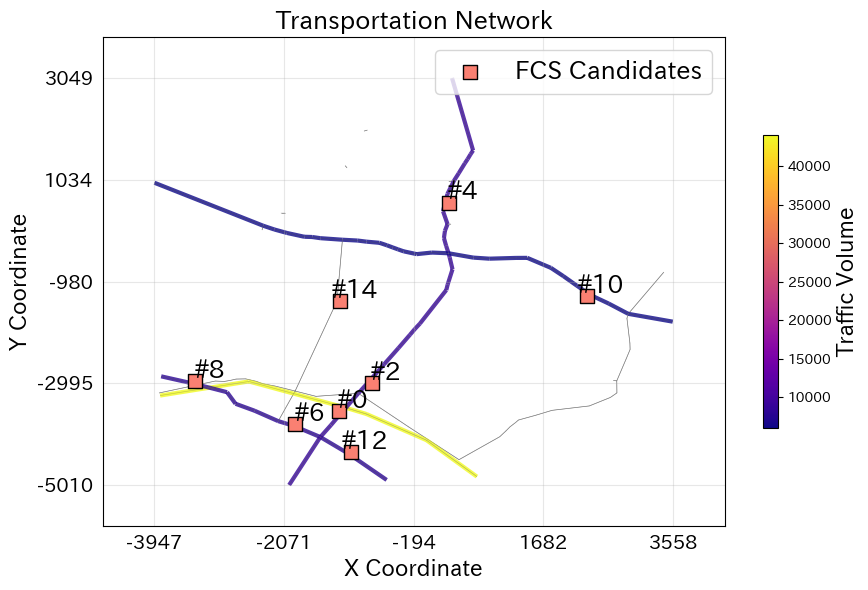

In [36]:
map_path = r'\\wsl.localhost\Ubuntu-22.04\home\tsato-cnlab\Emates\eMATES_2308\network\simple_shikata\mapPosition.txt'
map_df = pd.read_csv(map_path, sep=',', header=None, names=['ID', 'X', 'Y', 'Z'])

network_path = r'\\wsl.localhost\Ubuntu-22.04\home\tsato-cnlab\Emates\eMATES_2308\network\simple_shikata\network.txt'
network_df = pd.read_csv(network_path, sep=',', header=None, names=['from', 'link', 'to_1', 'to_2', 'to_3', 'to_4'])

cslist_path = r'\\wsl.localhost\Ubuntu-22.04\home\tsato-cnlab\Emates\eMATES_2308\network\simple_shikata\csList.txt'
cslist_df = pd.read_csv(cslist_path, sep=',', header=None, names=['ID', 'port', 'kw'])

traffic_path = r'\\wsl.localhost\Ubuntu-22.04\home\tsato-cnlab\Emates\eMATES_2308\network\simple_shikata\generateTable.txt'
traffic_df = pd.read_csv(traffic_path, sep=',', header=None, names=['startTime', 'endTime', 'from', 'to', 'volume', 'type', 'any'],
                         comment='#', skip_blank_lines=True)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
def calculate_distance(x1, y1, x2, y2):
    """2点間のユークリッド距離を計算"""
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

def plot_network_with_traffic_highlights(traffic_df, network_df, map_df):
    """
    道路区分ごとに交通量をハイライトしたネットワーク図を描画
    """
    
    # ネットワークグラフを作成
    G = nx.Graph()
    
    # ノードを追加（座標情報付き）
    node_positions = {}
    for _, row in map_df.iterrows():
        node_id = row['ID']
        G.add_node(node_id, pos=(row['X'], row['Y']))
        node_positions[node_id] = (row['X'], row['Y'])
    
    # エッジを追加（距離を重みとして）
    edge_distances = {}
    for _, row in network_df.iterrows():
        from_node = row['from']
        from_pos = node_positions.get(from_node)
        
        if from_pos is None:
            continue
            
        for to_col in ['to_1', 'to_2', 'to_3', 'to_4']:
            if pd.notna(row[to_col]) and row[to_col] != 0:
                to_node = row[to_col]
                to_pos = node_positions.get(to_node)
                
                if to_pos is not None:
                    # 距離を計算
                    distance = calculate_distance(from_pos[0], from_pos[1], 
                                                to_pos[0], to_pos[1])
                    G.add_edge(from_node, to_node, weight=distance)
                    edge_distances[(from_node, to_node)] = distance
    
    # 道路区分の定義（MATLABコードから）
    road_sections = {
        '2号バイパス': [1437, 169],
        '2号': [4, 1086],
        '高砂北条': [1123, 1031],
        '神戸加古川姫路': [525, 1087]
    }
    
    # 時間帯別交通量を集計
    traffic_summary = traffic_df.groupby(['from', 'to', 'type'])['volume'].sum().reset_index()
    ev_traffic = traffic_summary[traffic_summary['type'] == 81]
    gas_traffic = traffic_summary[traffic_summary['type'] == 21]
    
    # 道路区分ごとの交通量を計算
    road_traffic = {}
    for road_name, nodes in road_sections.items():
        node1, node2 = nodes
        
        # EV交通量
        ev_vol = ev_traffic[
            ((ev_traffic['from'] == node1) & (ev_traffic['to'] == node2)) |
            ((ev_traffic['from'] == node2) & (ev_traffic['to'] == node1))
        ]['volume'].sum()
        
        # ガソリン車交通量
        gas_vol = gas_traffic[
            ((gas_traffic['from'] == node1) & (gas_traffic['to'] == node2)) |
            ((gas_traffic['from'] == node2) & (gas_traffic['to'] == node1))
        ]['volume'].sum()
        
        road_traffic[road_name] = {
            'ev': ev_vol,
            'gas': gas_vol,
            'total': ev_vol + gas_vol,
            'nodes': nodes
        }
    
    # 可視化
    plt.figure(figsize=(9, 6))
    
    # 基本のネットワークを描画（細い灰色の線）
    pos = {node: node_positions[node] for node in G.nodes()}
    
    # すべてのエッジを薄い灰色で描画
    nx.draw_networkx_edges(G, pos, edge_color='black', width=0.5, alpha=0.5)

    # リンクの描画
    for _, row in network_df.iterrows():
        from_node = map_df[map_df['ID'] == row['from']]
        
        for to_col in ['to_1', 'to_2', 'to_3', 'to_4']:
            if pd.notna(row[to_col]) and row[to_col] != 0:
                to_node = map_df[map_df['ID'] == row[to_col]]
                
                if not from_node.empty and not to_node.empty:
                    from_id = row['from']
                    to_id = row[to_col]
                    color = 'gray'
                    linewidth = 0.3
                    alpha = 0.3
                
                plt.plot([from_node['X'].iloc[0], to_node['X'].iloc[0]], 
                        [from_node['Y'].iloc[0], to_node['Y'].iloc[0]], 
                        color=color, alpha=alpha, linewidth=linewidth)
    
    # 交通量の正規化（色の濃さ用）
    max_traffic = max([data['total'] for data in road_traffic.values()]) if road_traffic else 1
    min_traffic = min([data['total'] for data in road_traffic.values() if data['total'] > 0]) if road_traffic else 0
    
    # 道路区分ごとにハイライト
    for i, (road_name, data) in enumerate(road_traffic.items()):
        if data['total'] == 0:
            continue
            
        node1, node2 = data['nodes']
        
        # ノードがグラフに存在するかチェック
        if node1 not in G.nodes() or node2 not in G.nodes():
            print(f"ノード {node1} または {node2} がグラフに存在しません")
            continue
        
        try:
            # 最短経路を計算
            path = nx.shortest_path(G, node1, node2, weight='weight')
            
            # 交通量を正規化（0-1の範囲）
            if max_traffic > min_traffic:
                normalized_traffic = (data['total'] - min_traffic) / (max_traffic - min_traffic)
            else:
                normalized_traffic = 0.5
            
            # 色の設定（寒色→暖色：青→緑→黄→赤）
            color = plt.cm.plasma(normalized_traffic)
            
            # 経路をハイライト
            path_edges = [(path[j], path[j+1]) for j in range(len(path)-1)]
            nx.draw_networkx_edges(G, pos, edgelist=path_edges, 
                                 edge_color=[color], 
                                 width=3, alpha=0.8)
            
            # 道路名と交通量の情報を表示
            print(f"{road_name}: EV={data['ev']}, ガソリン車={data['gas']}, "
                  f"総交通量={data['total']}, 正規化値={normalized_traffic:.2f}")
            
        except nx.NetworkXNoPath:
            print(f"{road_name}: ノード {node1} から {node2} への経路が見つかりません")
        except Exception as e:
            print(f"{road_name}: エラー - {e}")
    
    # 充電ステーション候補地を表示
    csids = cslist_df['ID']
    cs_positions = {cs_id: node_positions[cs_id] for cs_id in csids if cs_id in node_positions}
    if cs_positions:
        cs_x = [pos[0] for pos in cs_positions.values()]
        cs_y = [pos[1] for pos in cs_positions.values()]
        plt.scatter(cs_x, cs_y, c='salmon', s=100, marker='s', 
                   label='FCS Candidates', alpha=1, edgecolors='black', zorder=5)
    
    # 充電ステーション候補地のラベルを表示
    for cs_id, pos_tmp in cs_positions.items():
        cs_id_display = ((int(cs_id) % 900000) // 2) + 1
        cs_id_display = (int(cs_id) % 900000)
        if cs_id_display == 1:
            plt.text(pos_tmp[0], pos_tmp[1] + 400, f"#{cs_id_display}", 
            fontsize=18, ha='center', va='center', zorder=6, fontdict={'weight': 'bold'})
        else:
            plt.text(pos_tmp[0] + 200, pos_tmp[1] + 200, f"#{cs_id_display}", 
                fontsize=18, ha='center', va='center', zorder=6, fontdict={'weight': 'bold'})

    # カラーバーの追加
    sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, 
                              norm=plt.Normalize(vmin=min_traffic, vmax=max_traffic))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.6)
    cbar.set_label('Traffic Volume', fontsize=16, fontweight='bold')

    plt.legend(loc='upper right', fontsize=18)
    plt.title('Transportation Network', fontsize=18, fontweight='bold')
    plt.xlabel('X Coordinate', fontsize=16, fontweight='bold')
    plt.ylabel('Y Coordinate', fontsize=16, fontweight='bold')
    
    # **軸の設定を修正**
    # データの範囲を取得
    x_coords = [pos[0] for pos in node_positions.values()]
    y_coords = [pos[1] for pos in node_positions.values()]
    
    x_min, x_max = min(x_coords), max(x_coords)
    y_min, y_max = min(y_coords), max(y_coords)
    
    # 軸の範囲を設定（マージンを追加）
    x_margin = (x_max - x_min) * 0.1
    y_margin = (y_max - y_min) * 0.1
    
    plt.xlim(x_min - x_margin, x_max + x_margin)
    plt.ylim(y_min - y_margin, y_max + y_margin)
    
    # ティックを明示的に設定
    # 5つの目盛りを等間隔で配置
    x_ticks = np.linspace(x_min, x_max, 5)
    y_ticks = np.linspace(y_min, y_max, 5)
    
    plt.xticks(x_ticks, [f'{x:.0f}' for x in x_ticks], fontsize=14)
    plt.yticks(y_ticks, [f'{y:.0f}' for y in y_ticks], fontsize=14)
    
    # 軸のティックパラメータを強制的に有効化
    plt.tick_params(axis='both', which='major', labelsize=14, 
                    labelbottom=True, labeltop=False, 
                    labelleft=True, labelright=False)
    
    # **plt.axis('equal')をコメントアウト**
    # plt.axis('equal')  # これが軸ラベルを消している可能性があります
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # デバッグ情報を追加
    print(f"X座標範囲: {x_min:.0f} - {x_max:.0f}")
    print(f"Y座標範囲: {y_min:.0f} - {y_max:.0f}")
    print(f"X目盛り: {[f'{x:.0f}' for x in x_ticks]}")
    print(f"Y目盛り: {[f'{y:.0f}' for y in y_ticks]}")
    
    plt.show()

# 実行
plot_network_with_traffic_highlights(traffic_df, network_df, map_df)

##### 2.

46512台のICE車両が移動
19940台のEV車両が移動
30.01%%がEV車両です


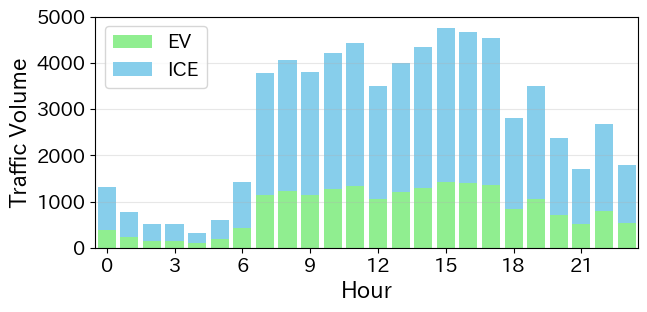

交通量範囲: 2974 - 22046 台/日


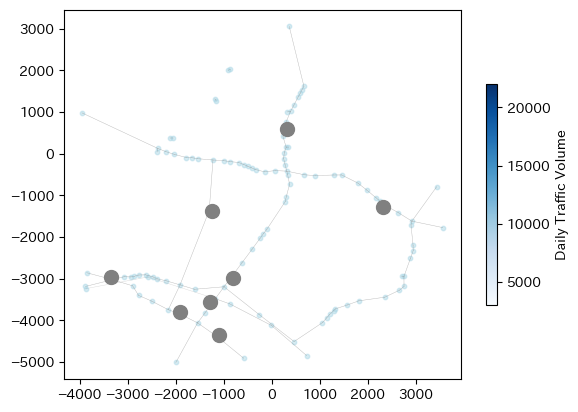

In [ ]:
traffic_path = r'\\wsl.localhost\Ubuntu-22.04\home\tsato-cnlab\Emates\eMATES_2308\network\simple_shikata\generateTable.txt'
traffic_df = pd.read_csv(traffic_path, sep=',', header=None, names=['startTime', 'endTime', 'from', 'to', 'volume', 'type', 'any'],
                         comment='#', skip_blank_lines=True)
# 時間帯を抽出（0-23時間）
traffic_df['time_hour'] = traffic_df['startTime'] // (3600*1000)
# 24時以降のデータは除外
traffic_df = traffic_df[traffic_df['time_hour'] < 24]
# ODペアを統一（小さい値-大きい値の形式）
traffic_df['od_pair'] = traffic_df.apply(
    lambda row: f"{min(row['from'], row['to'])}-{max(row['from'], row['to'])}", 
    axis=1
)

# 時間帯別・OD別で集計
summary = traffic_df.groupby(['time_hour', 'od_pair', 'type']).agg({
    'volume': 'sum'
}).reset_index()
summary_gas = summary[summary['type'] == 21]
summary_ev = summary[summary['type'] == 81]
# 時間帯別総交通量
hourly_total_gas = summary_gas.groupby('time_hour')['volume'].sum()
hourly_total_ev = summary_ev.groupby('time_hour')['volume'].sum()
print(f'{hourly_total_gas.sum()}台のICE車両が移動')
print(f'{hourly_total_ev.sum()}台のEV車両が移動')
print(f'{hourly_total_ev.sum()/(hourly_total_gas.sum() + hourly_total_ev.sum()):.2%}%がEV車両です')
# OD別総交通量（上位10ペア）
od_total = summary.groupby('od_pair')['volume'].sum().nlargest(10)


# 可視化
# ...existing code...

# 可視化
import matplotlib.pyplot as plt

# 1. 時間帯別総交通量（積み上げ棒グラフに修正）
plt.figure(figsize=(7, 3))
plt.bar(hourly_total_ev.index, hourly_total_ev.values, 
        color='lightgreen', label='EV')  # bottomパラメータで積み上げ
plt.bar(hourly_total_gas.index, hourly_total_gas.values, 
        bottom=hourly_total_ev.values, color='skyblue', label='ICE')

plt.xlabel('Hour', fontsize=16)
plt.ylabel('Traffic Volume', fontsize=16)
plt.xticks(range(0, 24, 3), fontsize=14)
plt.xlim(-0.5, 23.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.show()

plot_network_structure(result_path=None, title="Transportation Network", 
                       show_traffic_highlight=True, traffic_df=traffic_df)

##### 3.初期SOC分布

=== 初期SOC分布の可視化 ===
確率の合計: 1.000

=== 初期SOC分布の詳細 ===
SOC 20%: 0.006 (0.6%)
SOC 50%: 0.003 (0.3%)
SOC 55%: 0.020 (2.0%)
SOC 60%: 0.007 (0.7%)
SOC 65%: 0.044 (4.4%)
SOC 70%: 0.049 (4.9%)
SOC 75%: 0.402 (40.2%)
SOC 80%: 0.469 (46.9%)

充電が必要な車両割合（SOC < 80%）: 53.1%
急速充電が必要な車両割合（SOC < 50%）: 0.6%


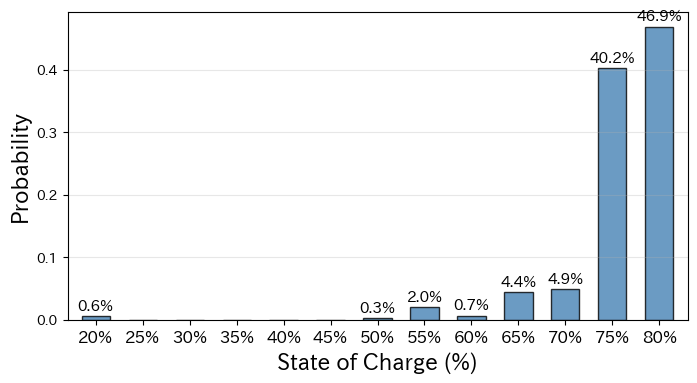

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def create_initial_soc_distribution():
    """
    コードから読み取った初期SOC分布を可視化（％表記、固定間隔、統一色）
    """
    
    # コードから確率を分析
    # rnd >= 0.531 → SOC = 0.8    確率: 1 - 0.531 = 0.469 (46.9%)
    # 0.129 <= rnd < 0.531 → SOC = 0.75  確率: 0.531 - 0.129 = 0.402 (40.2%)
    # 0.08 <= rnd < 0.129 → SOC = 0.7   確率: 0.129 - 0.08 = 0.049 (4.9%)
    # 0.036 <= rnd < 0.08 → SOC = 0.65  確率: 0.08 - 0.036 = 0.044 (4.4%)
    # 0.029 <= rnd < 0.036 → SOC = 0.6  確率: 0.036 - 0.029 = 0.007 (0.7%)
    # 0.009 <= rnd < 0.029 → SOC = 0.55 確率: 0.029 - 0.009 = 0.02 (2.0%)
    # 0.006 <= rnd < 0.009 → SOC = 0.5  確率: 0.009 - 0.006 = 0.003 (0.3%)
    # rnd < 0.006 → SOC = 0.2          確率: 0.006 (0.6%)
    
    # SOC値を％に変換（昇順でソート）
    soc_values_percent = [20, 50, 55, 60, 65, 70, 75, 80]
    probabilities = [0.006, 0.003, 0.02, 0.007, 0.044, 0.049, 0.402, 0.469]
    
    # 確率の合計が1になることを確認
    total_prob = sum(probabilities)
    print(f"確率の合計: {total_prob:.3f}")
    
    # 固定間隔のx軸を作成（10%刻み）
    x_ticks = np.arange(20, 85, 5)  # 20%から80%まで5%刻み
    
    # 各x_tickに対応する確率を設定（該当しない場合は0）
    y_values = []
    for x in x_ticks:
        if x in soc_values_percent:
            idx = soc_values_percent.index(x)
            y_values.append(probabilities[idx])
        else:
            y_values.append(0)
    
    # 棒グラフの作成
    fig, ax1 = plt.subplots(figsize=(8, 4))
    
    # 統一色で棒グラフを作成
    bars1 = ax1.bar(x_ticks, y_values, width=3, color='steelblue', alpha=0.8, edgecolor='black')
    
    # ax1.set_title('Initial SOC Distribution (Probability)', fontsize=16, fontweight='bold')
    ax1.set_xlabel('State of Charge (%)', fontsize=16)
    ax1.set_ylabel('Probability', fontsize=16)
    
    # X軸を固定間隔に設定
    ax1.set_xticks(x_ticks)
    ax1.set_xticklabels([f'{x}%' for x in x_ticks], fontsize=12)
    ax1.set_xlim(17, 83)
    
    ax1.grid(axis='y', alpha=0.3)
    
    # 確率値をバーの上に表示（0でない場合のみ）
    for x, y in zip(x_ticks, y_values):
        if y > 0:
            ax1.text(x, y + 0.005, f'{y:.1%}', ha='center', va='bottom', 
                    fontsize=11, fontweight='bold')
    
    # 統計情報を表示
    print("\n=== 初期SOC分布の詳細 ===")
    for soc_pct, prob in zip(soc_values_percent, probabilities):
        print(f"SOC {soc_pct}%: {prob:.3f} ({prob*100:.1f}%)")
    
    # 充電が必要な車両の割合を計算（SOC < 80%）
    charging_needed = sum(prob for soc, prob in zip(soc_values_percent, probabilities) if soc < 80)
    print(f"\n充電が必要な車両割合（SOC < 80%）: {charging_needed:.1%}")
    
    # 急速充電が必要な車両の割合（SOC < 50%）
    urgent_charging = sum(prob for soc, prob in zip(soc_values_percent, probabilities) if soc < 50)
    print(f"急速充電が必要な車両割合（SOC < 50%）: {urgent_charging:.1%}")
    
    return soc_values_percent, probabilities

# 実行
print("=== 初期SOC分布の可視化 ===")
soc_vals, probs = create_initial_soc_distribution()

In [ ]:
# CS設定とvehicle_tripのCSID情報を結合して容量データを取得
def get_cs_capacity_info(result_files, case_names):
    """
    各ケースでCS設定の容量情報とvehicle_tripのCSIDを結合
    """
    
    all_cs_capacity_data = {}
    
    for result_file, case_name in zip(result_files, case_names):
        with open(result_file, 'rb') as f:
            data = pickle.load(f)
            cs_config = data['cs_config']
            vehicle_trip = data['vehicle_trip']
        
        # CS設定をDataFrameに変換
        cs_df = pd.DataFrame({
            'csids': cs_config['csids'],
            'ports': cs_config['ports'],
            'cap_kw': cs_config['cap_kw']
        })
        
        # 設置されたCSのみ（ports > 0）を抽出
        installed_cs = cs_df[cs_df['ports'] > 0].copy()
        
        print(f"\n=== {case_name} CS設定情報 ===")
        print(f"設置CS数: {len(installed_cs)}")
        print(f"設置CS詳細:")
        for _, cs in installed_cs.iterrows():
            print(f"  CSID {cs['csids']}: {cs['ports']}ポート, {cs['cap_kw']}kW")
        
        # 充電車両のトリップにCS容量情報を追加
        charging_trips = vehicle_trip[
            (vehicle_trip['startChargingTime'] > 0) &
            (vehicle_trip['CSID'] > 0) &
            (vehicle_trip['CSID'].notna())
        ].copy()
        
        # CSIDとcs_configのcsidsを結合してcap_kwを取得
        charging_trips_with_capacity = pd.merge(
            charging_trips, 
            installed_cs[['csids', 'cap_kw', 'ports']], 
            left_on='CSID', 
            right_on='csids', 
            how='left'
        )
        
        # 結合結果の確認
        print(f"\n充電トリップ数: {len(charging_trips)}")
        print(f"容量情報付きトリップ数: {len(charging_trips_with_capacity.dropna(subset=['cap_kw']))}")
        
        # CS利用統計
        cs_usage_stats = charging_trips_with_capacity.groupby(['CSID', 'cap_kw']).agg({
            'EVID': 'count',
            'startChargingTime': lambda x: len(x.unique())
        }).rename(columns={'EVID': 'trip_count', 'startChargingTime': 'unique_vehicles'})
        
        print(f"\nCS別利用統計:")
        for (csid, cap_kw), stats in cs_usage_stats.iterrows():
            print(f"  CSID {csid} ({cap_kw}kW): {stats['trip_count']}トリップ, {stats['unique_vehicles']}台")
        
        all_cs_capacity_data[case_name] = {
            'cs_config': installed_cs,
            'charging_trips_with_capacity': charging_trips_with_capacity,
            'cs_usage_stats': cs_usage_stats,
            'vehicle_trip': vehicle_trip
        }
    
    return all_cs_capacity_data

# 関数実行
result_files = [result_file_normal, result_file_normal_failure, 
                result_file_robust, result_file_robust_failure, result_file_5loc]
case_names = ['Normal', 'Normal_Failure', 'Robust_Health', 'Robust_Failure', '5LOC']

cs_capacity_data = get_cs_capacity_info(result_files, case_names)

#### 充電器故障を何台同時まで考えるのかを検証する。仮定では2台同時故障する

Number of chargers: 2
Charger failure rate: 0.05
Number of CS: 2
CS Configurations:
   CSID num_chargers
1   2.0            2
2   NaN            1


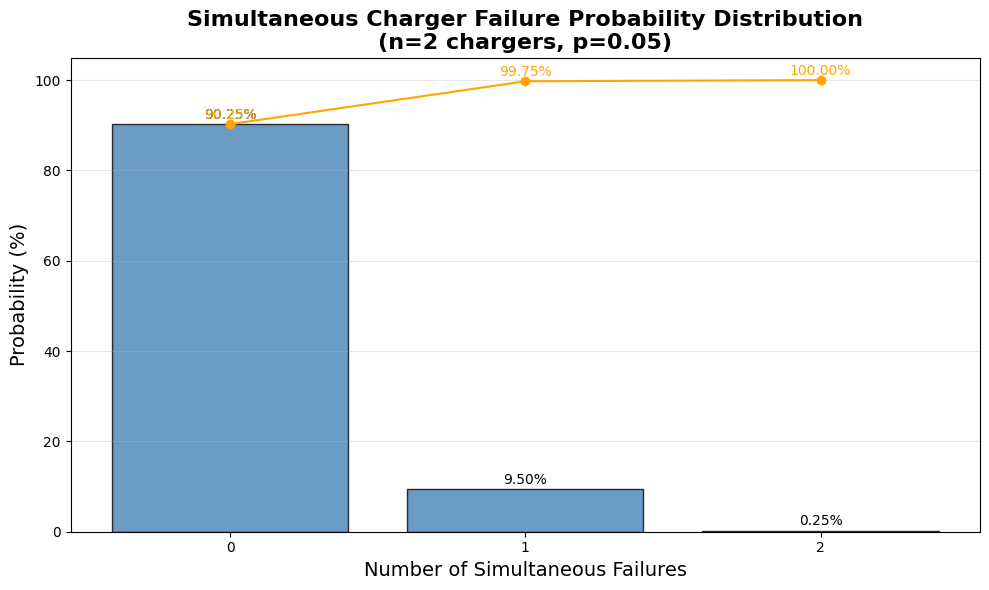

In [ ]:
import pandas as pd
import random
import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt

class CHARGER():
    num_charger = random.randint(2, 8)
    CHARGER_FAILURE_RATE = 0.05
    num_cs = random.randint(2, num_charger)
    configurations = []
    # ランダムに充電ステーションごとの充電器台数を設定
    cs_config = pd.DataFrame(columns=['CSID', 'num_chargers'])
    for i in range(1, num_cs):
        cs_config['CSID'] = i
        if i == num_cs - 1:
            cs_config.at[i, 'num_chargers'] = num_charger - cs_config['num_chargers'].sum()
        else:
            cs_config.at[i, 'num_chargers'] = random.randint(1, min(num_charger - cs_config['num_chargers'].sum() - (num_cs - i - 1), 4))
    
    def __init__(self):
        print(f"Number of chargers: {self.num_charger}")
        print(f"Charger failure rate: {self.CHARGER_FAILURE_RATE}")
        print(f"Number of CS: {self.num_cs}")
        print("CS Configurations:")
        print(self.cs_config)
        
    def calculate_simultaneous_failure_probability(self):
        """
        二項分布を用いて0台、1台、2台...同時故障する確率を計算
        """
        n = self.num_charger  # 充電器の総数
        p = self.CHARGER_FAILURE_RATE  # 1台あたりの故障率
        
        # 各故障台数の確率を計算
        failure_probs = []
        for k in range(n + 1):
            prob = binom.pmf(k, n, p)
            failure_probs.append({
                'failure_count': k,
                'probability': prob,
                'probability_percent': prob * 100
            })
        
        return pd.DataFrame(failure_probs)
    
    def plot_failure_distribution(self, df):
        """
        故障確率分布を可視化
        """
        accumulated_prob = df['probability'].cumsum().iloc[-1]
        plt.figure(figsize=(10, 6))
        
        bars = plt.bar(df['failure_count'], df['probability_percent'], 
                      color='steelblue', alpha=0.8, edgecolor='black')
        lines = plt.plot(df['failure_count'], df['probability'].cumsum() * 100, color='orange', marker='o')
        plt.xlabel('Number of Simultaneous Failures', fontsize=14)
        plt.ylabel('Probability (%)', fontsize=14)
        plt.title(f'Simultaneous Charger Failure Probability Distribution\n'
                 f'(n={self.num_charger} chargers, p={self.CHARGER_FAILURE_RATE})', 
                 fontsize=16, fontweight='bold')
        plt.xticks(df['failure_count'])
        plt.grid(axis='y', alpha=0.3)
        
        # 確率値をバーの上に表示
        for bar, prob in zip(bars, df['probability_percent']):
            if prob >= 0.01:  # 0.01%以上の場合のみ表示
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f'{prob:.2f}%', ha='center', va='bottom', fontsize=10)
        for x, cum_prob in zip(df['failure_count'], df['probability'].cumsum() * 100):
            plt.text(x, cum_prob + 0.5, f'{cum_prob:.2f}%', 
                     ha='center', va='bottom', fontsize=10, color='orange')
        plt.tight_layout()
        plt.show()

# インスタンス化と分析実行
charger = CHARGER()
failure_prob_df = charger.calculate_simultaneous_failure_probability()
charger.plot_failure_distribution(failure_prob_df)


=== 充電器のCS別割り当てと故障確率分析 ===


CS別充電器台数:
  CSID num_chargers
0    1            3
1    2            2

故障確率分析結果

【CS別故障確率】

CS 1 (充電器3台):
  少なくとも1台故障する確率: 14.2625%
  故障台数別確率:
    0台: 85.7375%
    1台: 13.5375%
    2台: 0.7125%
    3台: 0.0125%

CS 2 (充電器2台):
  少なくとも1台故障する確率: 9.7500%
  故障台数別確率:
    0台: 90.2500%
    1台: 9.5000%
    2台: 0.2500%

CS 3 (充電器1台):
  少なくとも1台故障する確率: 5.0000%
  故障台数別確率:
    0台: 95.0000%
    1台: 5.0000%

CS 4 (充電器2台):
  少なくとも1台故障する確率: 9.7500%
  故障台数別確率:
    0台: 90.2500%
    1台: 9.5000%
    2台: 0.2500%

【システム全体の故障シナリオ】
0箇所のCSで故障: 66.5168%
1箇所のCSで故障: 28.5503%
2箇所のCSで故障: 4.5954%
3箇所のCSで故障: 0.3287%
4箇所のCSで故障: 0.0088%

【主要な確率】
全CS正常: 66.5168%
少なくとも1箇所故障: 33.4832%
2箇所以上故障: 4.9329%


C:\Users\echiz\AppData\Local\Temp\ipykernel_1372\284281660.py:156: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) IPAexGothic.
  plt.tight_layout()
c:\Users\echiz\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


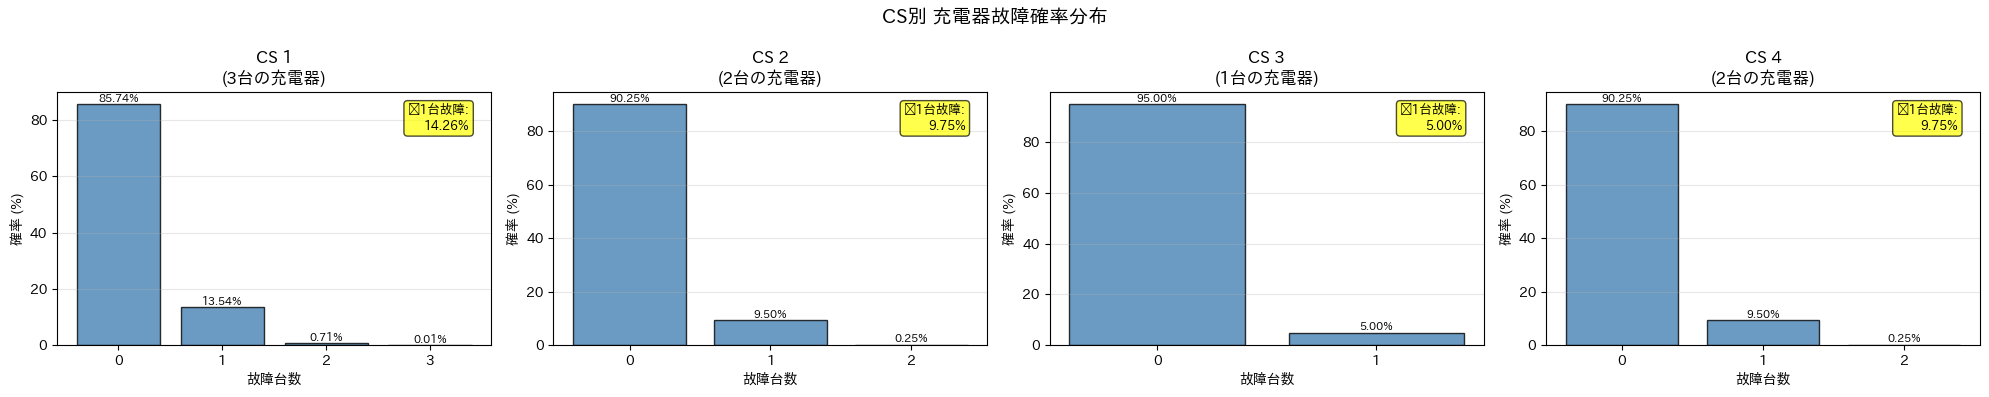

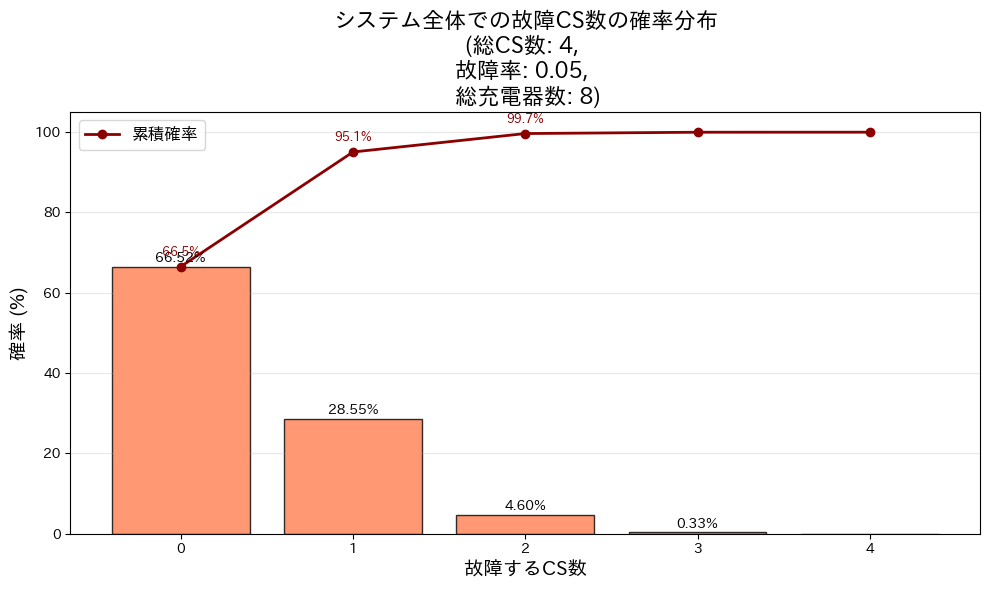



=== 異なる設定での比較 ===

--- 総充電器数: 4, CS数: 2 ---

CS別充電器台数:
  CSID num_chargers
0    1            2
1    2            2


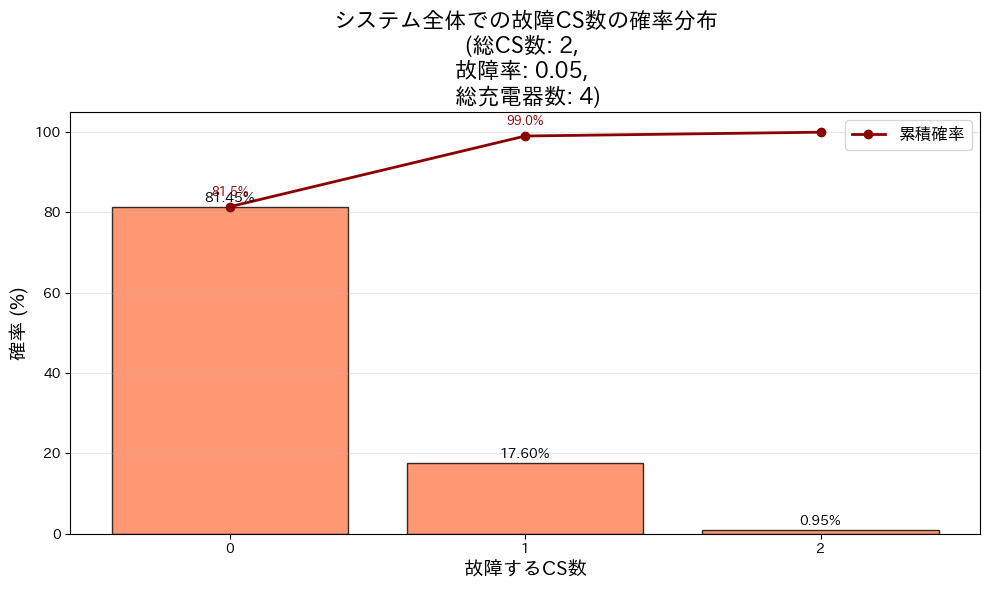

2箇所以上のCSで故障: 0.9506%

--- 総充電器数: 4, CS数: 4 ---

CS別充電器台数:
  CSID num_chargers
0    1            1
1    2            1


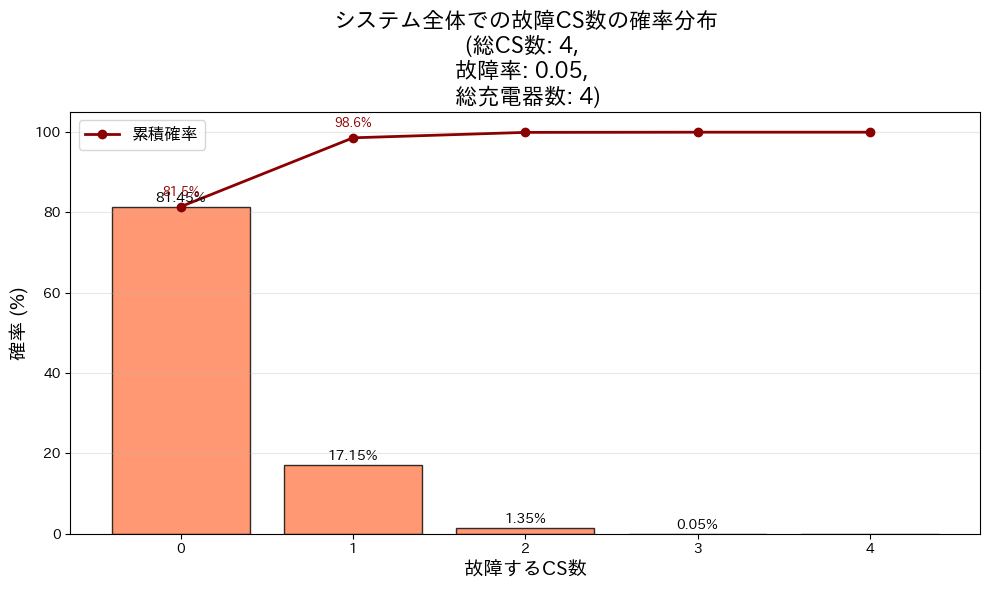

2箇所以上のCSで故障: 1.4019%

--- 総充電器数: 4, CS数: 6 ---
CS数が総充電器数を超えています。スキップします。

--- 総充電器数: 8, CS数: 2 ---

CS別充電器台数:
  CSID num_chargers
0    1            3
1    2            5


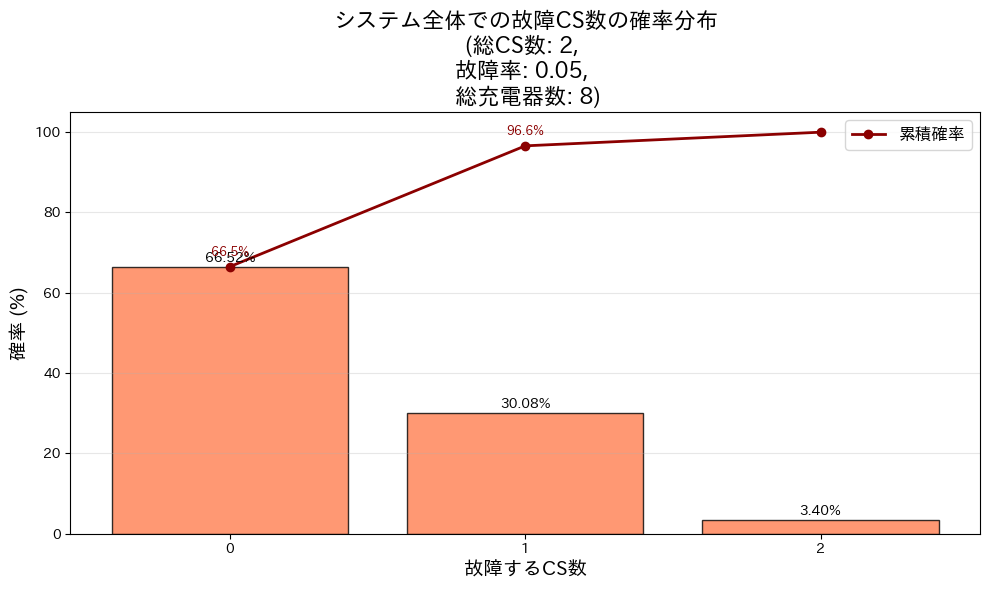

2箇所以上のCSで故障: 3.4011%

--- 総充電器数: 8, CS数: 4 ---

CS別充電器台数:
  CSID num_chargers
0    1            3
1    2            1


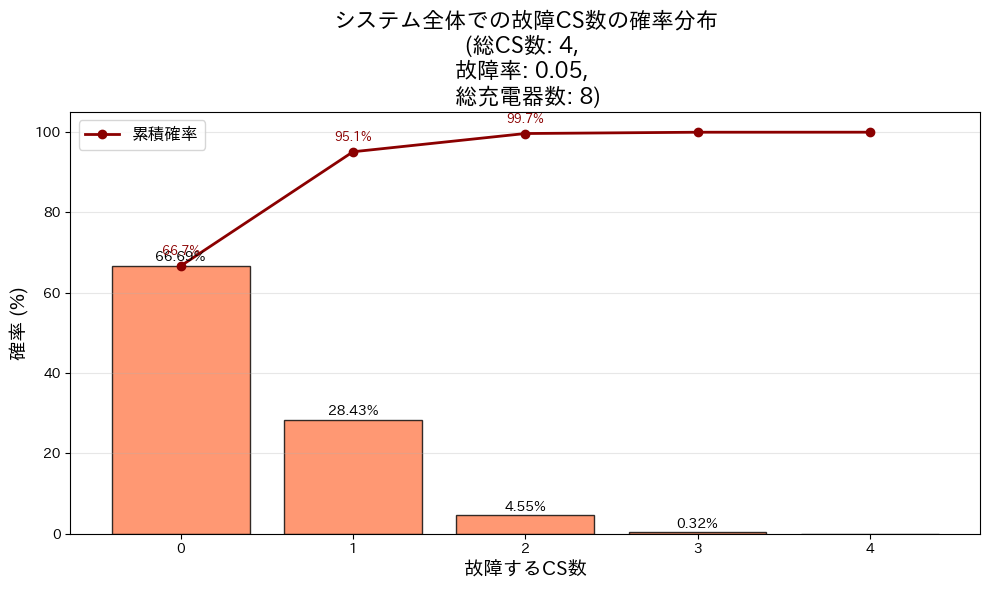

2箇所以上のCSで故障: 4.8767%

--- 総充電器数: 8, CS数: 6 ---

CS別充電器台数:
  CSID num_chargers
0    1            1
1    2            2


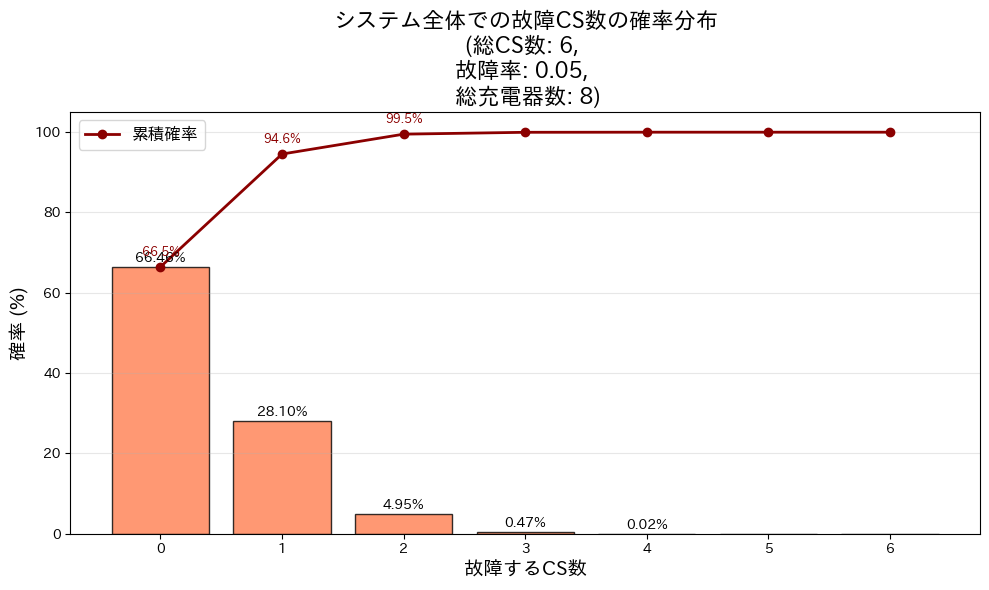

2箇所以上のCSで故障: 5.4413%

--- 総充電器数: 12, CS数: 2 ---

CS別充電器台数:
  CSID num_chargers
0    1            1
1    2           11


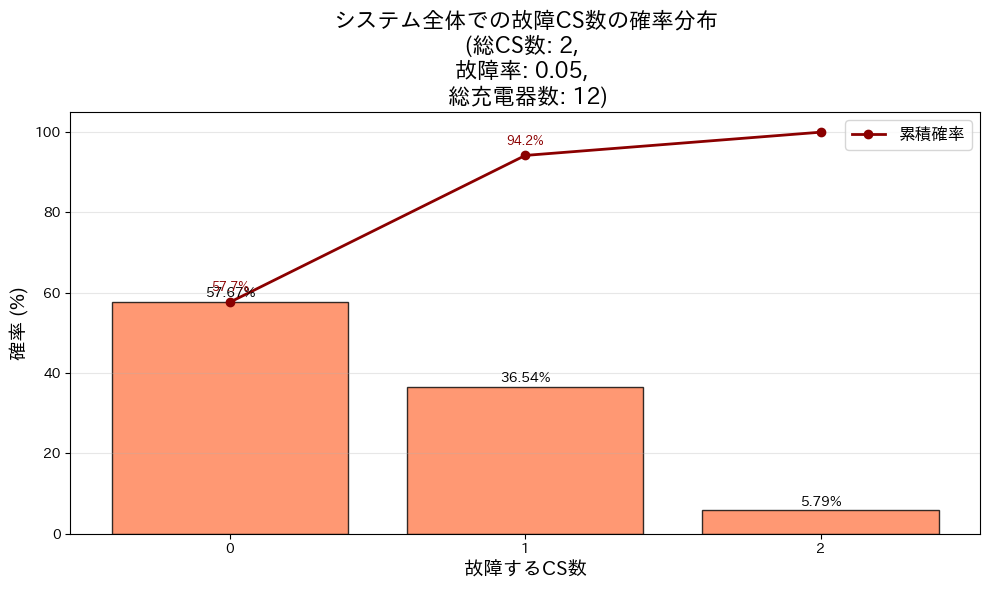

2箇所以上のCSで故障: 5.7888%

--- 総充電器数: 12, CS数: 4 ---

CS別充電器台数:
  CSID num_chargers
0    1            4
1    2            3


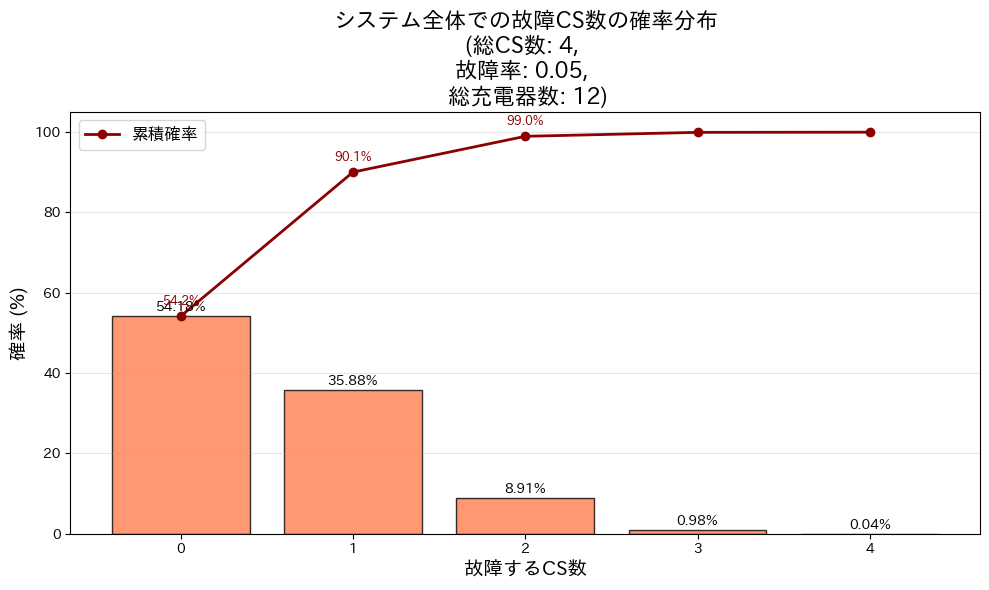

2箇所以上のCSで故障: 9.9374%

--- 総充電器数: 12, CS数: 6 ---

CS別充電器台数:
  CSID num_chargers
0    1            4
1    2            3


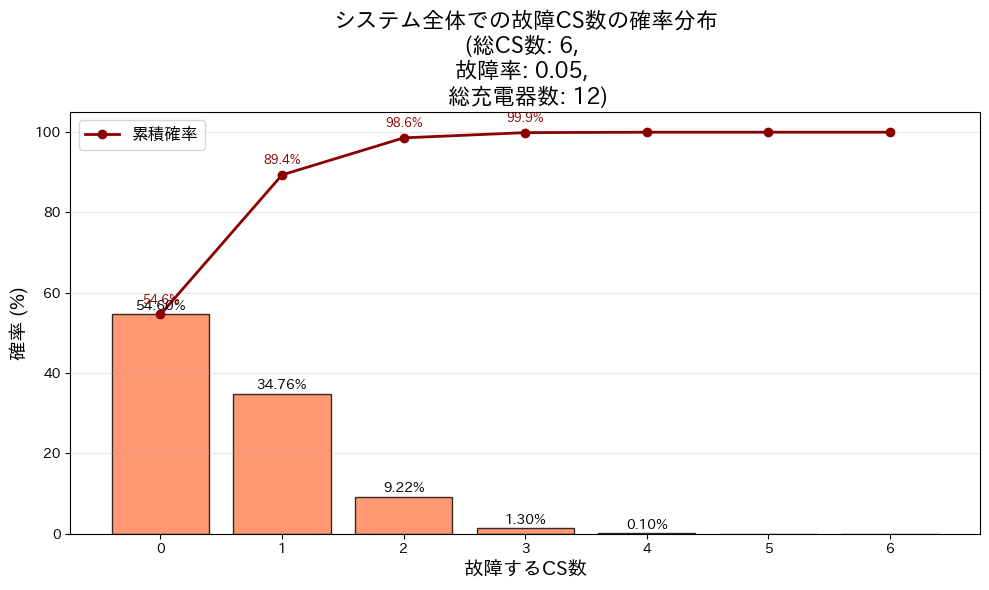

2箇所以上のCSで故障: 10.6359%


In [12]:
import pandas as pd
import random
import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt
import japanize_matplotlib

class CHARGER():
    def __init__(self, num_charger=None, num_cs=None, failure_rate=0.05):
        """
        充電器をCSごとにランダムに割り当てて故障確率を計算
        
        Parameters:
        - num_charger: 総充電器台数（Noneの場合はランダム）
        - num_cs: CS数（Noneの場合はランダム）
        - failure_rate: 故障率
        """
        self.num_charger = num_charger
        self.CHARGER_FAILURE_RATE = failure_rate
        self.num_cs = num_cs if num_cs else random.randint(2, self.num_charger)
        
        # 充電器をCSにランダム割り当て
        self.cs_config = self._allocate_chargers_to_cs()
        print("\nCS別充電器台数:")
        print(self.cs_config.head(2))
        
    def _allocate_chargers_to_cs(self):
        """
        充電器をCSにランダムに割り当て
        """
        cs_config = pd.DataFrame(columns=['CSID', 'num_chargers'])
        
        remaining_chargers = self.num_charger
        
        for i in range(self.num_cs):
            csid = i + 1
            
            if i == self.num_cs - 1:
                # 最後のCSには残り全て割り当て
                num_chargers = remaining_chargers
            else:
                # 残りCS数を考慮して最小1台は確保
                remaining_cs = self.num_cs - i - 1
                max_allocation = min(remaining_chargers - remaining_cs, 4)  # 最大4台まで
                num_chargers = random.randint(1, max(1, max_allocation))
                remaining_chargers -= num_chargers
            
            cs_config = pd.concat([cs_config, pd.DataFrame({
                'CSID': [csid],
                'num_chargers': [num_chargers]
            })], ignore_index=True)
        
        return cs_config
    
    def calculate_cs_failure_probability(self):
        """
        CS単位での故障確率を計算
        各CSで少なくとも1台故障する確率
        """
        cs_failure_probs = []
        
        for _, row in self.cs_config.iterrows():
            csid = row['CSID']
            n = row['num_chargers']
            p = self.CHARGER_FAILURE_RATE
            
            # 少なくとも1台故障する確率 = 1 - 全台正常の確率
            prob_at_least_one_failure = 1 - binom.pmf(0, n, p)
            
            # 各故障台数の確率分布
            failure_dist = []
            for k in range(int(n) + 1):
                prob_k = binom.pmf(k, n, p)
                failure_dist.append({
                    'failure_count': k,
                    'probability': prob_k
                })
            
            cs_failure_probs.append({
                'CSID': csid,
                'num_chargers': n,
                'prob_at_least_one_failure': prob_at_least_one_failure,
                'prob_at_least_one_failure_percent': prob_at_least_one_failure * 100,
                'failure_distribution': pd.DataFrame(failure_dist)
            })
        
        return cs_failure_probs
    
    def calculate_system_wide_failure_scenarios(self):
        """
        システム全体での故障シナリオ確率を計算
        どのCSが故障するかのパターン
        """
        cs_failure_probs = self.calculate_cs_failure_probability()
        
        # 各CSが故障する確率
        cs_failure_rates = [(cs['CSID'], cs['prob_at_least_one_failure']) 
                           for cs in cs_failure_probs]
        
        # システム全体での故障CS数の確率分布
        system_scenarios = []
        
        # 0台故障から全台故障までの各ケース
        for num_failed_cs in range(self.num_cs + 1):
            # 二項分布で近似（各CSが独立に故障すると仮定）
            avg_cs_failure_rate = np.mean([rate for _, rate in cs_failure_rates])
            prob = binom.pmf(num_failed_cs, self.num_cs, avg_cs_failure_rate)
            
            system_scenarios.append({
                'num_failed_cs': num_failed_cs,
                'probability': prob,
                'probability_percent': prob * 100
            })
        
        return pd.DataFrame(system_scenarios)
    
    def plot_cs_failure_distributions(self, cs_failure_probs):
        """
        CS別の故障確率分布を可視化
        """
        num_cs = len(cs_failure_probs)
        
        fig, axes = plt.subplots(1, num_cs, figsize=(5 * num_cs, 4))
        
        if num_cs == 1:
            axes = [axes]
        
        for i, cs_data in enumerate(cs_failure_probs):
            ax = axes[i]
            df = cs_data['failure_distribution']
            
            bars = ax.bar(df['failure_count'], df['probability'] * 100,
                         color='steelblue', alpha=0.8, edgecolor='black')
            
            ax.set_title(f"CS {cs_data['CSID']}\n({int(cs_data['num_chargers'])}台の充電器)",
                        fontsize=12, fontweight='bold')
            ax.set_xlabel('故障台数', fontsize=10)
            ax.set_ylabel('確率 (%)', fontsize=10)
            ax.set_xticks(df['failure_count'])
            ax.grid(axis='y', alpha=0.3)
            
            # 確率値を表示
            for bar, prob in zip(bars, df['probability'] * 100):
                if prob >= 0.01:
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                           f'{prob:.2f}%', ha='center', va='bottom', fontsize=8)
            
            # 少なくとも1台故障する確率を表示
            ax.text(0.95, 0.95, 
                   f"≥1台故障:\n{cs_data['prob_at_least_one_failure_percent']:.2f}%",
                   transform=ax.transAxes, ha='right', va='top',
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
                   fontsize=9, fontweight='bold')
        
        plt.suptitle('CS別 充電器故障確率分布', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    def plot_system_failure_scenarios(self, system_scenarios_df):
        """
        システム全体の故障CS数の確率分布を可視化
        """
        plt.figure(figsize=(10, 6))
        bars = plt.bar(system_scenarios_df['num_failed_cs'], 
                      system_scenarios_df['probability_percent'],
                      color='coral', alpha=0.8, edgecolor='black')
        
        # 累積確率線を追加
        cumulative = system_scenarios_df['probability'].cumsum() * 100
        plt.plot(system_scenarios_df['num_failed_cs'], cumulative,
                color='darkred', marker='o', linewidth=2, label='累積確率')
        
        plt.xlabel('故障するCS数', fontsize=14)
        plt.ylabel('確率 (%)', fontsize=14)
        plt.title(f'システム全体での故障CS数の確率分布\n(総CS数: {self.num_cs}, \n故障率: {self.CHARGER_FAILURE_RATE}, \n 総充電器数: {self.num_charger})', 
                 fontsize=16, fontweight='bold')
        plt.xticks(system_scenarios_df['num_failed_cs'])
        plt.grid(axis='y', alpha=0.3)
        plt.legend(fontsize=12)
        
        # 確率値を表示
        for bar, prob in zip(bars, system_scenarios_df['probability_percent']):
            if prob >= 0.01:
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f'{prob:.2f}%', ha='center', va='bottom', fontsize=10)
        
        # 累積確率値を表示
        for x, cum_prob in zip(system_scenarios_df['num_failed_cs'], cumulative):
            if cum_prob < 99.9:  # 100%に近い場合は省略
                plt.text(x, cum_prob + 2, f'{cum_prob:.1f}%',
                        ha='center', va='bottom', fontsize=9, color='darkred')
        
        plt.tight_layout()
        plt.show()
    
    def print_failure_analysis(self):
        """
        故障分析結果を詳細に表示
        """
        print("\n" + "="*60)
        print("故障確率分析結果")
        print("="*60)
        
        cs_failure_probs = self.calculate_cs_failure_probability()
        
        print("\n【CS別故障確率】")
        for cs_data in cs_failure_probs:
            print(f"\nCS {cs_data['CSID']} (充電器{int(cs_data['num_chargers'])}台):")
            print(f"  少なくとも1台故障する確率: {cs_data['prob_at_least_one_failure_percent']:.4f}%")
            
            df = cs_data['failure_distribution']
            print(f"  故障台数別確率:")
            for _, row in df.iterrows():
                if row['probability'] >= 0.0001:  # 0.01%以上のみ表示
                    print(f"    {int(row['failure_count'])}台: {row['probability']*100:.4f}%")
        
        system_scenarios = self.calculate_system_wide_failure_scenarios()
        
        print("\n【システム全体の故障シナリオ】")
        for _, row in system_scenarios.iterrows():
            print(f"{int(row['num_failed_cs'])}箇所のCSで故障: {row['probability_percent']:.4f}%")
        
        # 重要な閾値の計算
        prob_no_failure = system_scenarios[system_scenarios['num_failed_cs'] == 0]['probability'].iloc[0]
        prob_at_least_one = 1 - prob_no_failure
        prob_two_or_more = system_scenarios[system_scenarios['num_failed_cs'] >= 2]['probability'].sum()
        
        print(f"\n【主要な確率】")
        print(f"全CS正常: {prob_no_failure*100:.4f}%")
        print(f"少なくとも1箇所故障: {prob_at_least_one*100:.4f}%")
        print(f"2箇所以上故障: {prob_two_or_more*100:.4f}%")
        
        print("="*60)


# 使用例
print("=== 充電器のCS別割り当てと故障確率分析 ===\n")

# インスタンス化
charger = CHARGER(num_charger=8, num_cs=4, failure_rate=0.05)

# CS別故障確率を計算
cs_failure_probs = charger.calculate_cs_failure_probability()

# システム全体の故障シナリオを計算
system_scenarios = charger.calculate_system_wide_failure_scenarios()

# 詳細結果の表示
charger.print_failure_analysis()

# 可視化
charger.plot_cs_failure_distributions(cs_failure_probs)
charger.plot_system_failure_scenarios(system_scenarios)

# 複数パターンでのシミュレーション
print("\n\n=== 異なる設定での比較 ===")
chr_pattern = [4, 8, 12]; num_cs_pattern = [2, 4, 6]
for i, total_chargers in enumerate(chr_pattern):
    for j, num_cs in enumerate(num_cs_pattern):
        print(f"\n--- 総充電器数: {total_chargers}, CS数: {num_cs} ---")
        if num_cs > total_chargers:
            print("CS数が総充電器数を超えています。スキップします。")
            continue
        else:
            charger_sim = CHARGER(num_charger=total_chargers, num_cs=num_cs, failure_rate=0.05)
            system_scenarios_sim = charger_sim.calculate_system_wide_failure_scenarios()
            prob_two_or_more = system_scenarios_sim[system_scenarios_sim['num_failed_cs'] >= 2]['probability'].sum()
            charger_sim.plot_system_failure_scenarios(system_scenarios_sim)
            print(f"2箇所以上のCSで故障: {prob_two_or_more*100:.4f}%")